# Customer churn

In [17]:
import os 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import pickle
from pickle import dump
import json 

from sklearn.metrics import f1_score

from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.preprocessing import LabelEncoder 

from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from xgboost import XGBClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.cluster import KMeans 

from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

Data

In [18]:
# ruta=os.getcwd()
# df=pd.read_csv(ruta +'\\..\\data\\precio_vivienda.csv', index_col=0)
# df.reset_index(inplace=True)
# df

In [19]:
ruta=os.getcwd()

In [20]:
df_train=pd.read_csv(ruta + '\\abandono_train.csv', index_col=0)
df_train.reset_index(inplace=True)
df_train

,train_idx,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,0,713071383,54,F,1,Unknown,Single,Unknown,Blue,36,...,3,3723.0,1728,1995.0,0.595,8554,99,0.678,0.464,1
1,1,714246333,58,F,4,High School,Married,Unknown,Blue,48,...,3,5396.0,1803,3593.0,0.493,2107,39,0.393,0.334,0
2,2,718206783,45,F,4,Unknown,Single,Less than $40K,Gold,36,...,3,15987.0,1648,14339.0,0.732,1436,36,1.250,0.103,1
3,3,721096983,34,F,2,Graduate,Single,Less than $40K,Blue,36,...,4,3625.0,2517,1108.0,1.158,2616,46,1.300,0.694,1
4,4,720028683,49,F,2,High School,Married,$40K - $60K,Blue,39,...,4,2720.0,1926,794.0,0.602,3806,61,0.794,0.708,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8096,8096,769053033,44,F,1,Graduate,Single,$40K - $60K,Blue,38,...,5,4142.0,2517,1625.0,0.809,2104,44,0.833,0.608,0
8097,8097,714406158,53,F,3,High School,Divorced,Unknown,Blue,36,...,6,7939.0,0,7939.0,0.551,2269,42,0.312,0.000,0
8098,8098,714140133,42,F,4,Graduate,Unknown,Less than $40K,Blue,32,...,2,2314.0,1547,767.0,0.804,4678,74,1.000,0.669,1
8099,8099,720244983,40,M,3,Unknown,Single,$40K - $60K,Blue,28,...,1,3563.0,1707,1856.0,0.506,1482,42,0.312,0.479,1


In [21]:
df_test=pd.read_csv(ruta + '\\abandono_test.csv', index_col=0)
df_test.reset_index(inplace=True)
df_test

,test_idx,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,719455083,48,F,3,Uneducated,Single,Less than $40K,Blue,39,...,3,4,2991.0,1508,1483.0,0.703,3734,64,0.882,0.504
1,1,773503308,59,M,1,Uneducated,Single,Less than $40K,Blue,53,...,5,4,2192.0,1569,623.0,0.706,4010,79,0.717,0.716
2,2,715452408,37,F,2,Graduate,Divorced,Less than $40K,Blue,36,...,3,3,1734.0,987,747.0,0.879,4727,67,0.914,0.569
3,3,711264033,47,M,3,Doctorate,Divorced,$40K - $60K,Blue,36,...,2,3,4786.0,1516,3270.0,0.940,4973,74,0.850,0.317
4,4,718943508,42,M,3,Unknown,Single,$80K - $120K,Blue,33,...,3,2,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,2021,814776033,34,M,2,Graduate,Single,$80K - $120K,Blue,29,...,1,3,13395.0,1678,11717.0,1.006,2650,69,0.865,0.125
2022,2022,720444408,35,F,1,College,Single,Less than $40K,Blue,25,...,2,4,2231.0,1791,440.0,0.820,2576,42,0.750,0.803
2023,2023,720503508,44,F,1,Uneducated,Divorced,Less than $40K,Blue,37,...,2,3,5594.0,1235,4359.0,0.549,5220,75,0.829,0.221
2024,2024,721217283,27,M,0,Graduate,Single,$120K +,Blue,17,...,2,2,8713.0,1354,7359.0,0.558,2094,36,0.333,0.155


test_idx: Unique identifier for each data record.

CLIANTNUM: Unique identifier for each bank customer.

Customer_Age: Customer's age in years.

Gender: Customer's gender.

Dependent_count: Number of dependents of the customer.

Education_Level: Customer's education level.

Marital_Status: Customer's marital status.

Income_Category: Customer's income range.

Card_Category: Customer's credit card type.

Months_on_book: Number of months the customer has been in the bank's customer portfolio.

Months_Inactive_12_mon: Number of months the customer has not made any transactions in the last 12 months.

Contacts_Count_12_mon: Number of times the customer has contacted the bank in the last 12 months.

Credit_Limit: Customer's credit limit.

Total_Revolving_Bal: Total credit balance the customer has on their credit cards.

Avg_Open_To_Buy: Average available credit for the customer.

Total_Amt_Chng_Q4_Q1: Percentage change in the total amount of transactions made by the customer in the last quarter compared to the previous quarter.

Total_Trans_Amt: Total amount of transactions made by the customer.

Total_Trans_Ct: Total number of transactions made by the customer.

Total_Ct_Chng_Q4_Q1: Percentage change in the total number of transactions made by the customer in the last quarter compared to the previous quarter.

Avg_Utilization_Ratio: Average ratio of the customer's used credit balance to their available credit limit.

Attrition_Flag: This variable indicates whether the customer has closed their account or is still an existing customer.

## Descriptive Analysis

In [ ]:
def data_report(df):

    # General information
    print("Información general:\n")
    print(df.info())
    print("\n")

    # Statistical summary
    print("Resumen estadístico:\n")
    print(df.describe())
    print("\n")

    # Null values
    print("Valores nulos:\n")
    print(df.isnull().sum())
    print("\n")

    # Unique values
    print("Valores únicos:\n")
    for col in df.columns:
        print(col, ":", df[col].nunique())
    print("\n")

    # Repeated values
    print("Valores repetidos:\n")
    print(df.duplicated().sum())
    print("\n")

    # Distribution of categorical values
    print("Distribución de valores categóricos:\n")
    for col in df.select_dtypes(include=["object"]).columns:
        print(col, ":\n", df[col].value_counts(normalize=True), "\n")

data_report(df_train)

Información general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8101 entries, 0 to 8100
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   train_idx                 8101 non-null   int64  
 1   CLIENTNUM                 8101 non-null   int64  
 2   Customer_Age              8101 non-null   int64  
 3   Gender                    8101 non-null   object 
 4   Dependent_count           8101 non-null   int64  
 5   Education_Level           8101 non-null   object 
 6   Marital_Status            8101 non-null   object 
 7   Income_Category           8101 non-null   object 
 8   Card_Category             8101 non-null   object 
 9   Months_on_book            8101 non-null   int64  
 10  Total_Relationship_Count  8101 non-null   int64  
 11  Months_Inactive_12_mon    8101 non-null   int64  
 12  Contacts_Count_12_mon     8101 non-null   int64  
 13  Credit_Limit              8101 non-null  

In [23]:
data_report(df_test)

Información general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   test_idx                  2026 non-null   int64  
 1   CLIENTNUM                 2026 non-null   int64  
 2   Customer_Age              2026 non-null   int64  
 3   Gender                    2026 non-null   object 
 4   Dependent_count           2026 non-null   int64  
 5   Education_Level           2026 non-null   object 
 6   Marital_Status            2026 non-null   object 
 7   Income_Category           2026 non-null   object 
 8   Card_Category             2026 non-null   object 
 9   Months_on_book            2026 non-null   int64  
 10  Total_Relationship_Count  2026 non-null   int64  
 11  Months_Inactive_12_mon    2026 non-null   int64  
 12  Contacts_Count_12_mon     2026 non-null   int64  
 13  Credit_Limit              2026 non-null  

## Exploratory Analysis (EDA)

In [ ]:
#Separate the variables according to their type
target='Attrition_Flag'
def obtener_listas_de_variables(dataset):
    id_vars = []
    num = []
    binary = []
    cat = []
    for i in dataset:

        if (dataset[i].dtype.kind == 'i') and (len(dataset[i].unique()) > (dataset.shape[0]*0.9)):
            id_vars.append(i)
        if (dataset[i].dtype.kind == 'i' or dataset[i].dtype.kind == 'f') and (i not in target) and (len(dataset[i].unique()) != 2) and not (len(dataset[i].unique()) > (dataset.shape[0]*0.9)):
            num.append(i)
        elif (dataset[i].dtype.kind == 'i' or dataset[i].dtype.kind == 'f' or dataset[i].dtype.kind == 'O') and (i not in target) and (len(dataset[i].unique()) == 2):
            binary.append(i)
        elif (dataset[i].dtype.kind == 'O') and (i not in target):
            cat.append(i)
        else:
            print(target)
    print(len(num))
    print(len(binary))
    print(len(cat))
    print(len(id_vars))
    print(1)
    print(len(dataset.columns))

    return id_vars, num, binary, cat

id_vars, num, binary, cat = obtener_listas_de_variables(df_train)

Attrition_Flag
Attrition_Flag
Attrition_Flag
14
1
4
2
1
22


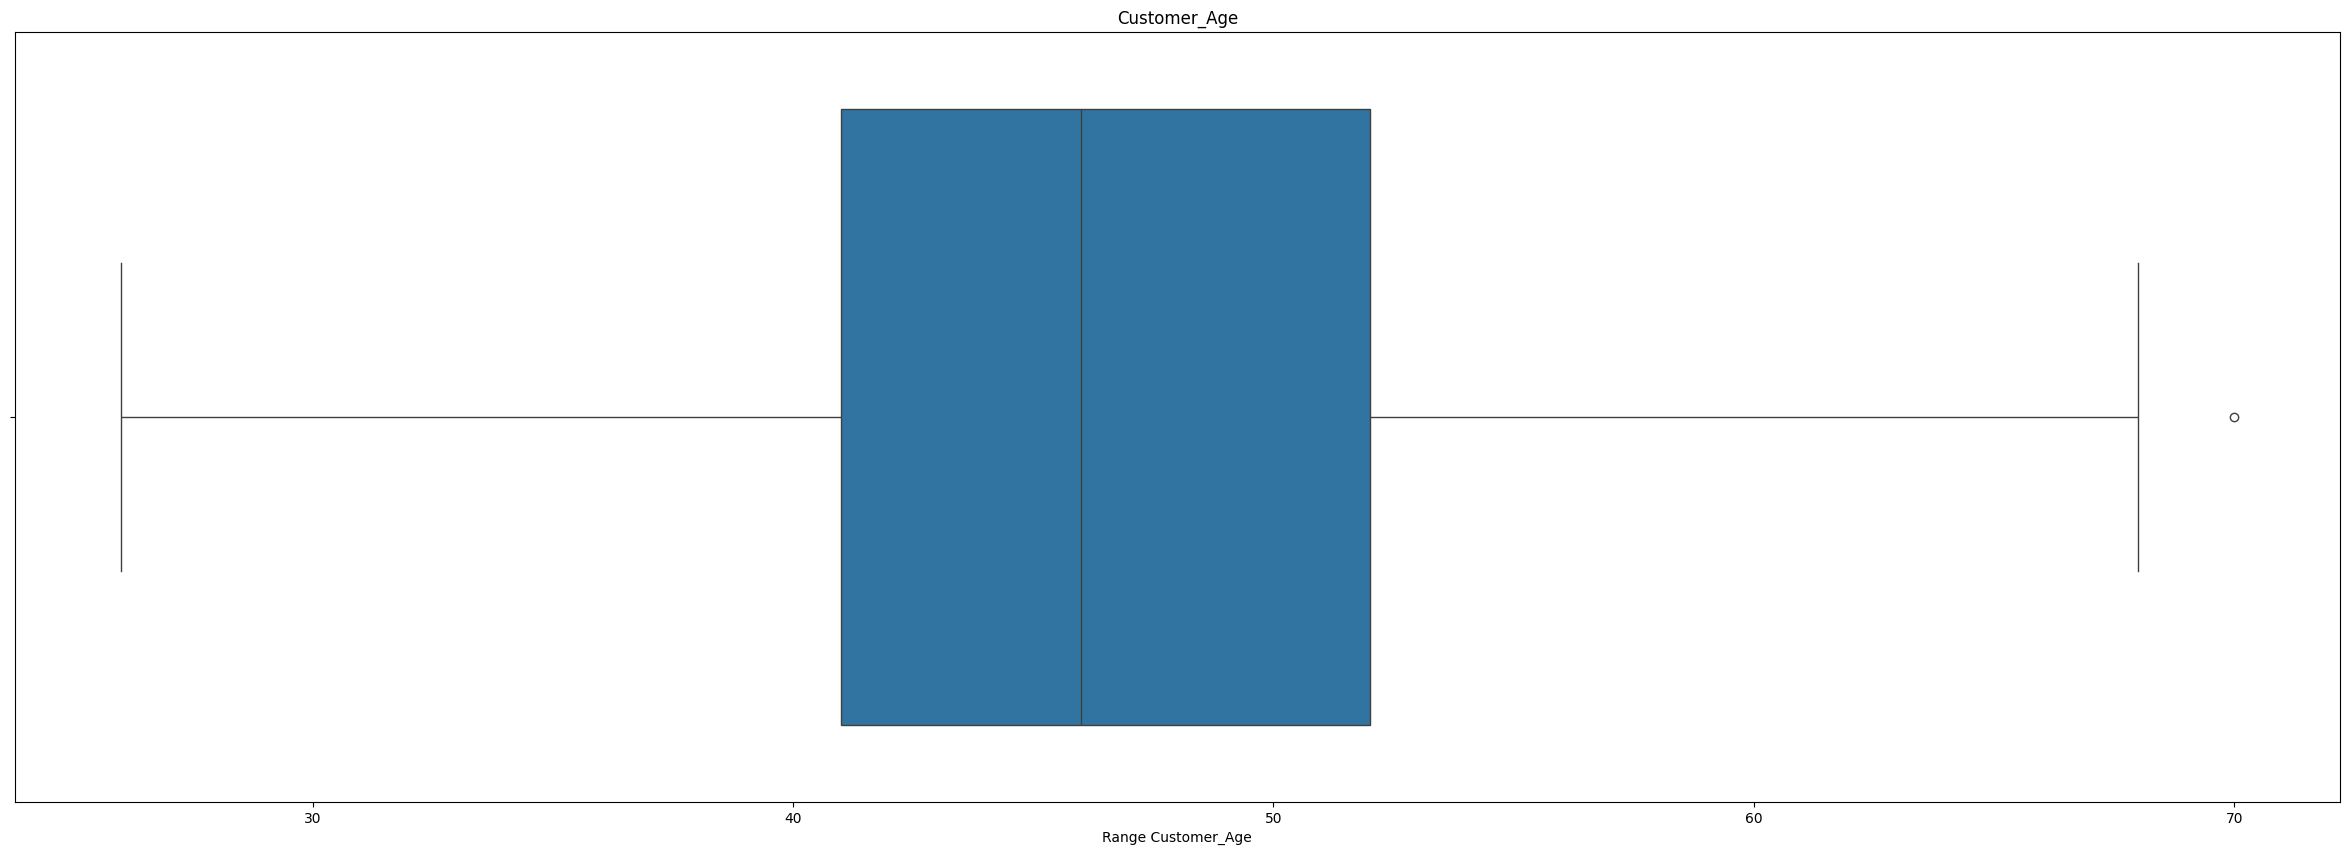

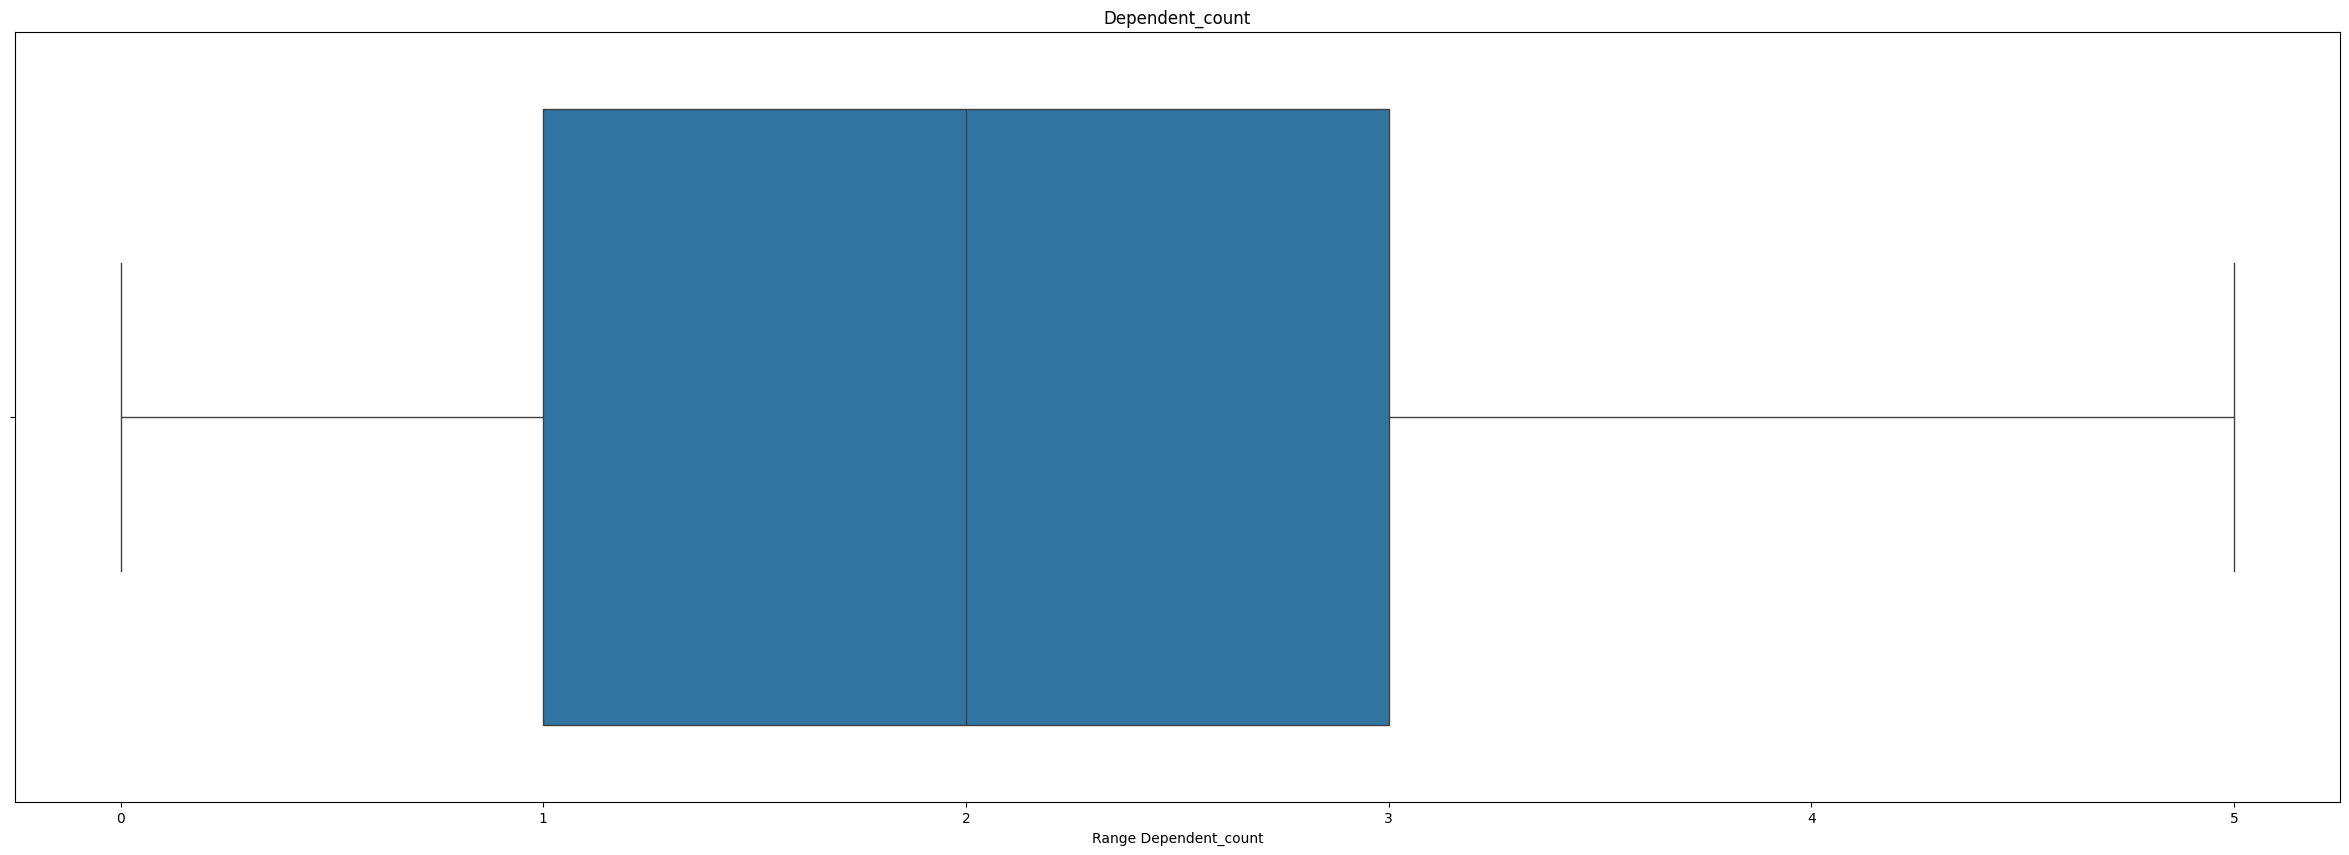

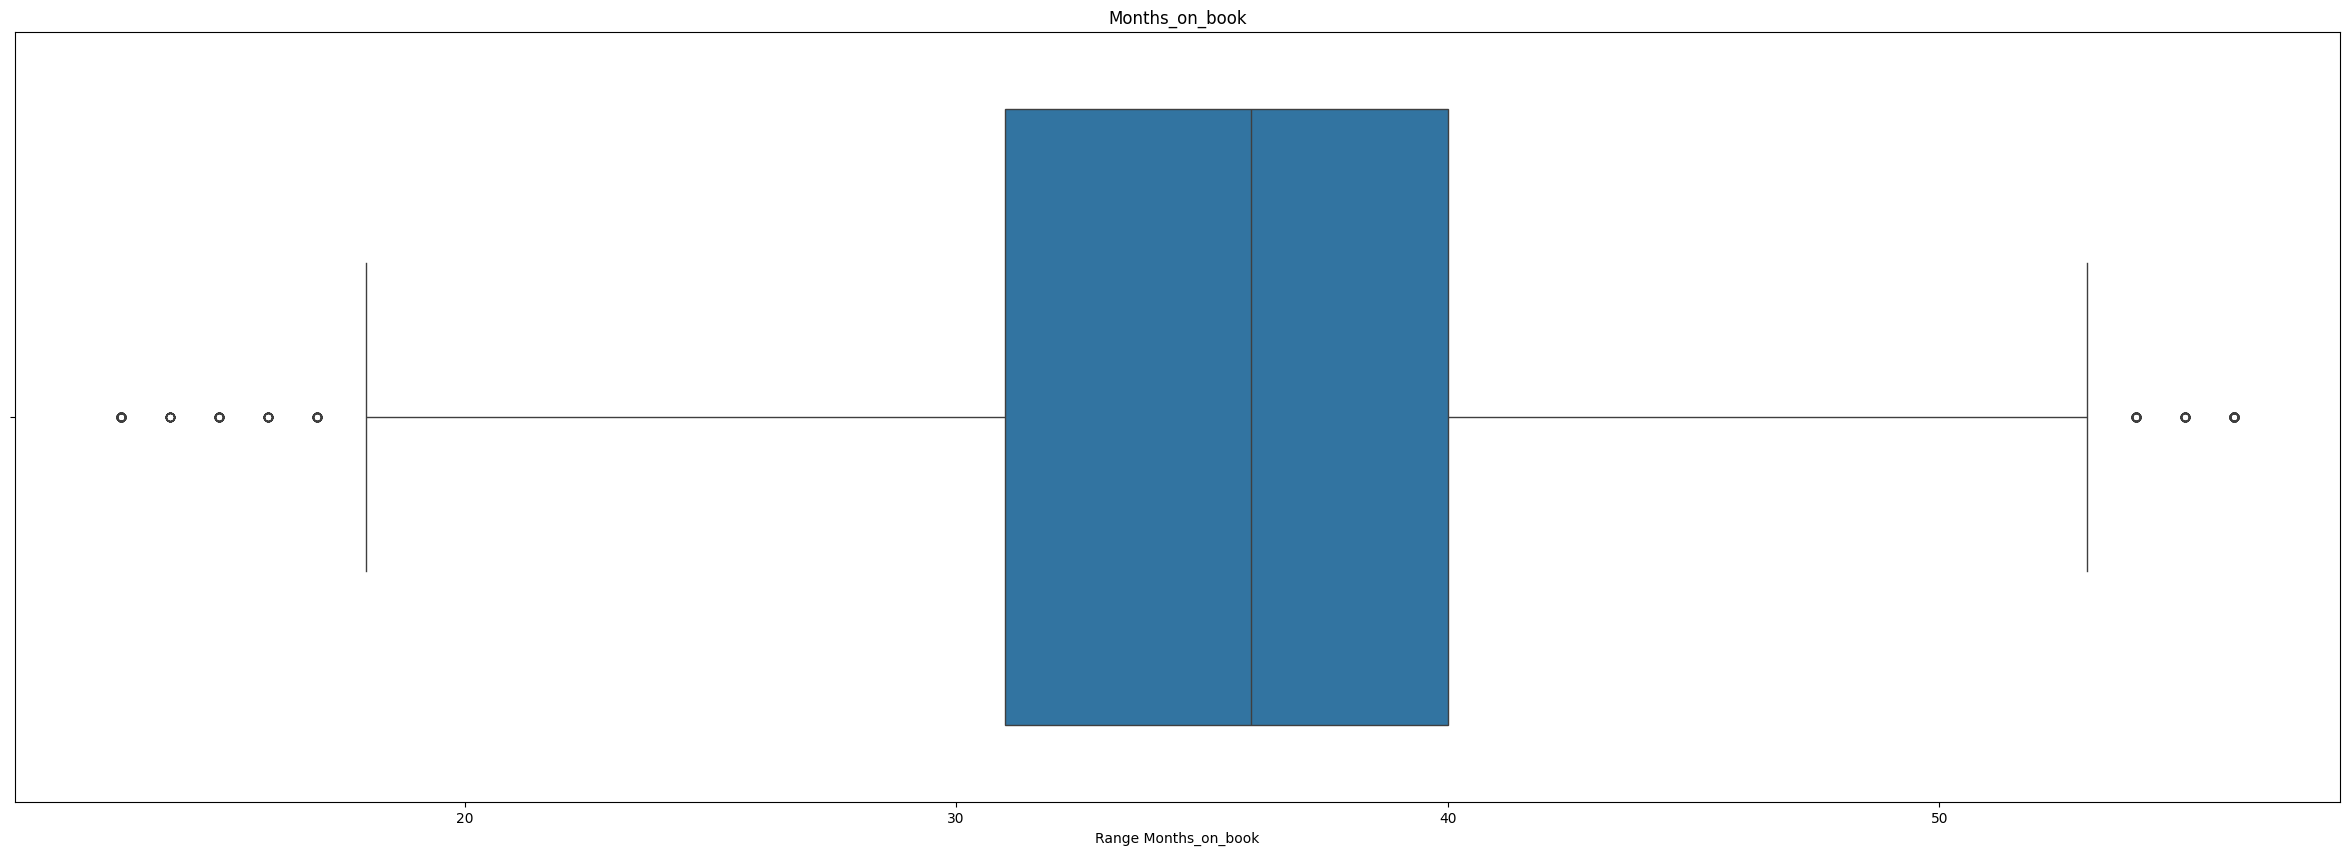

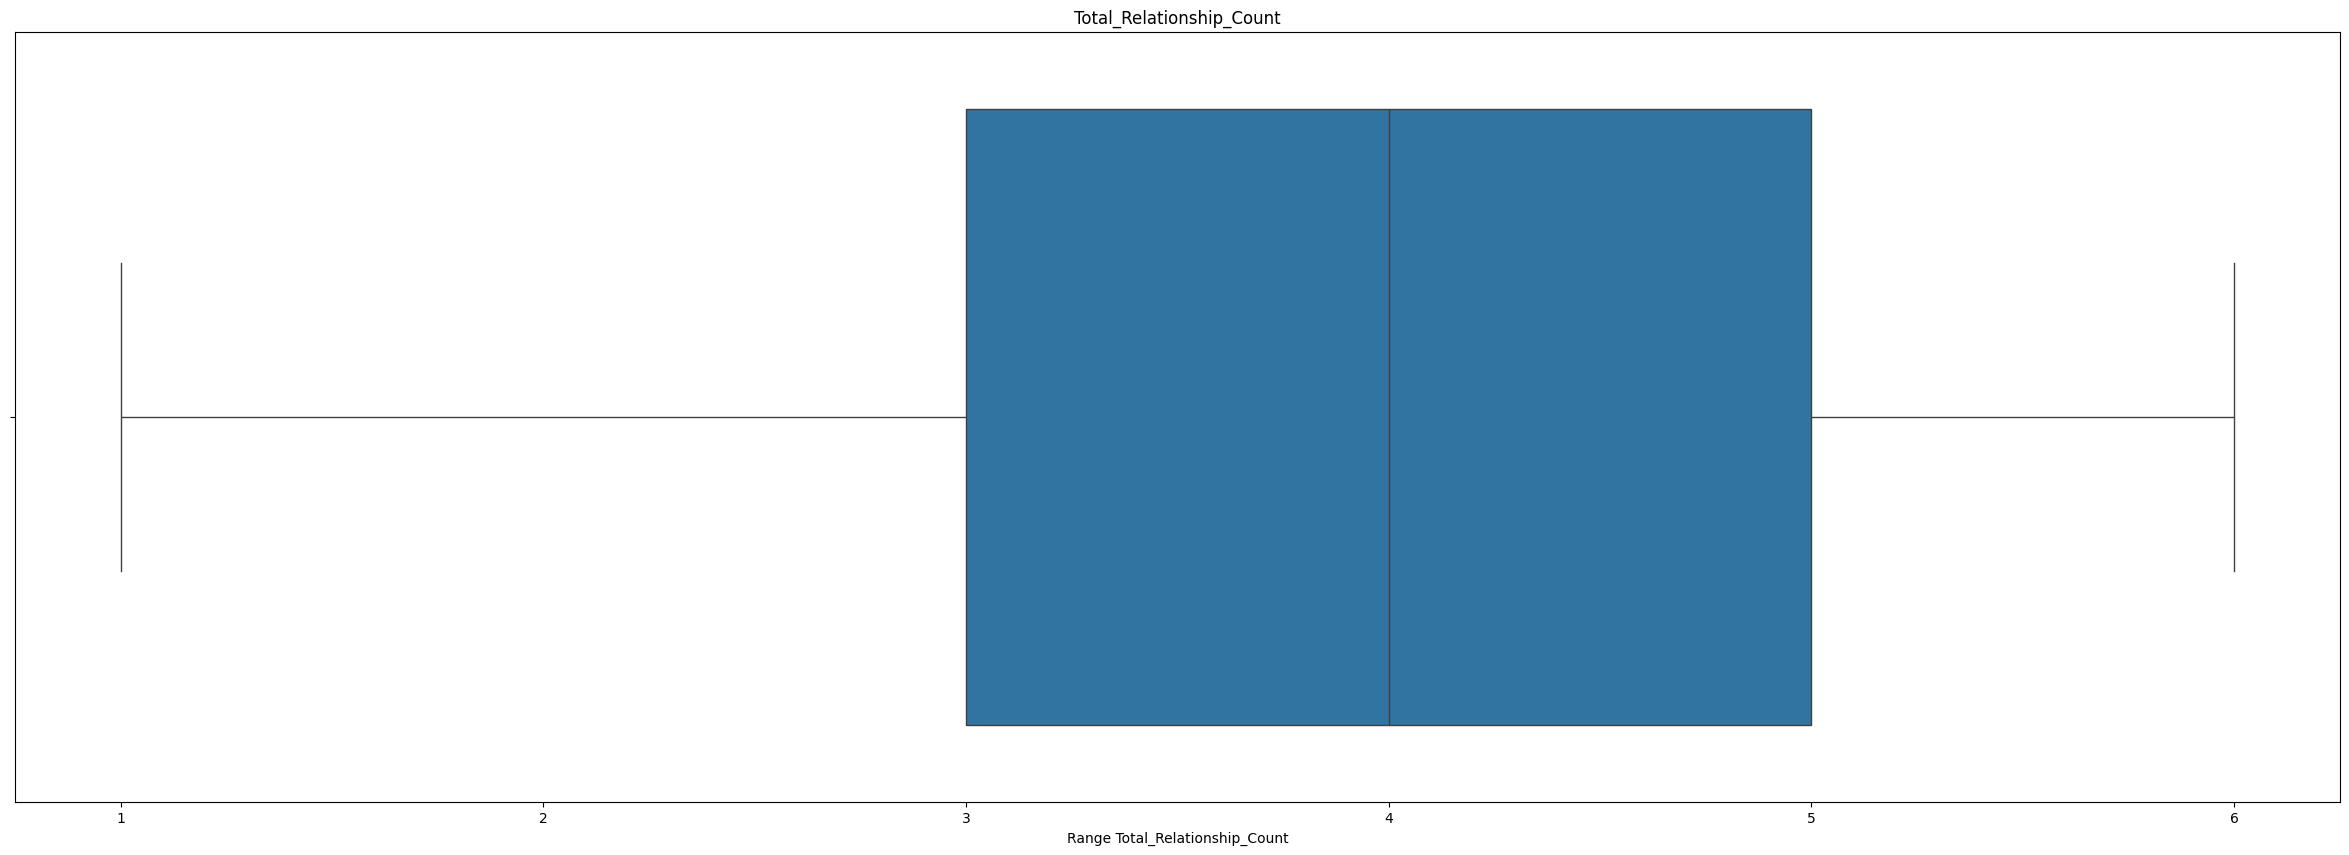

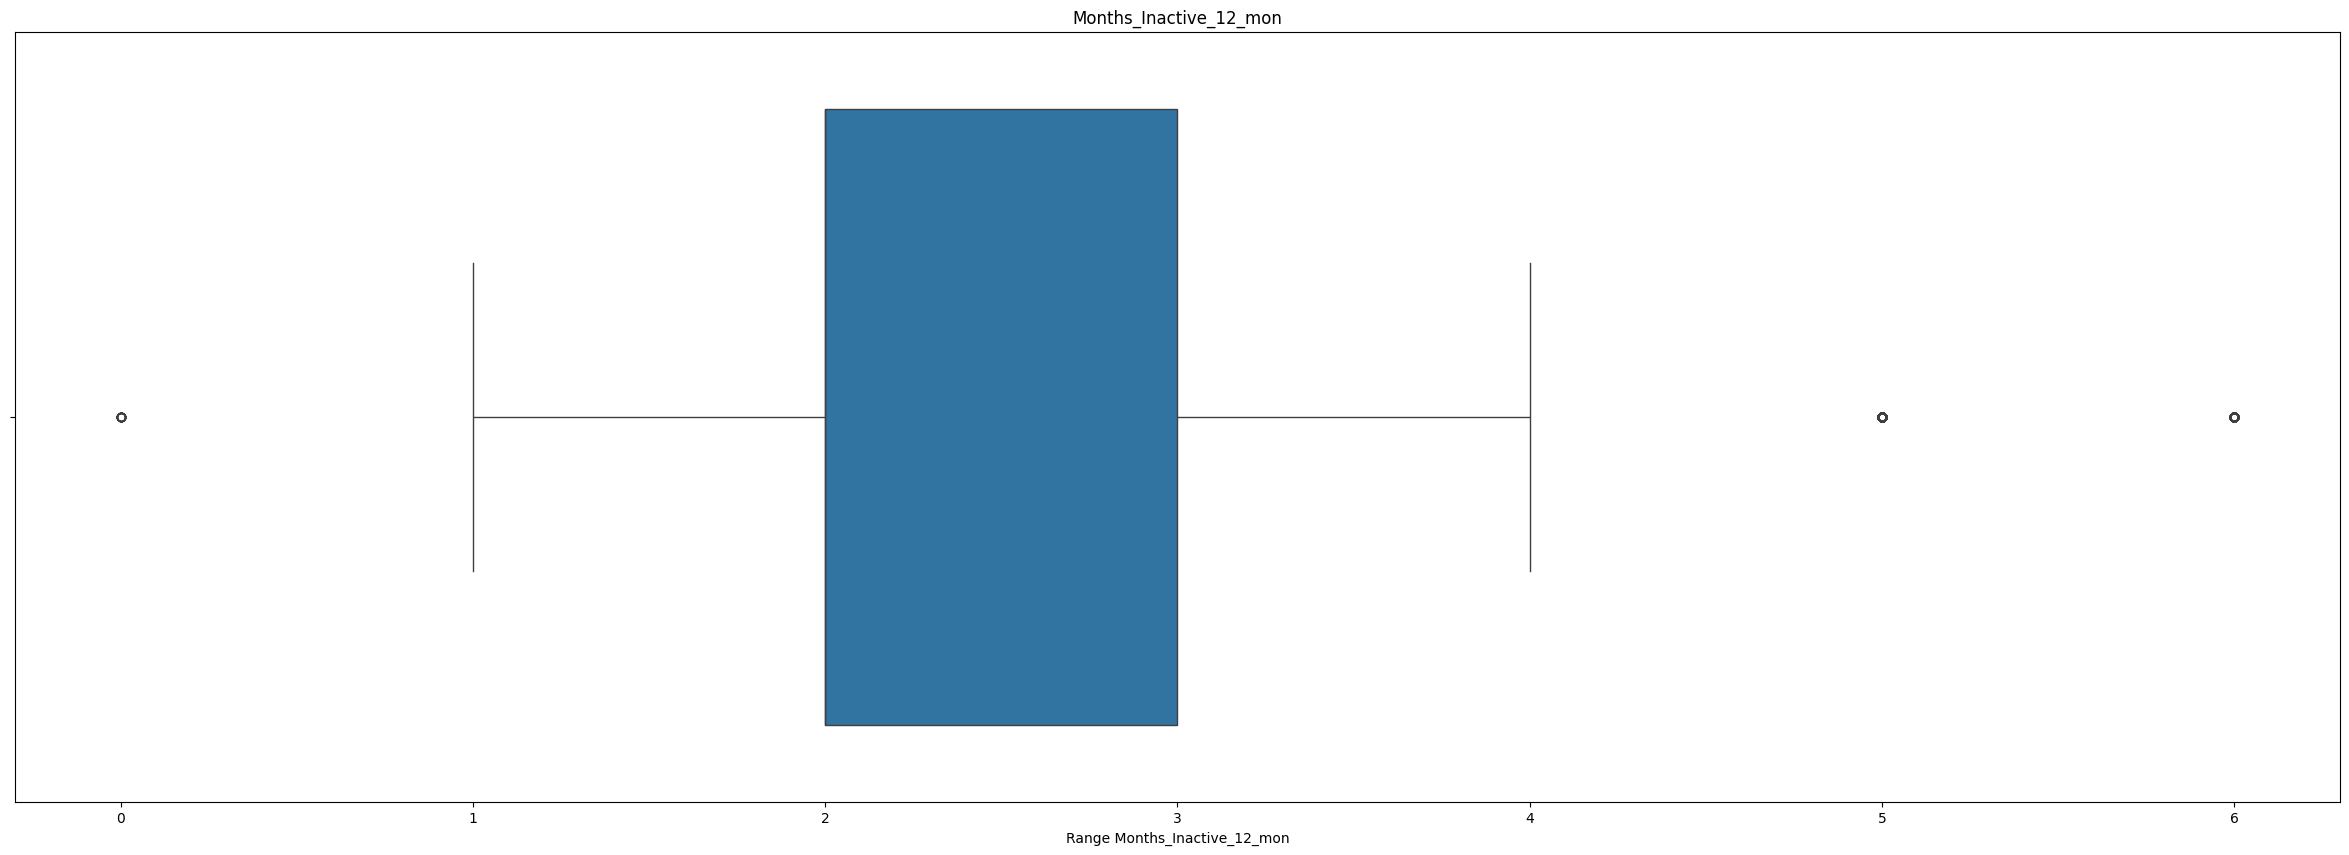

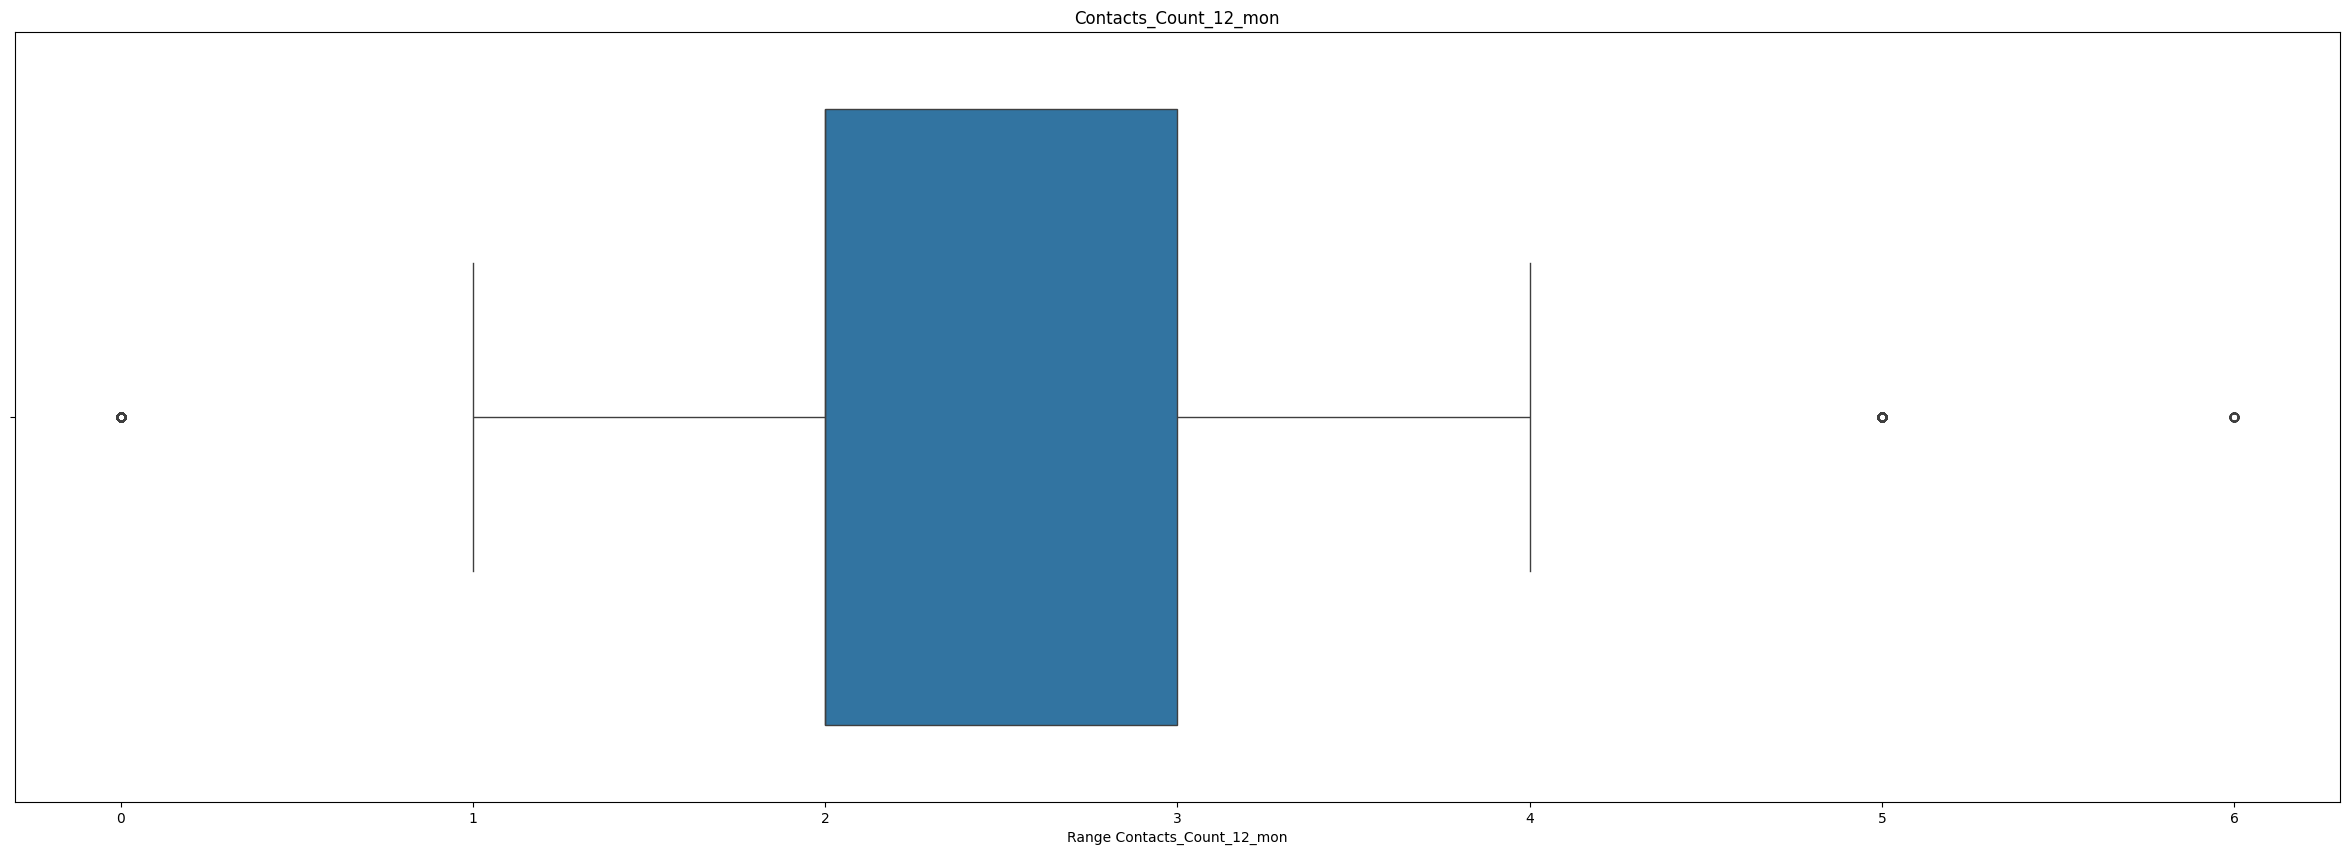

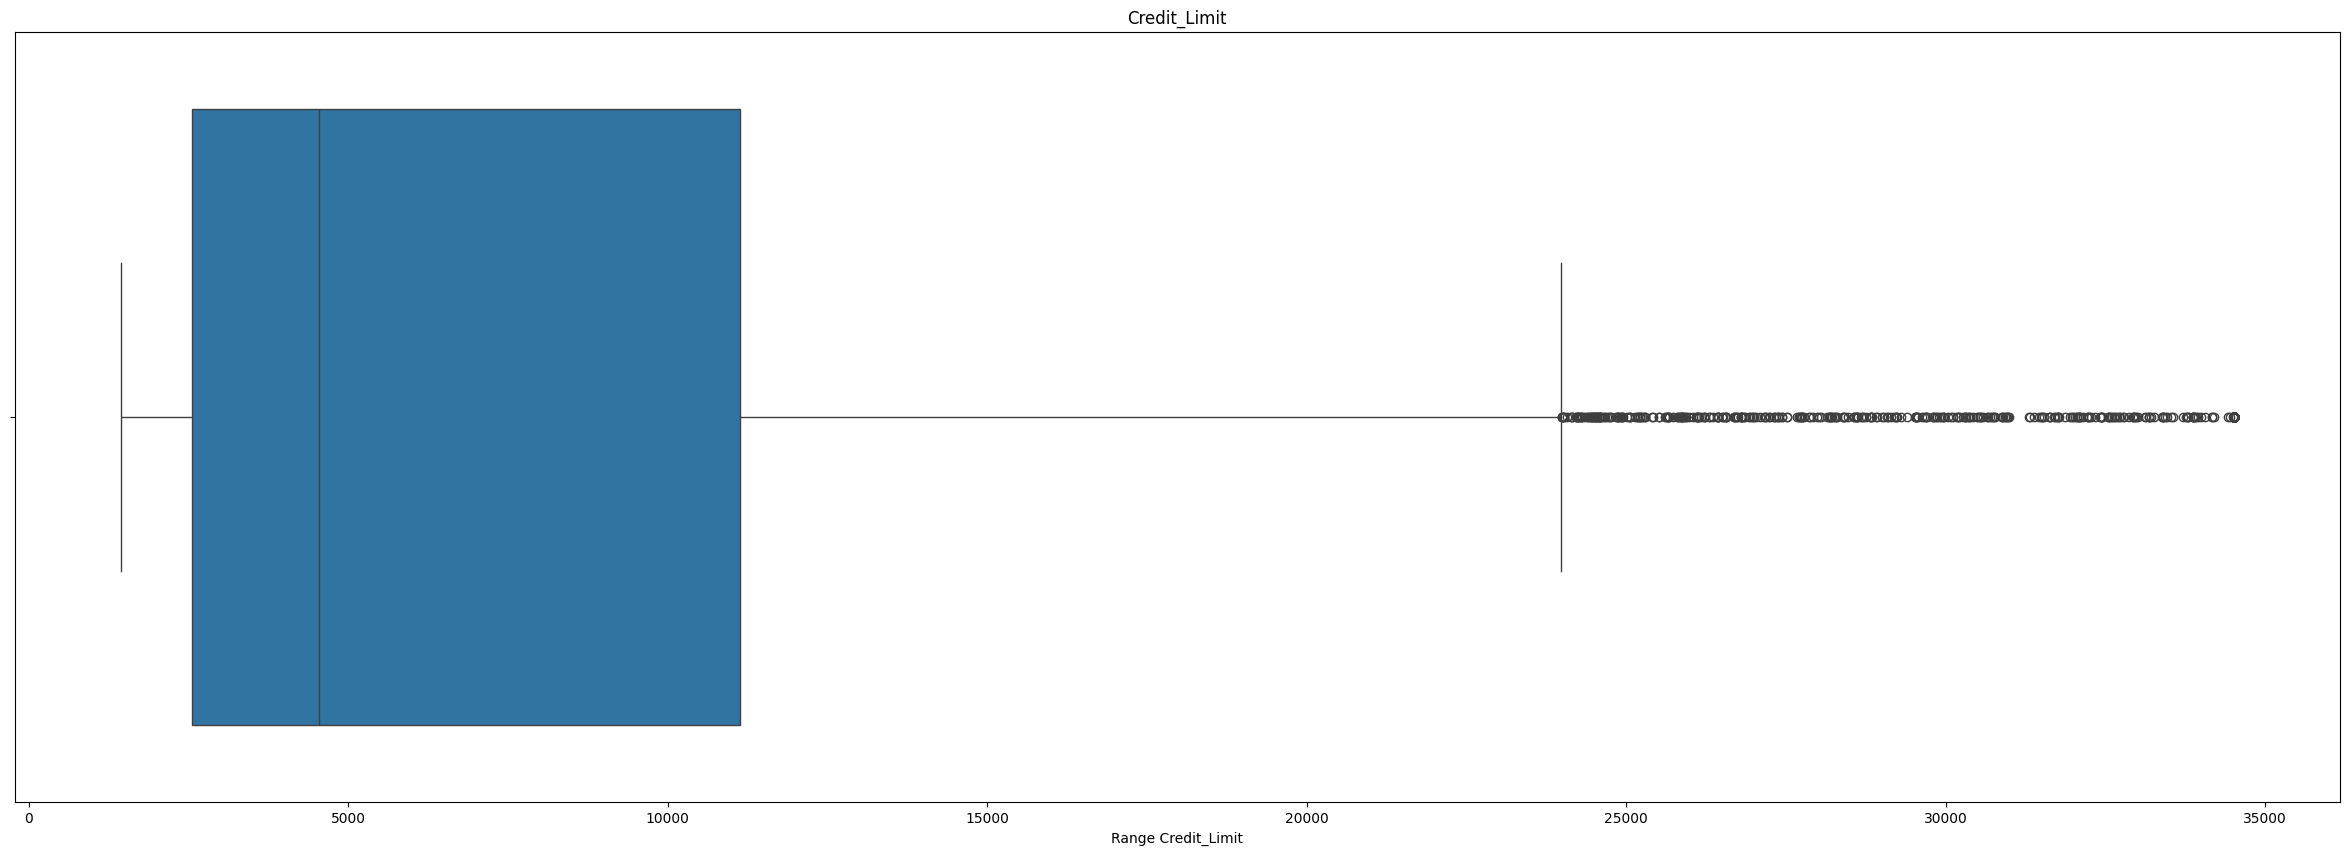

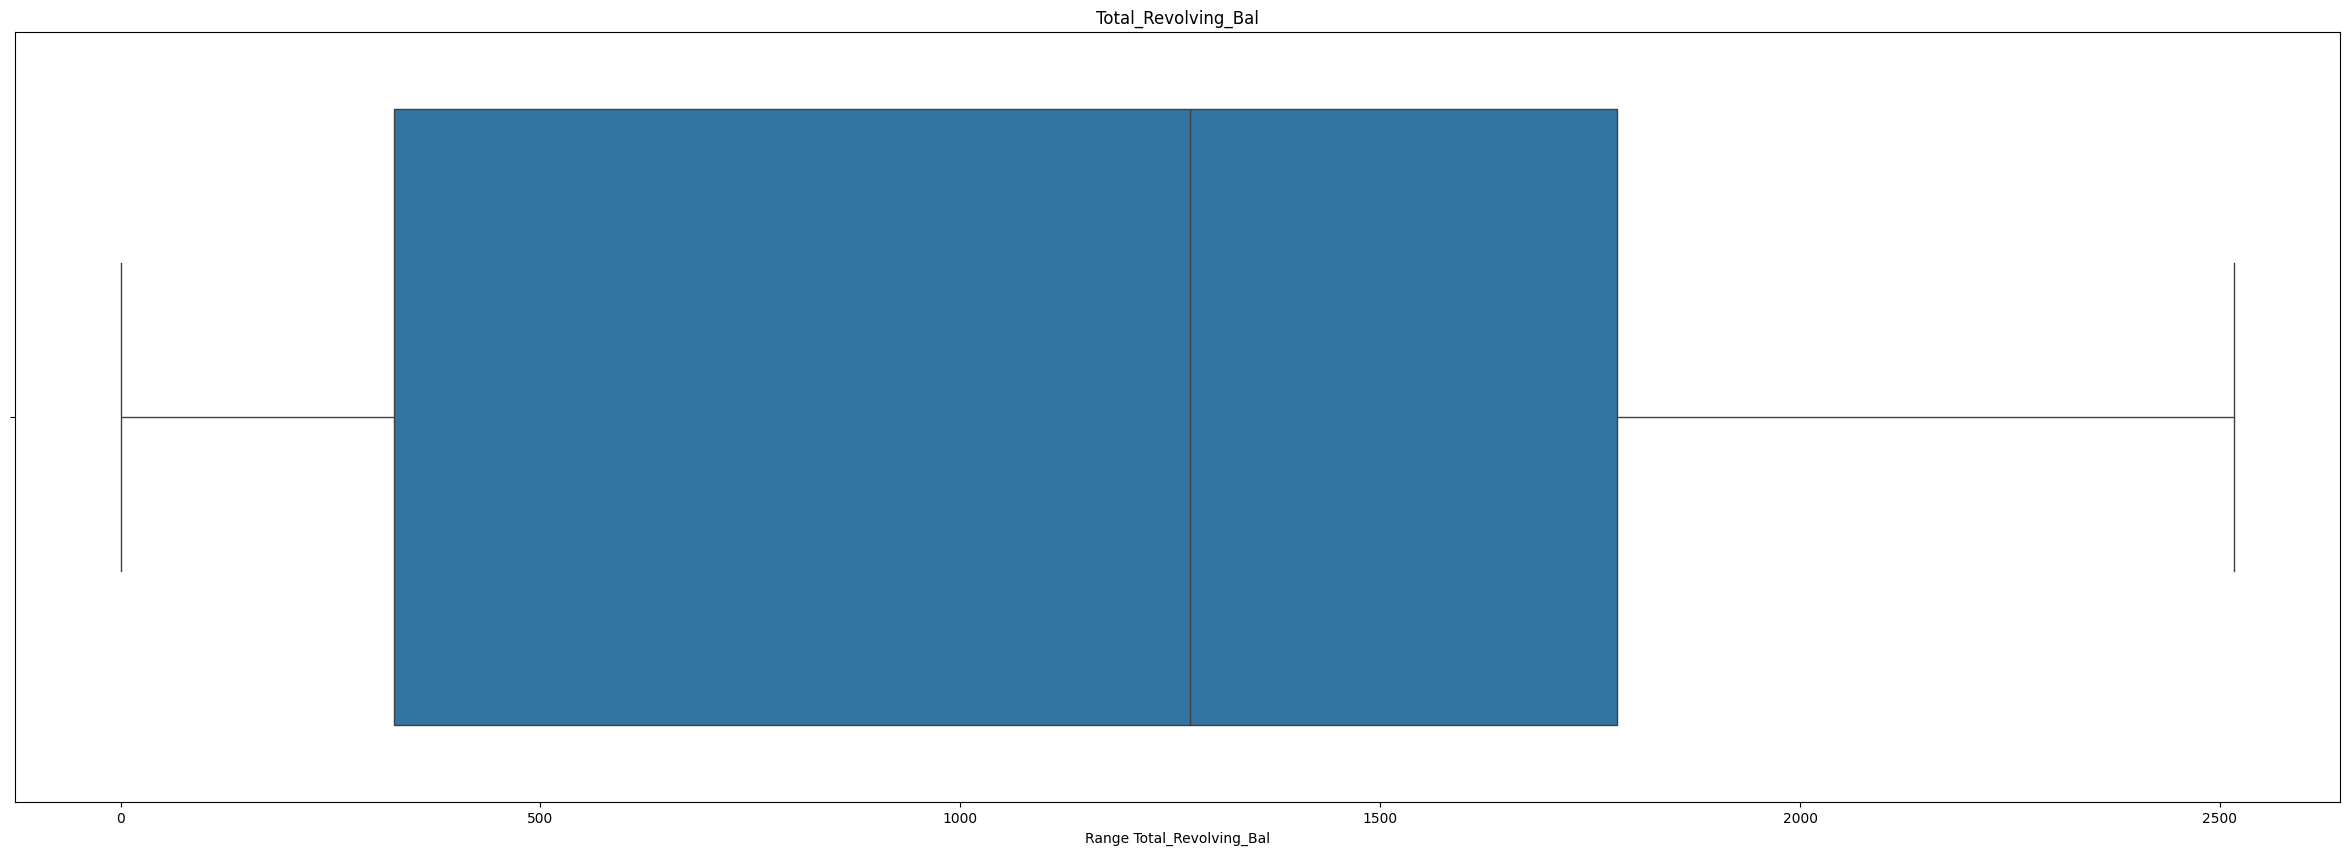

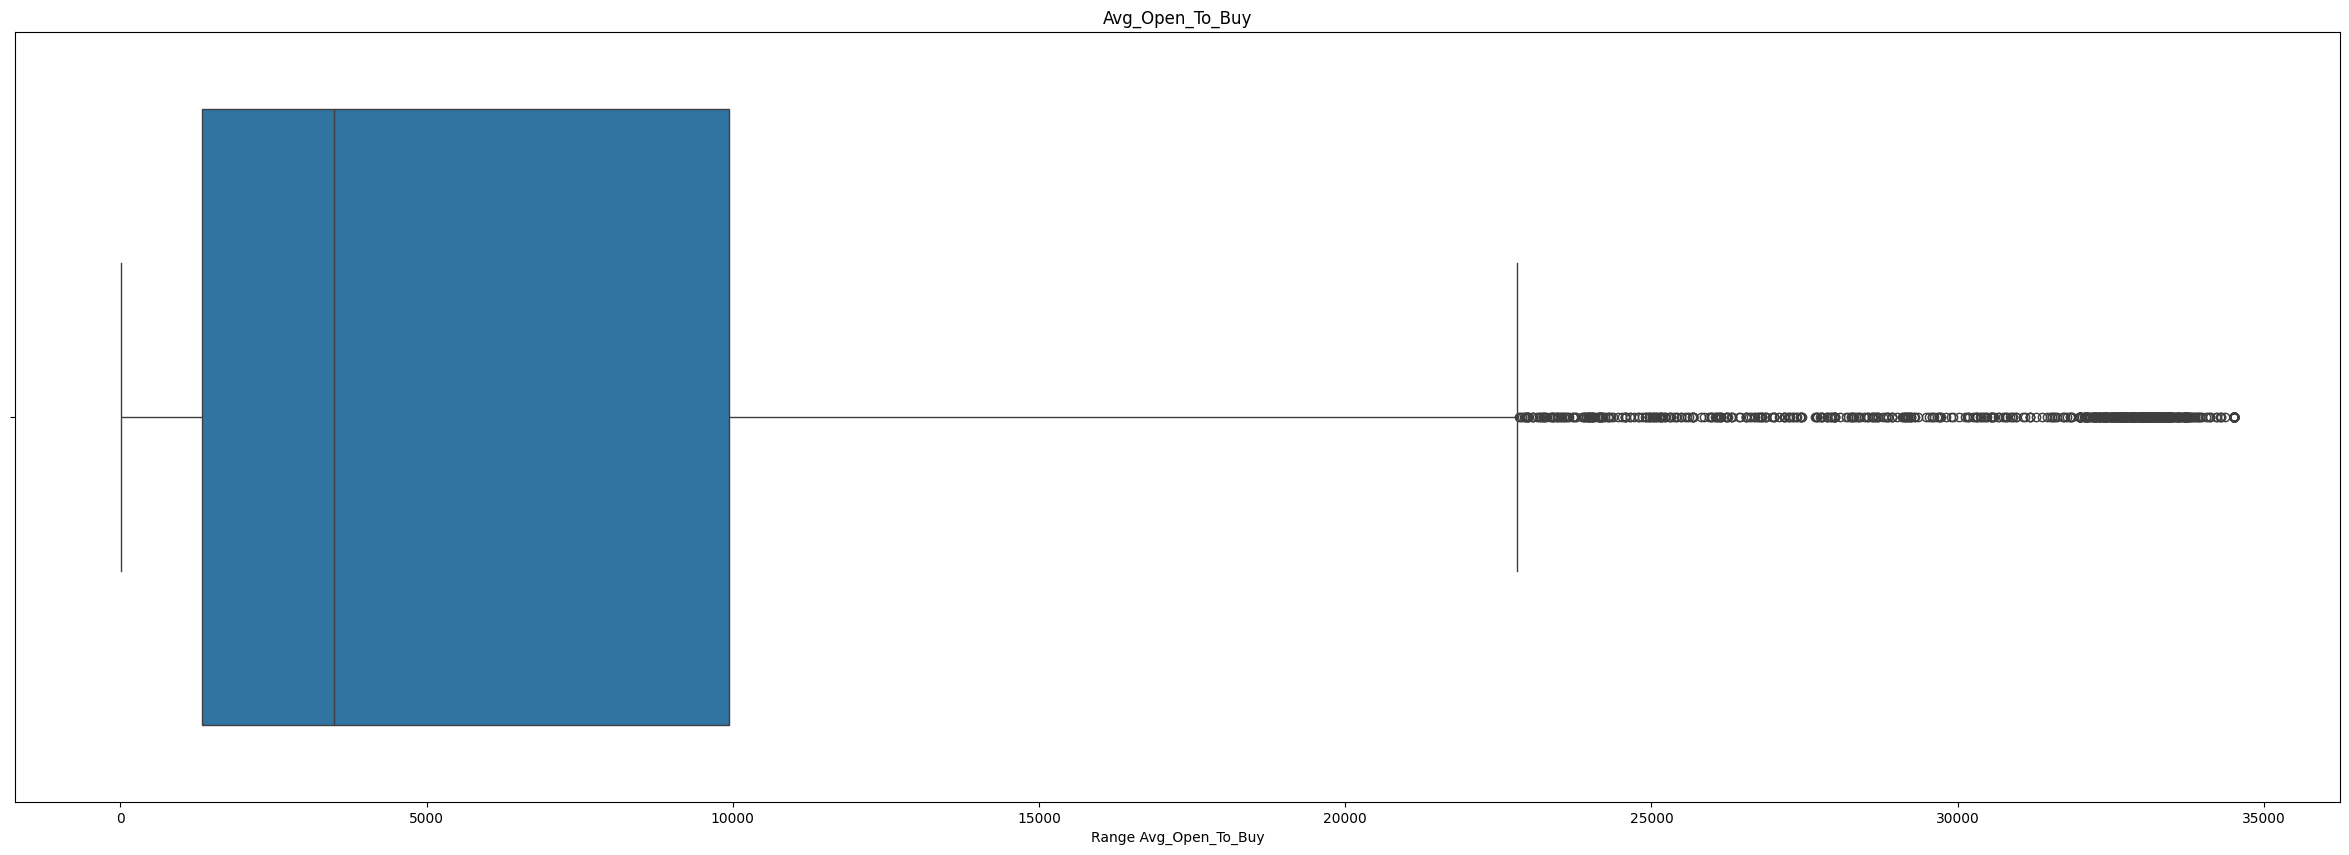

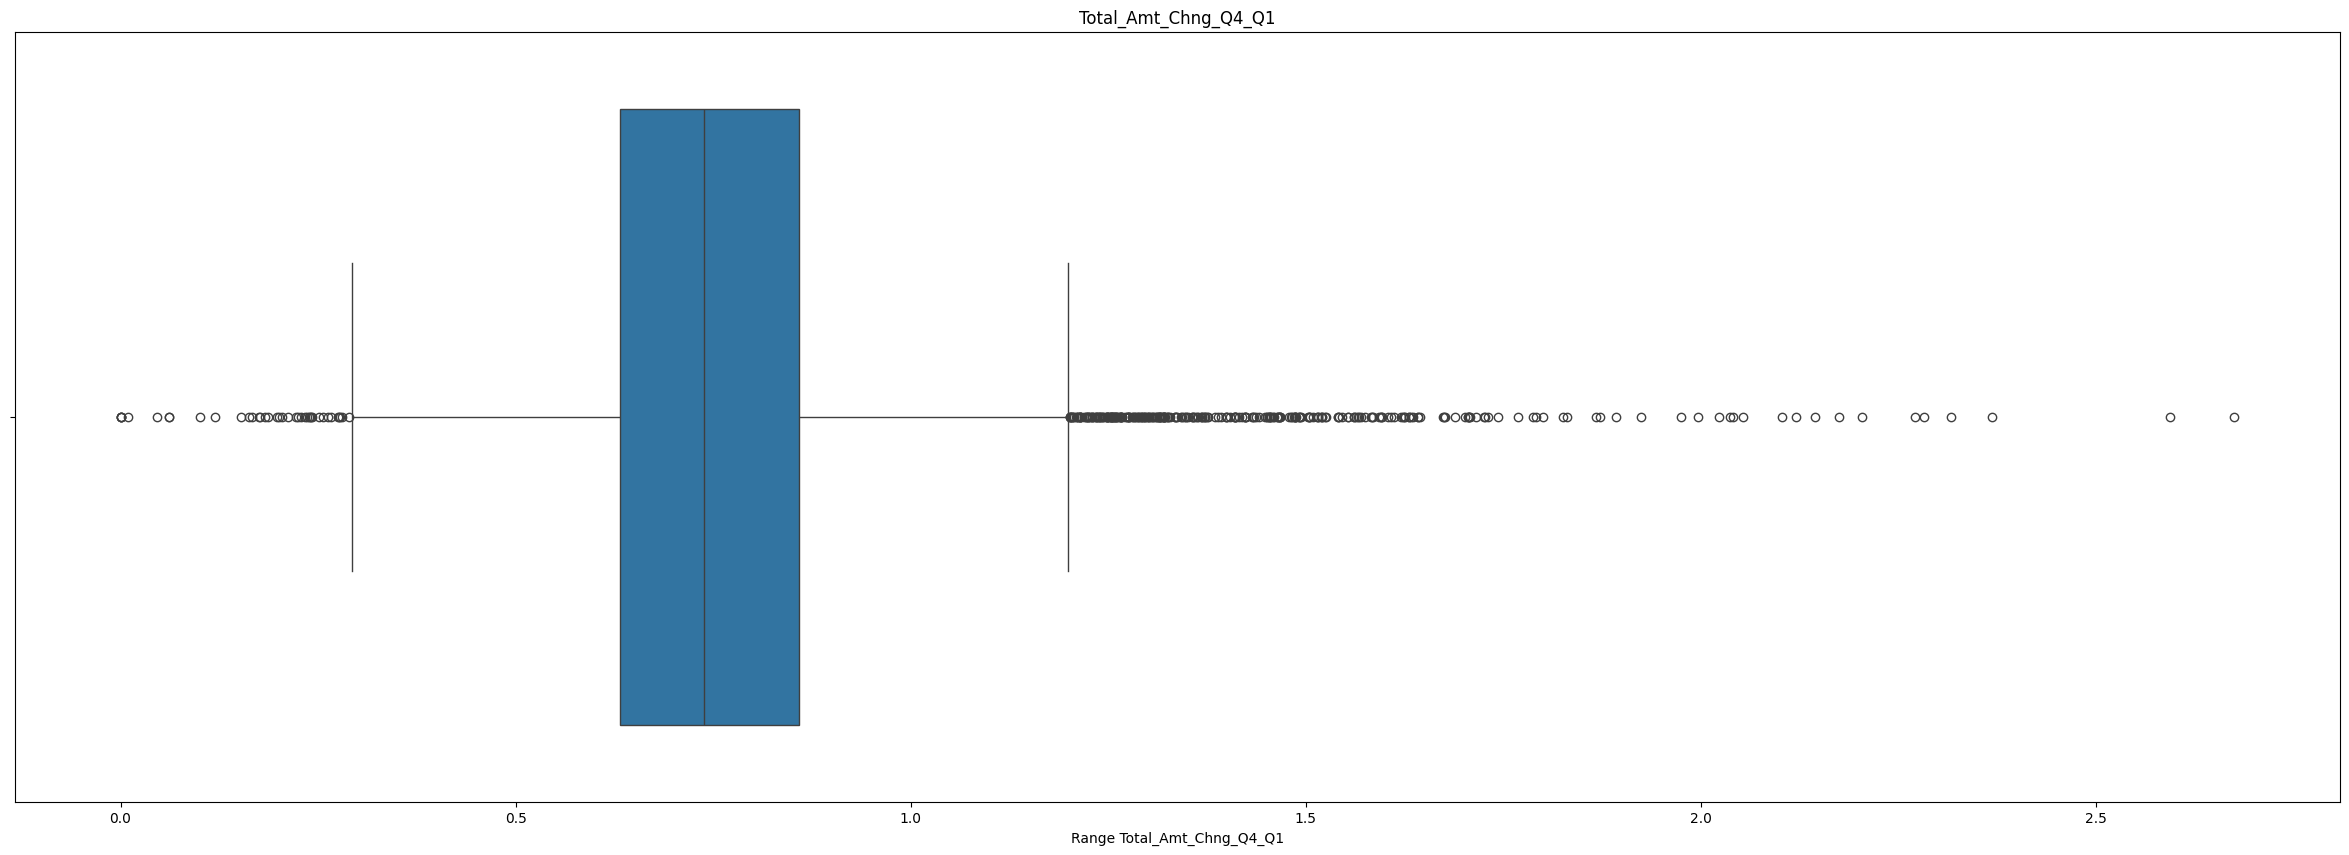

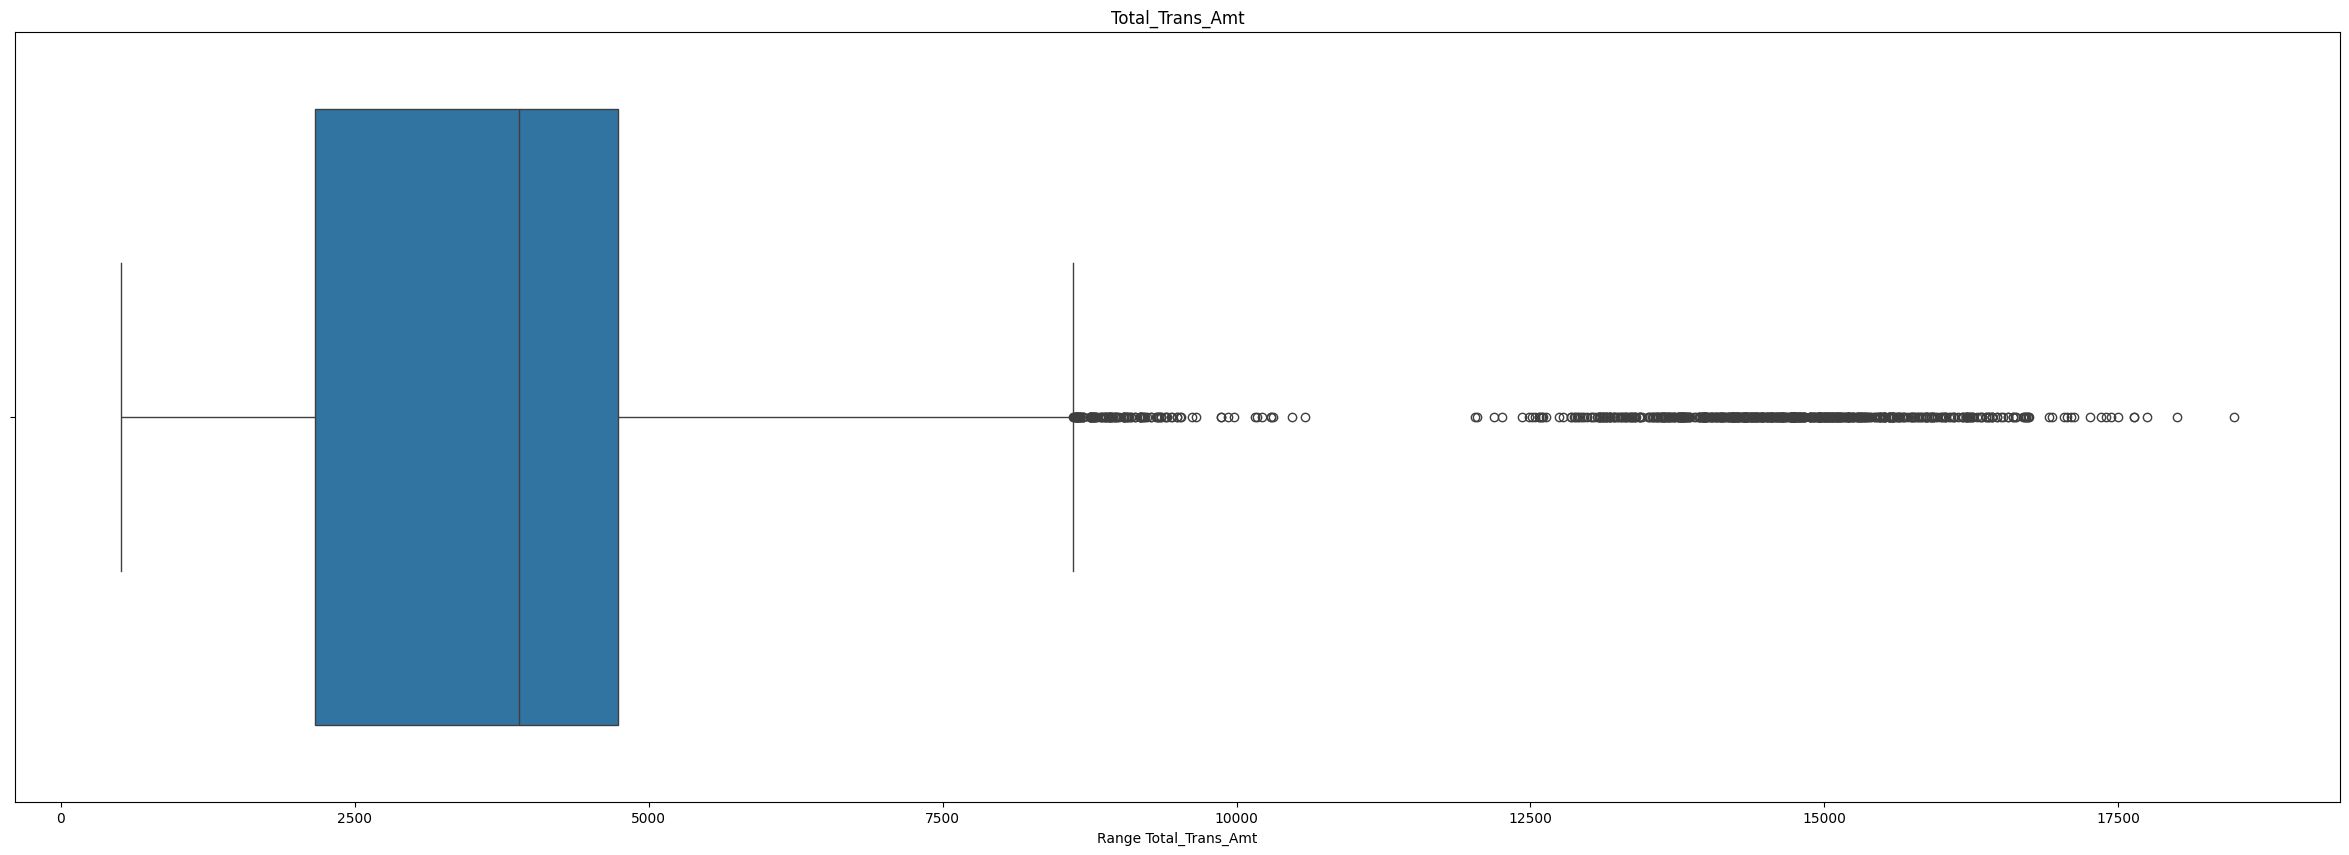

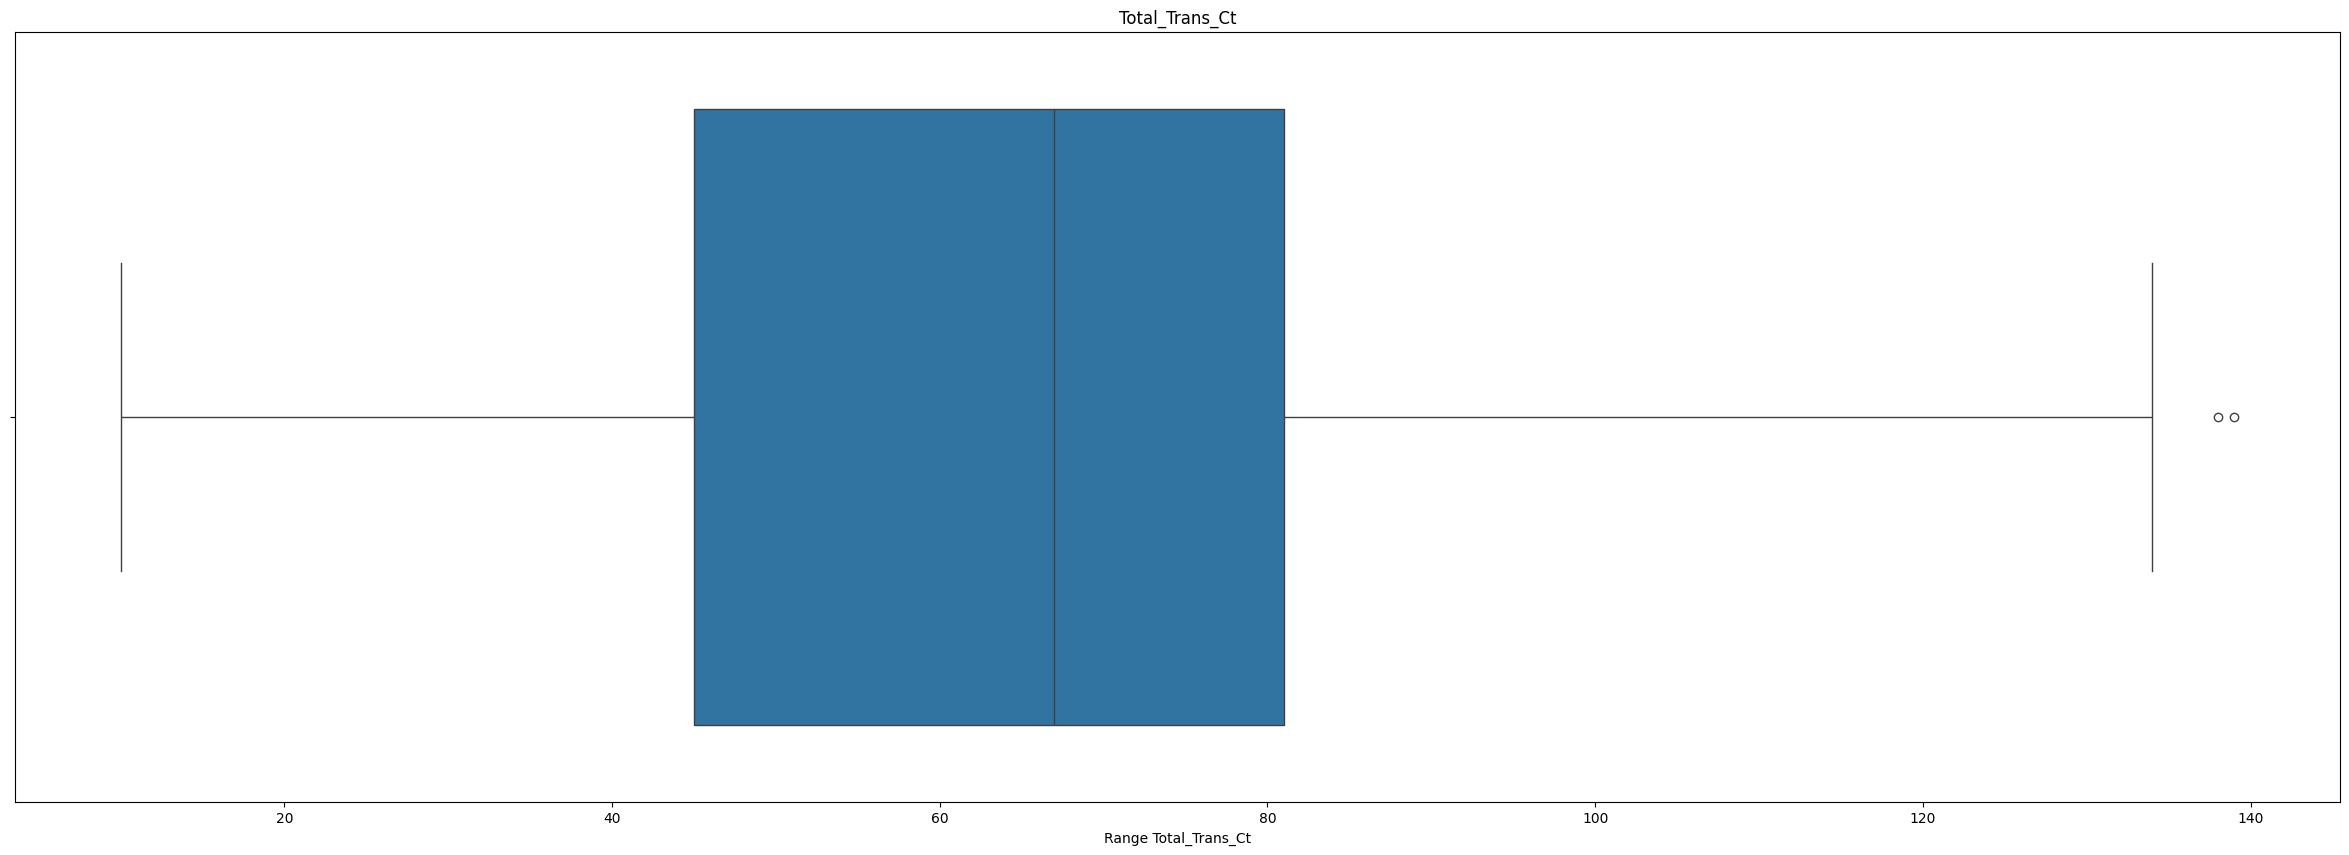

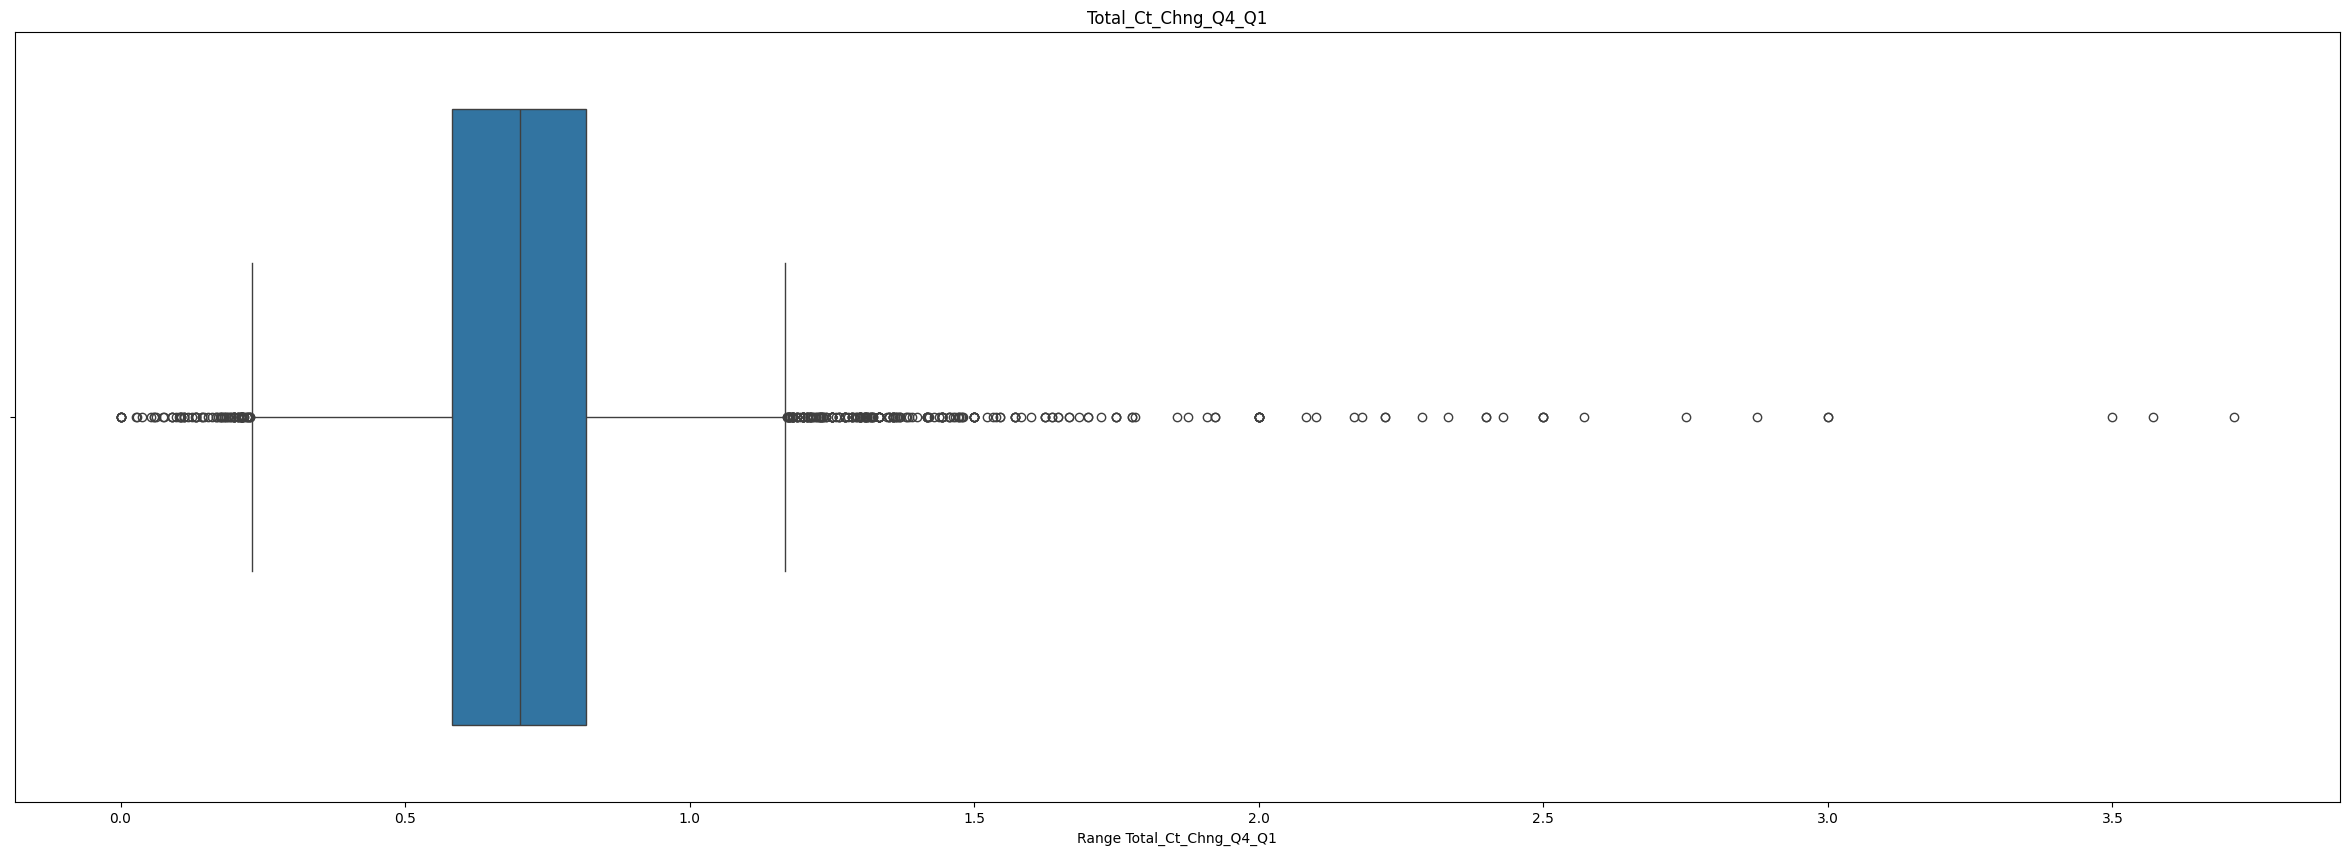

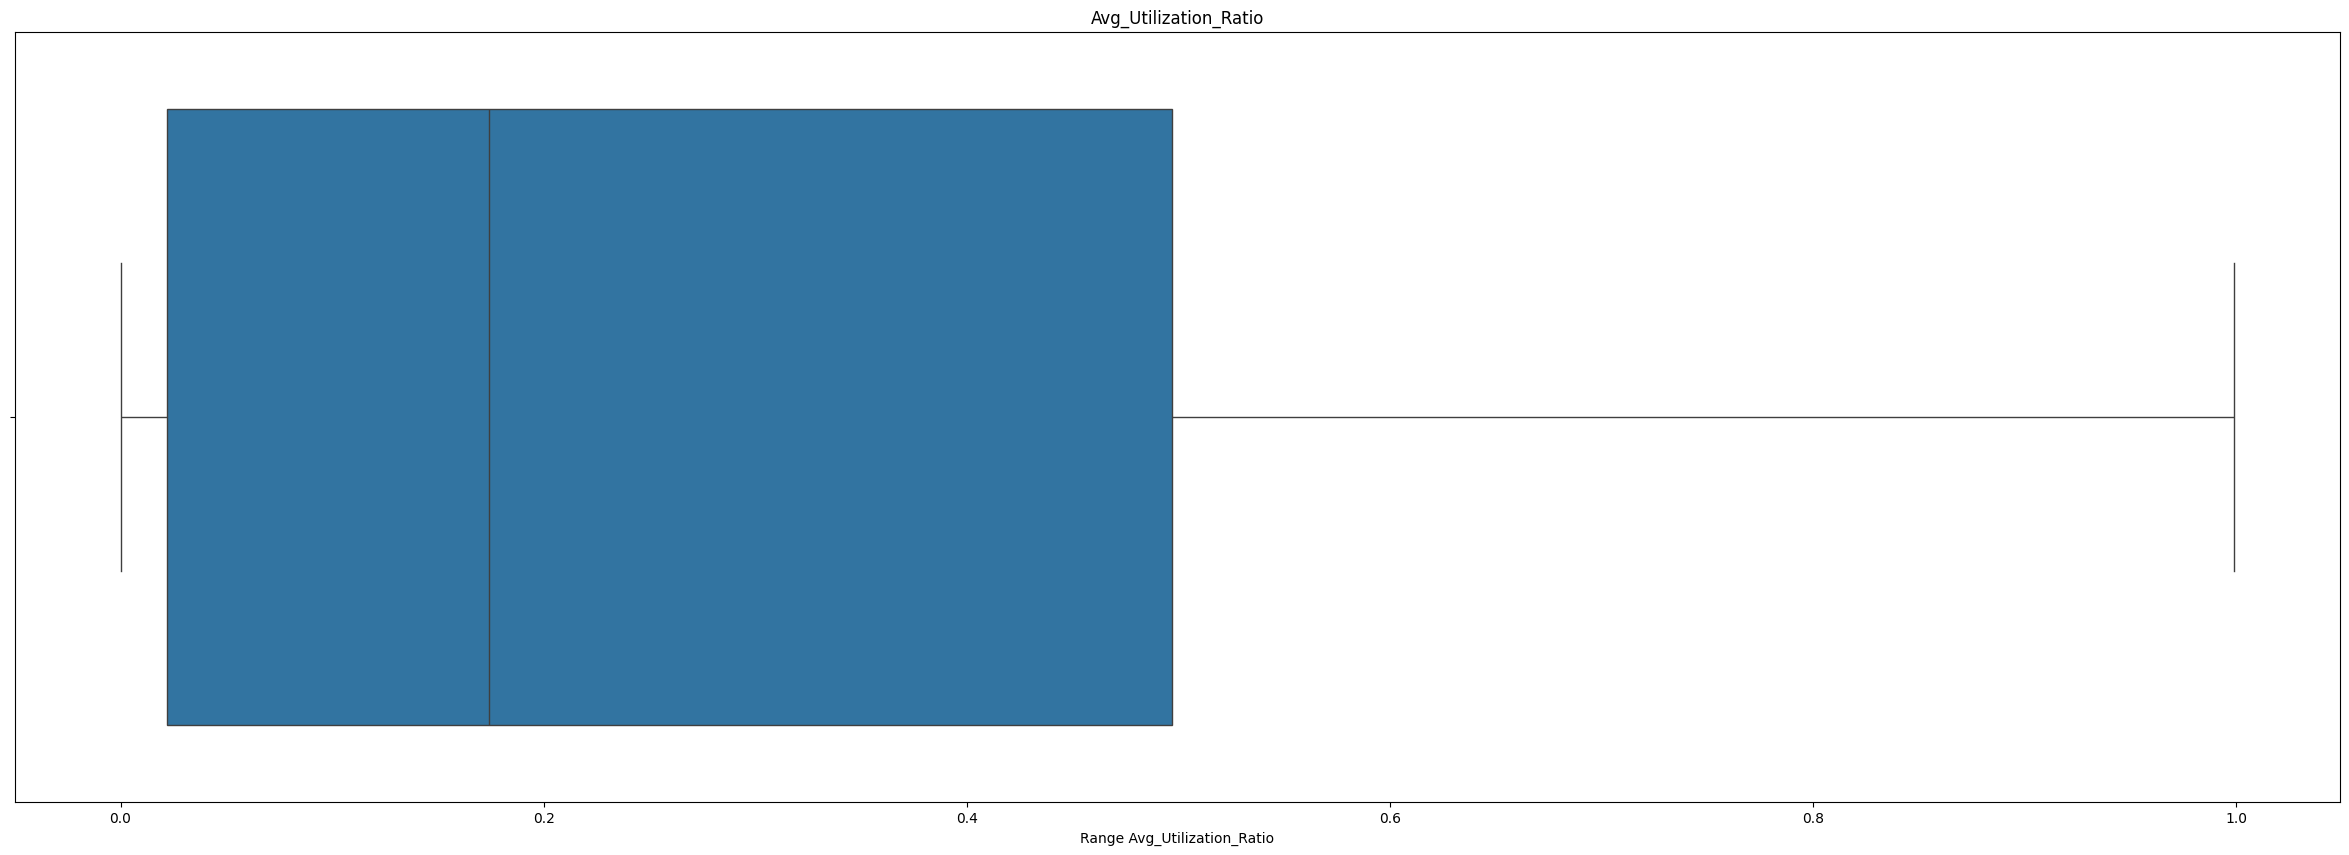

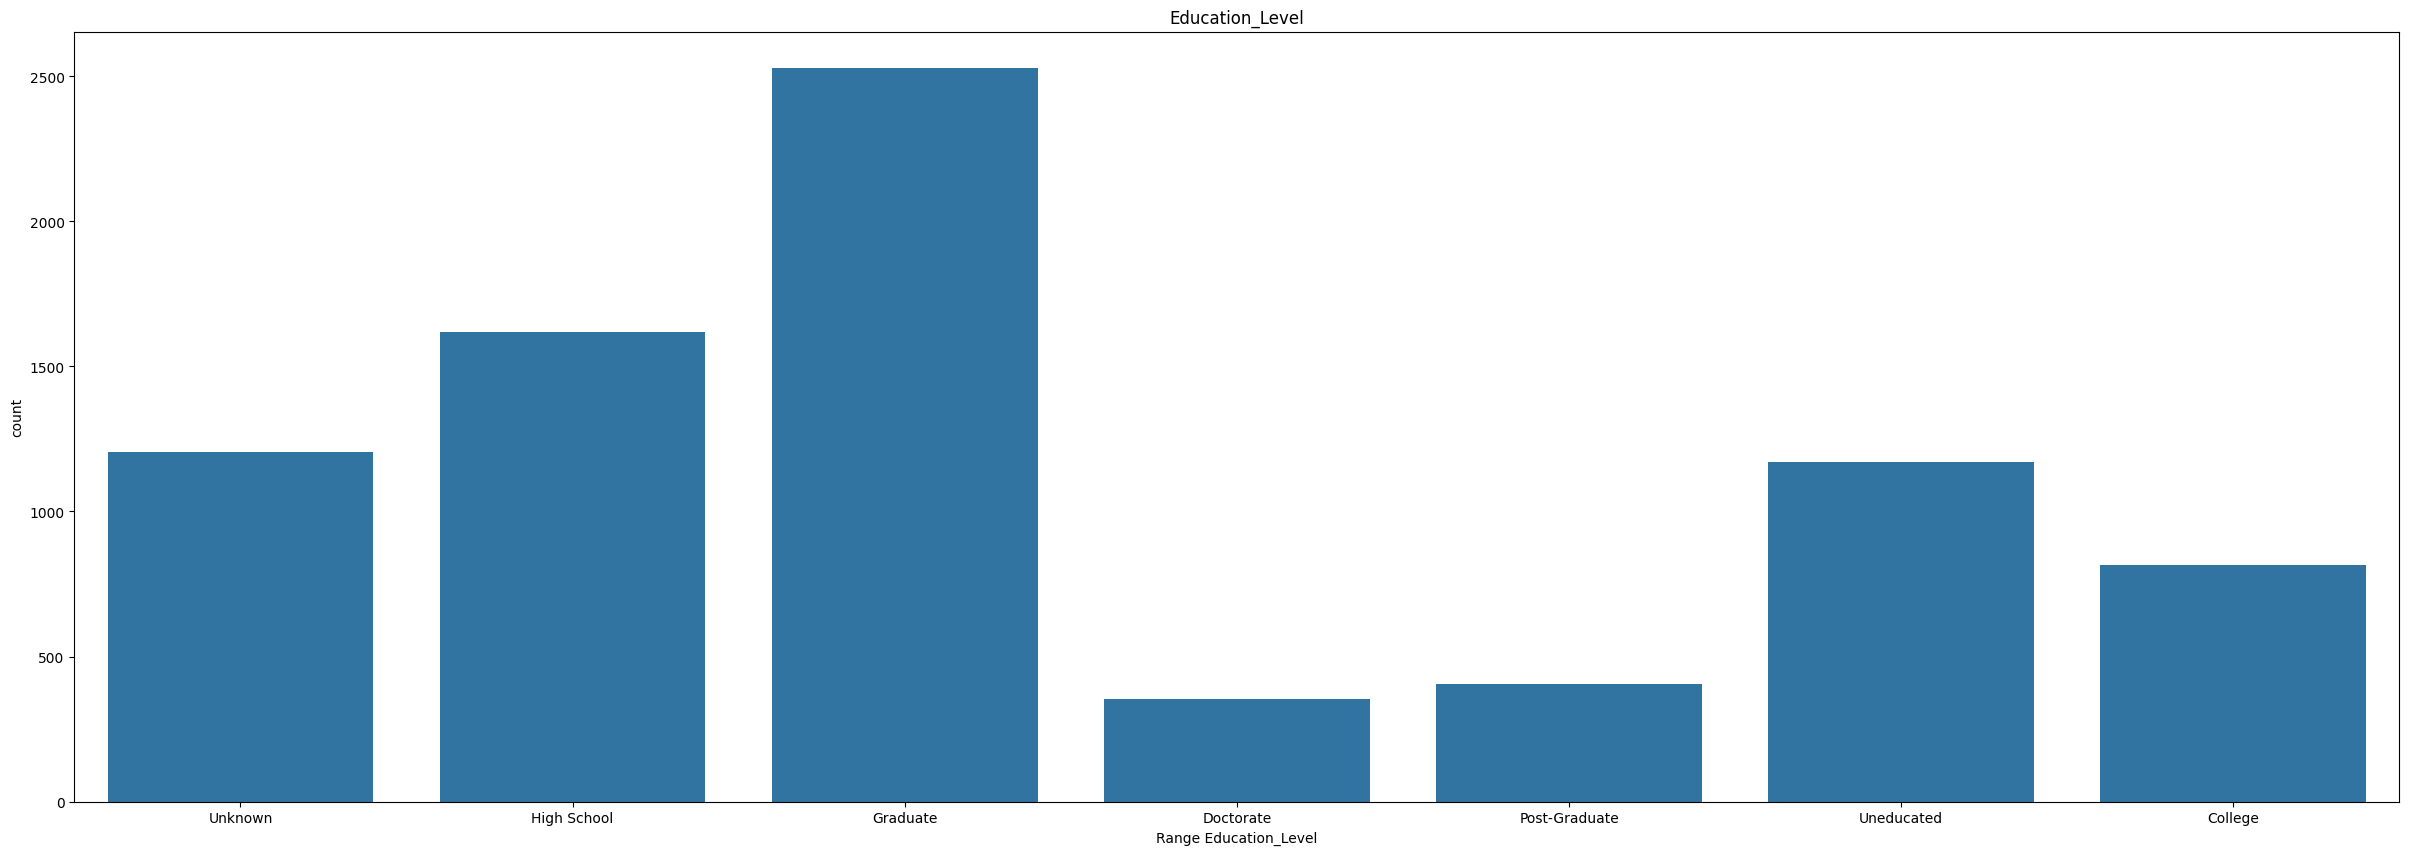

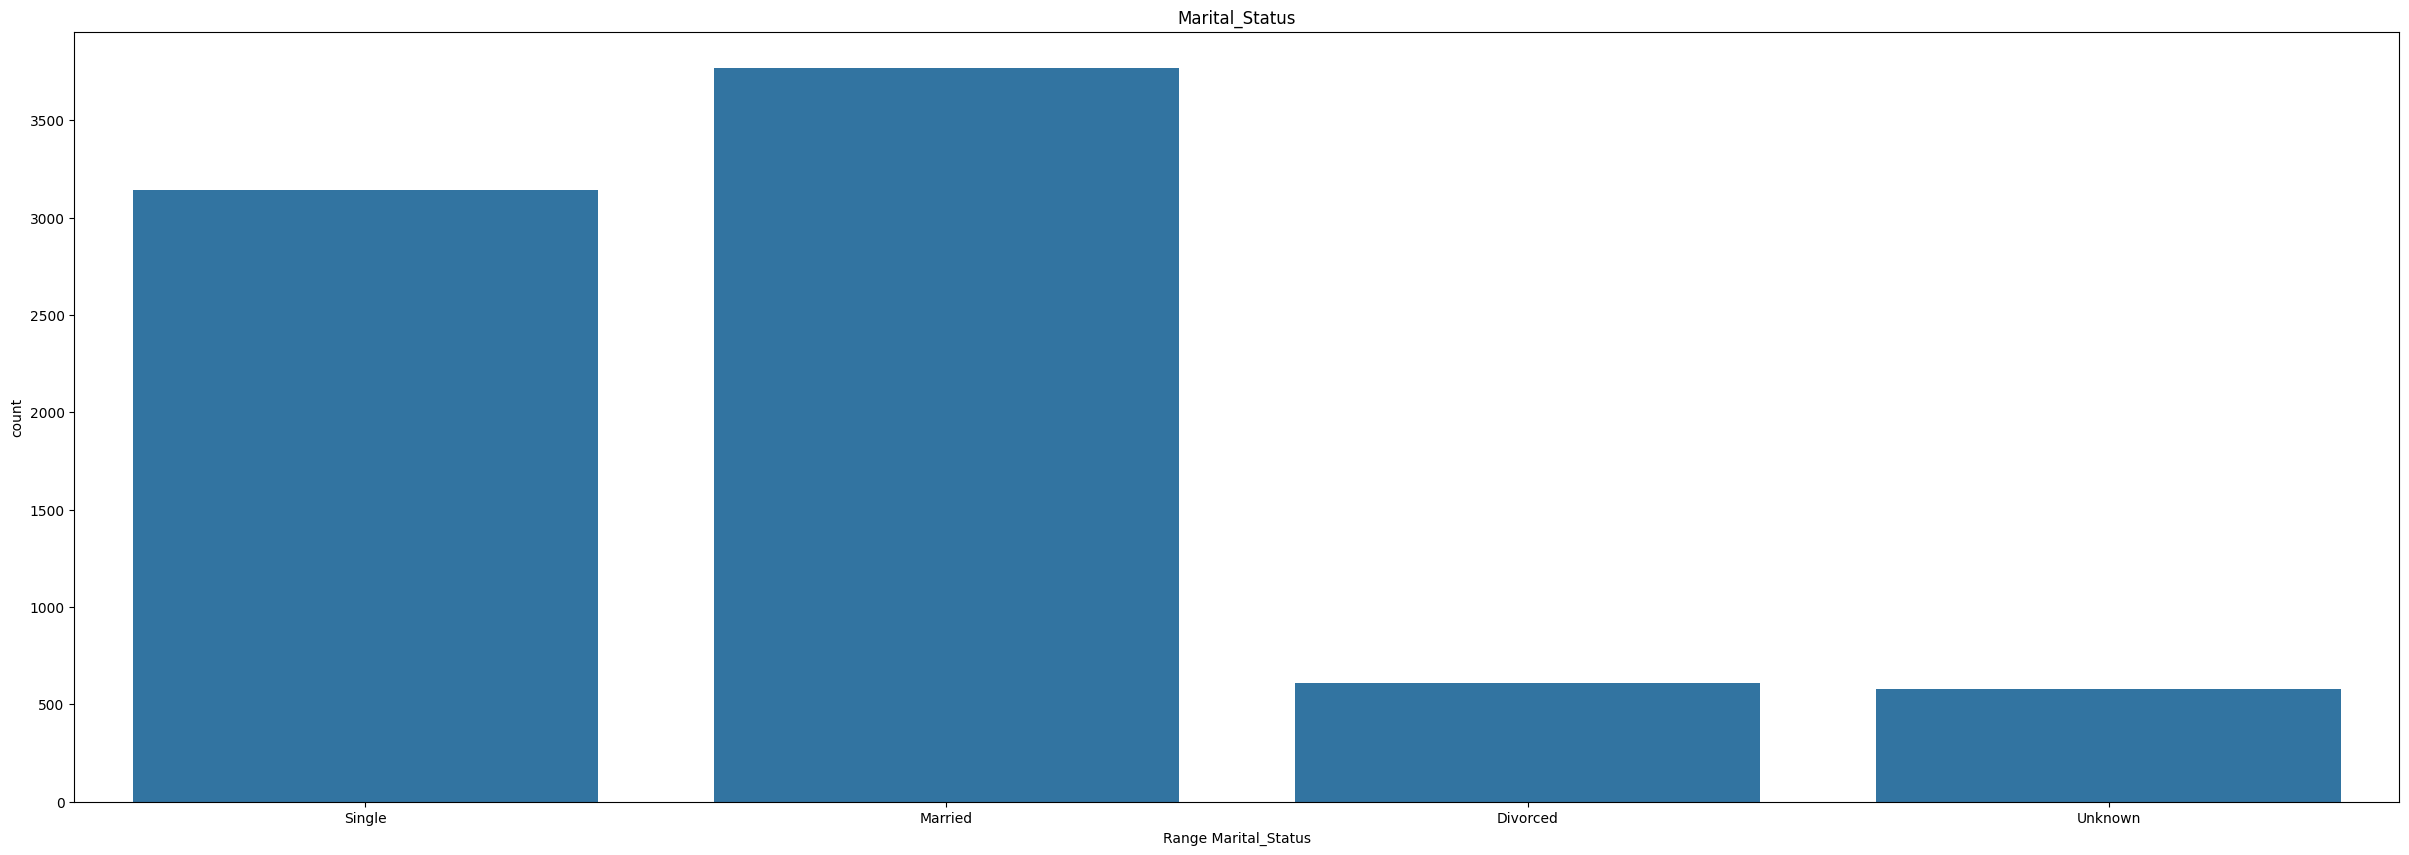

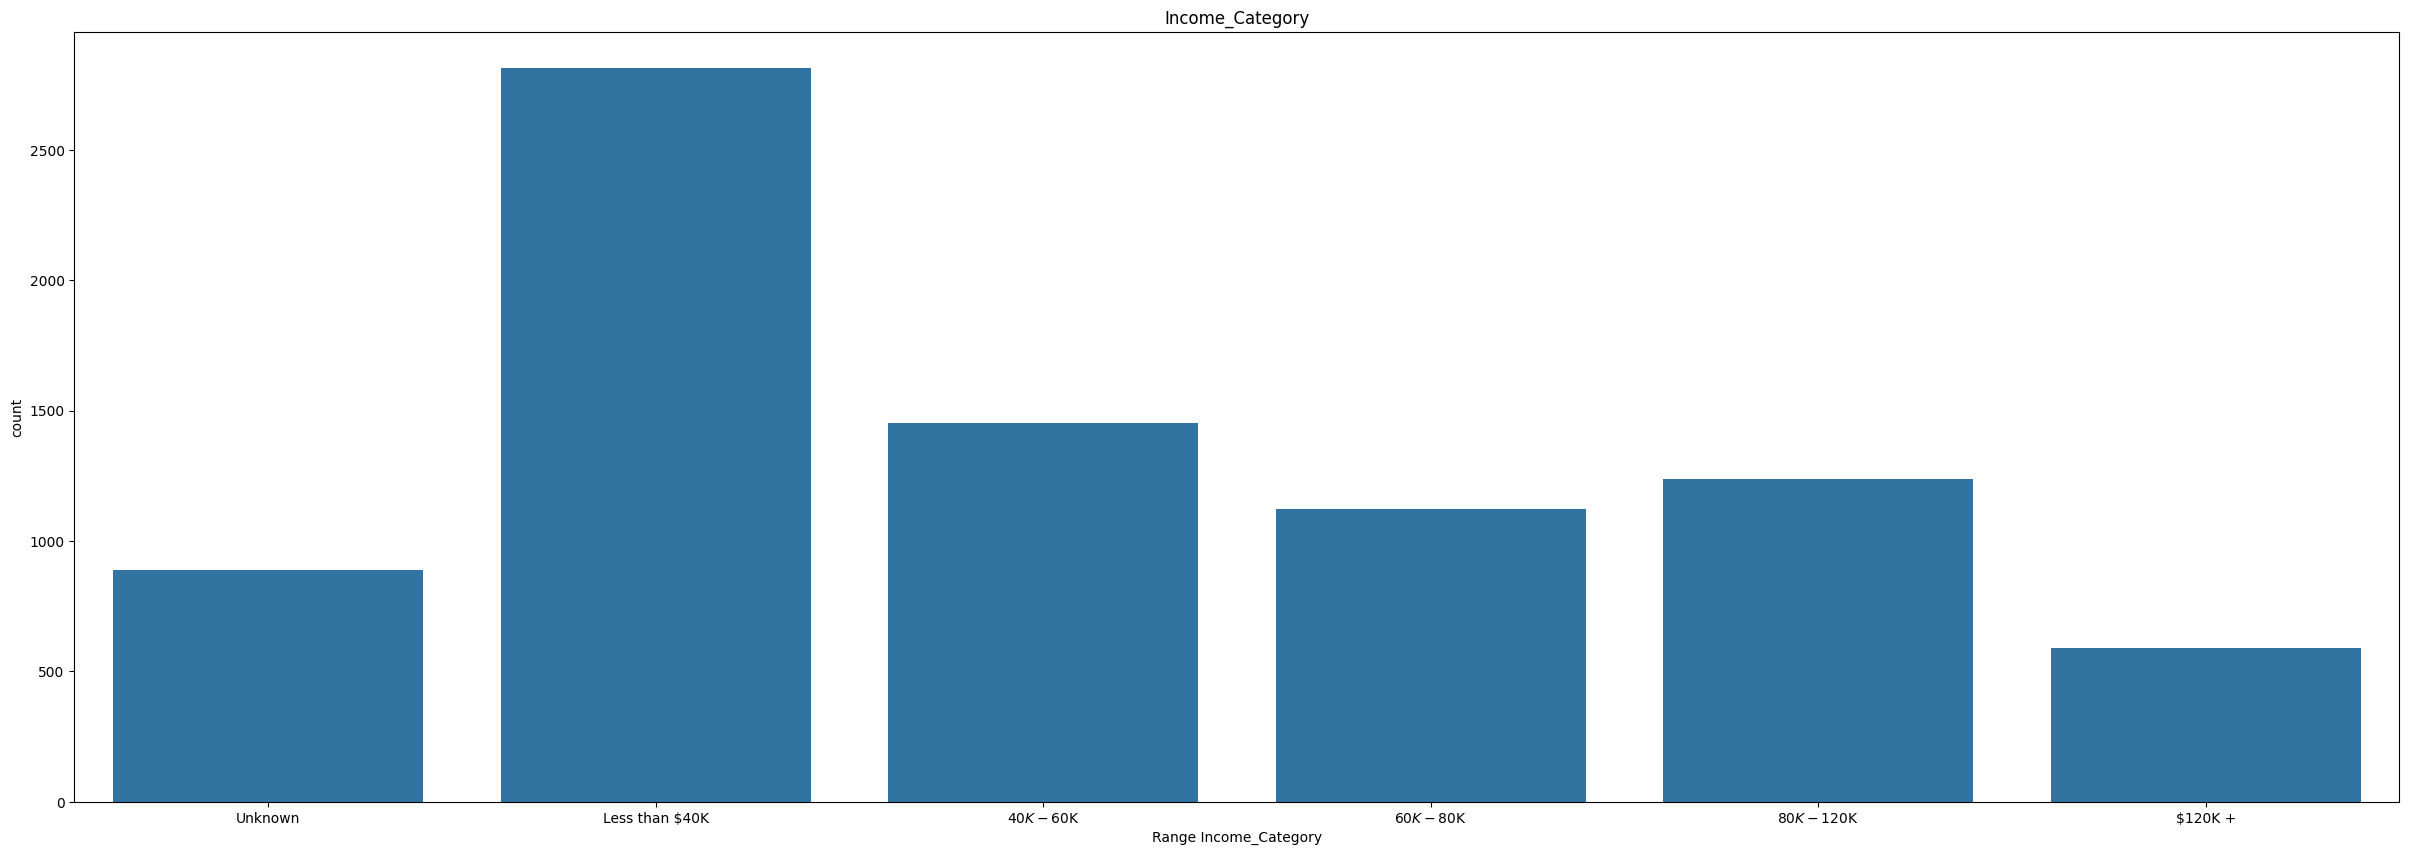

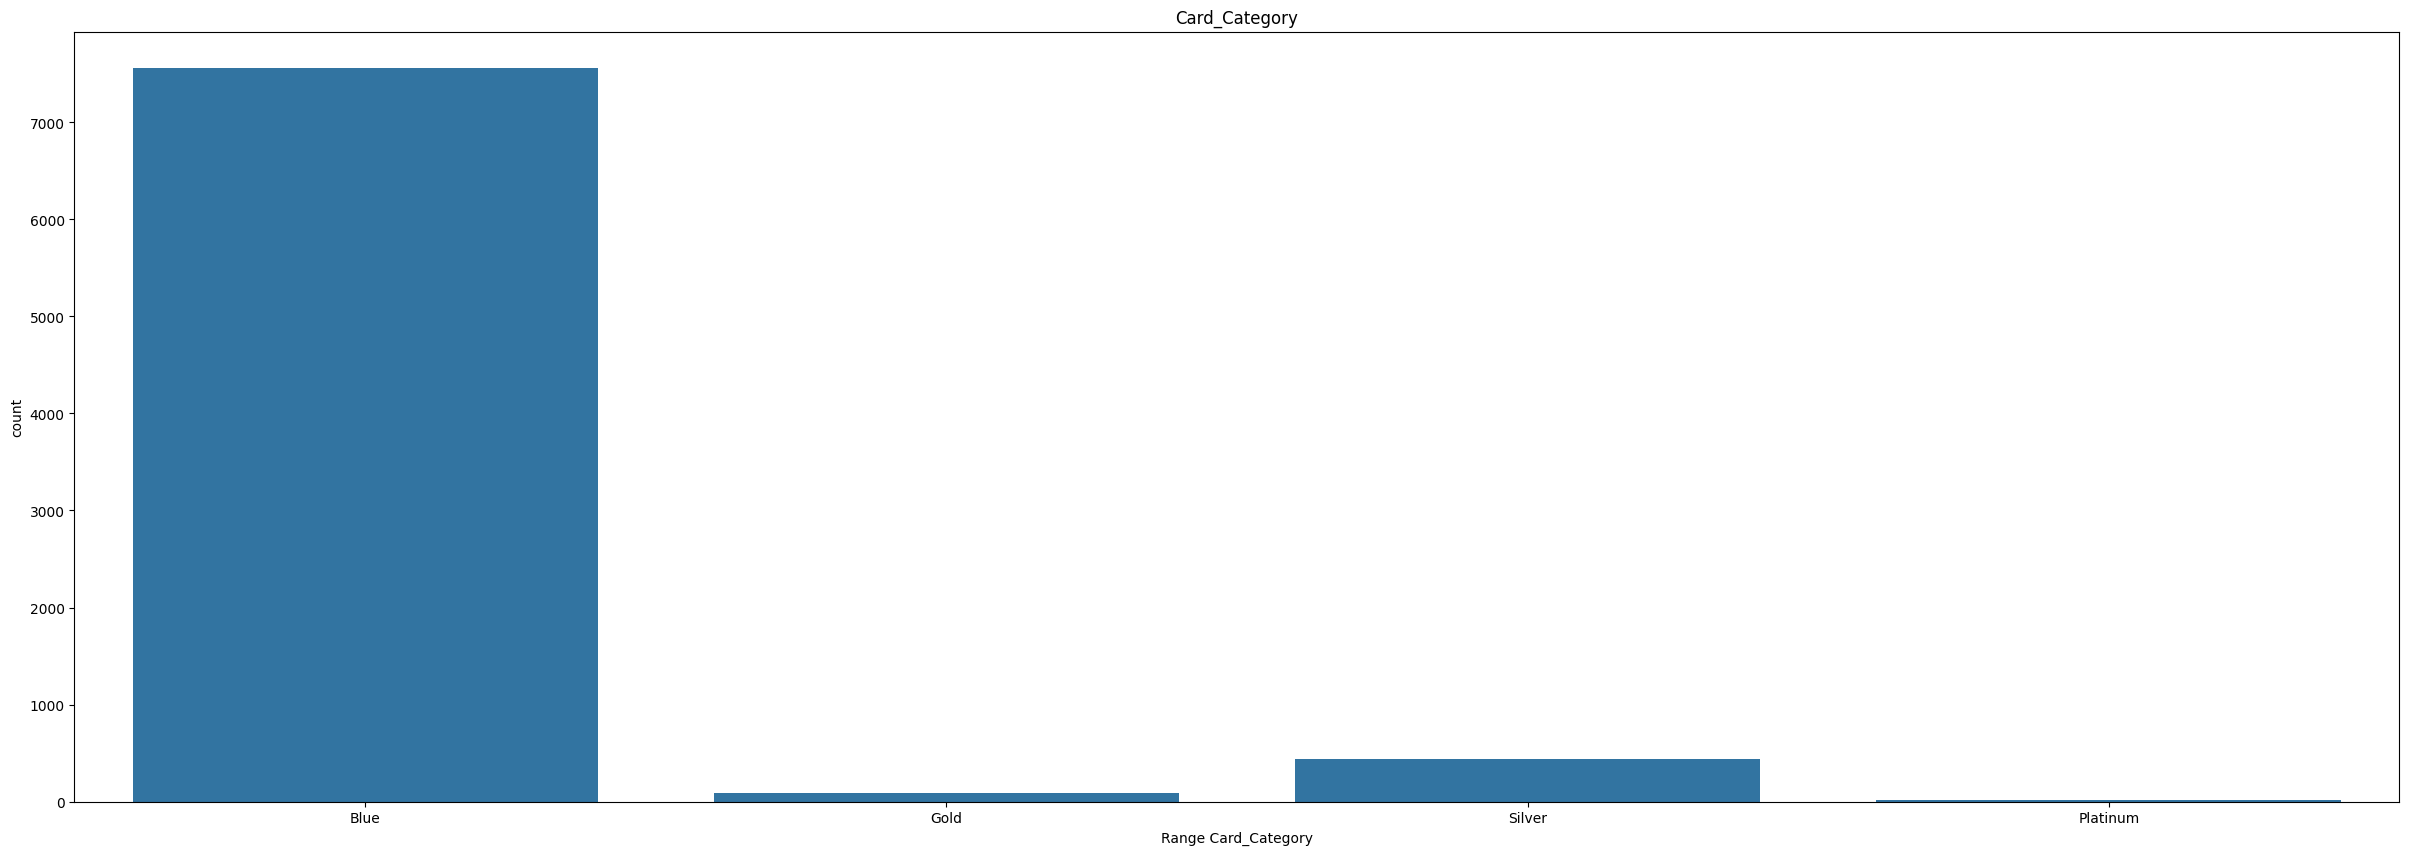

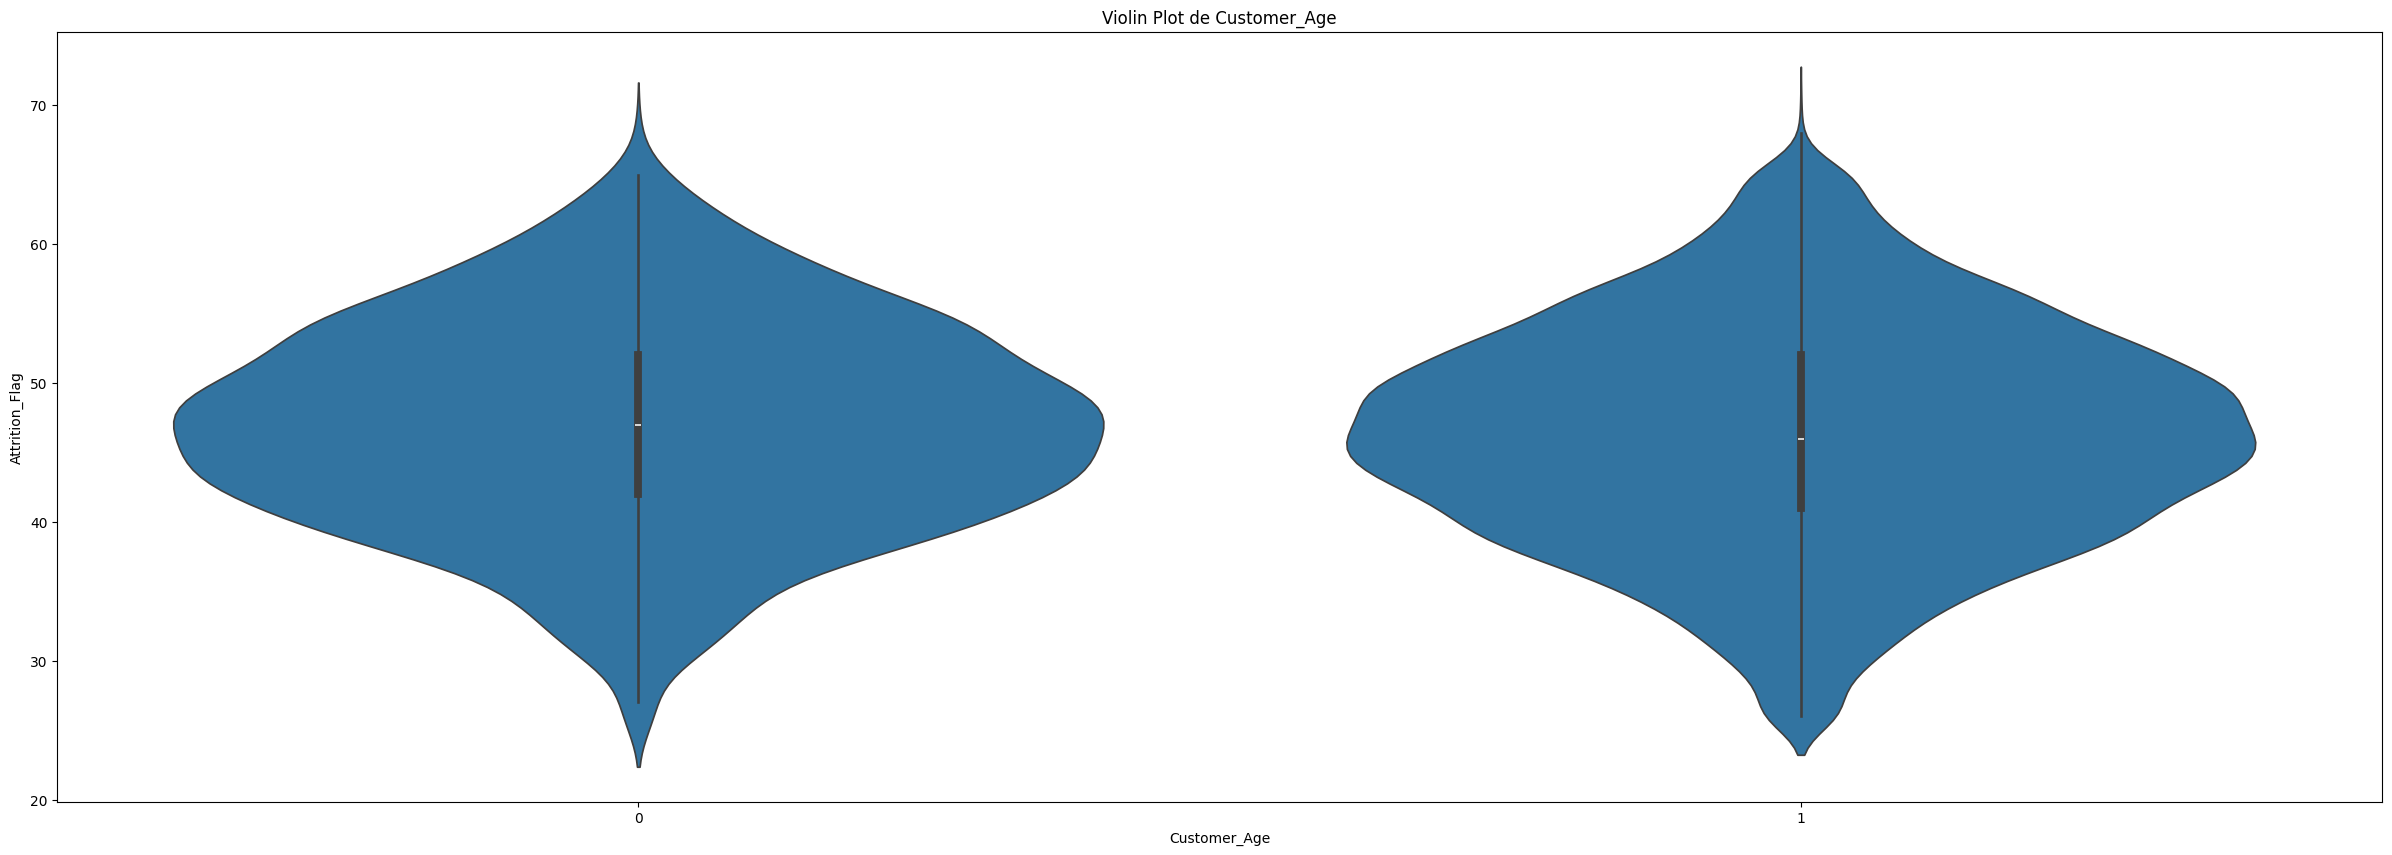

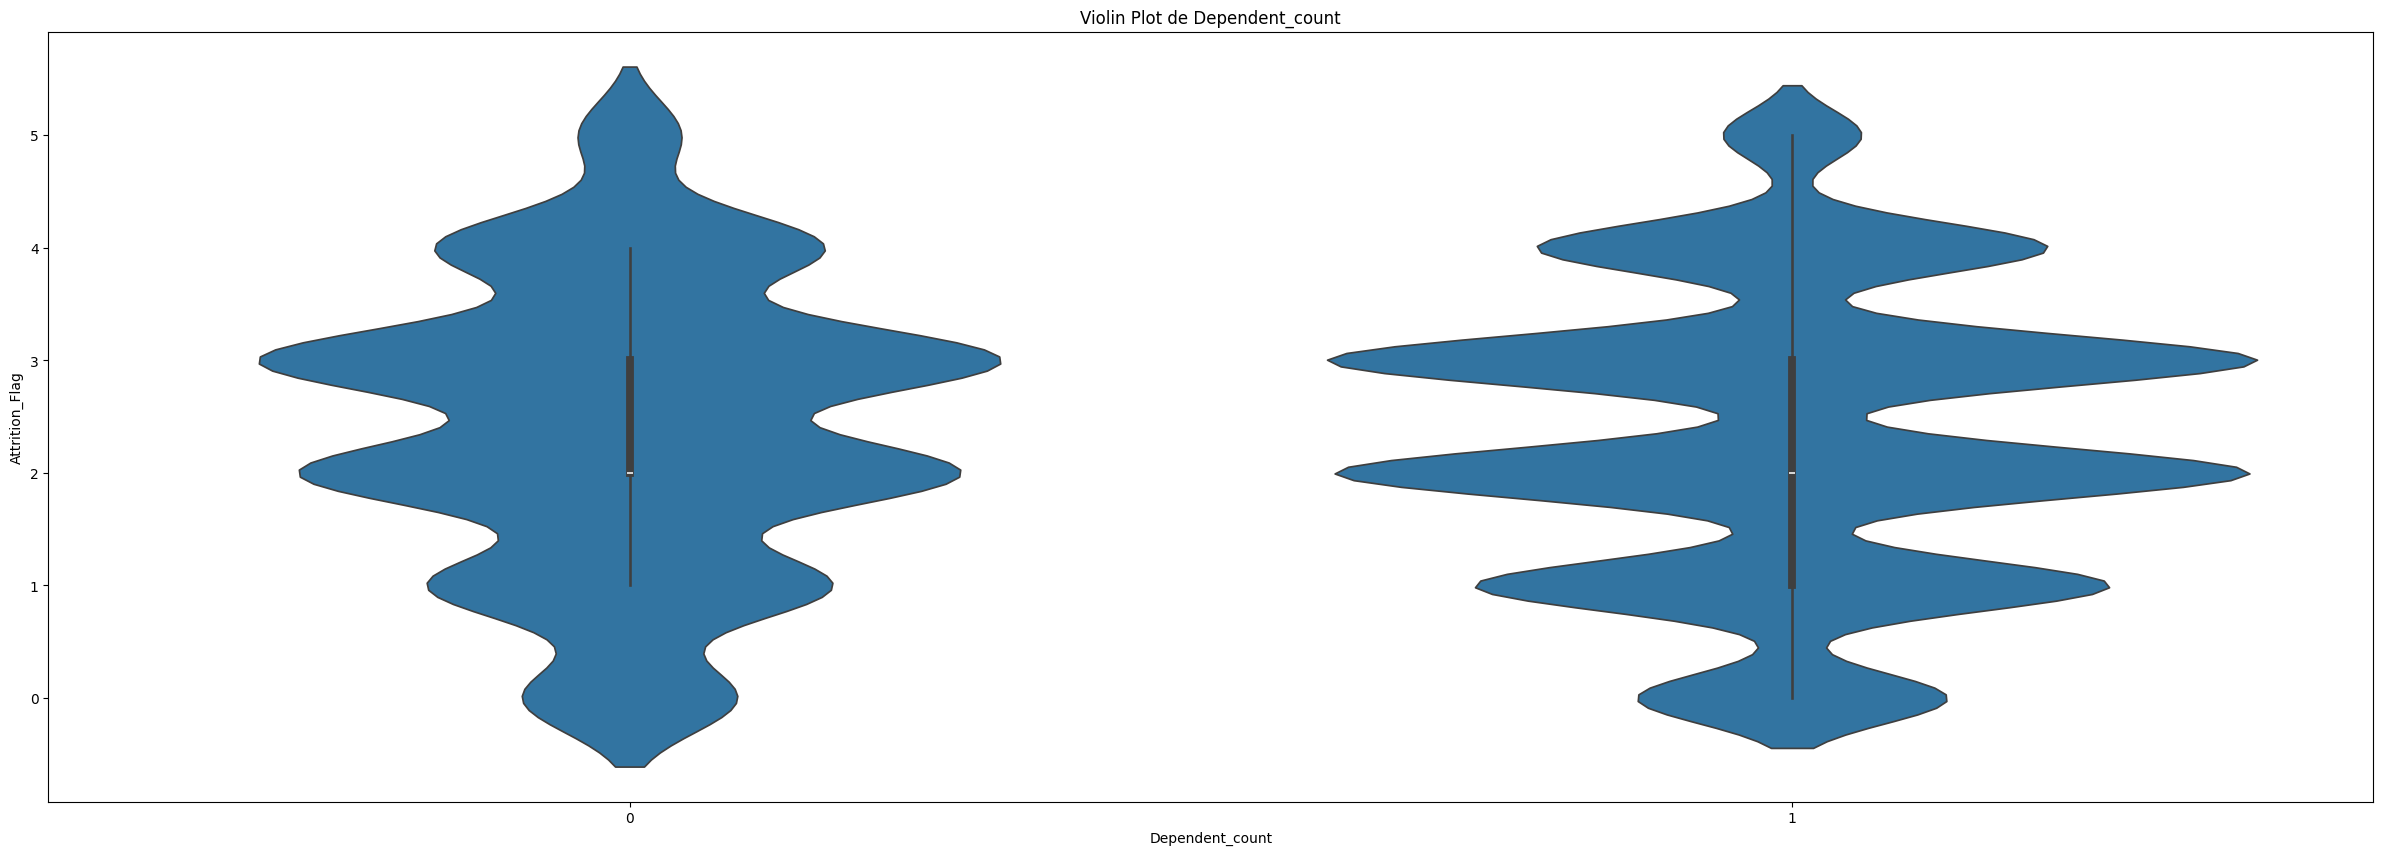

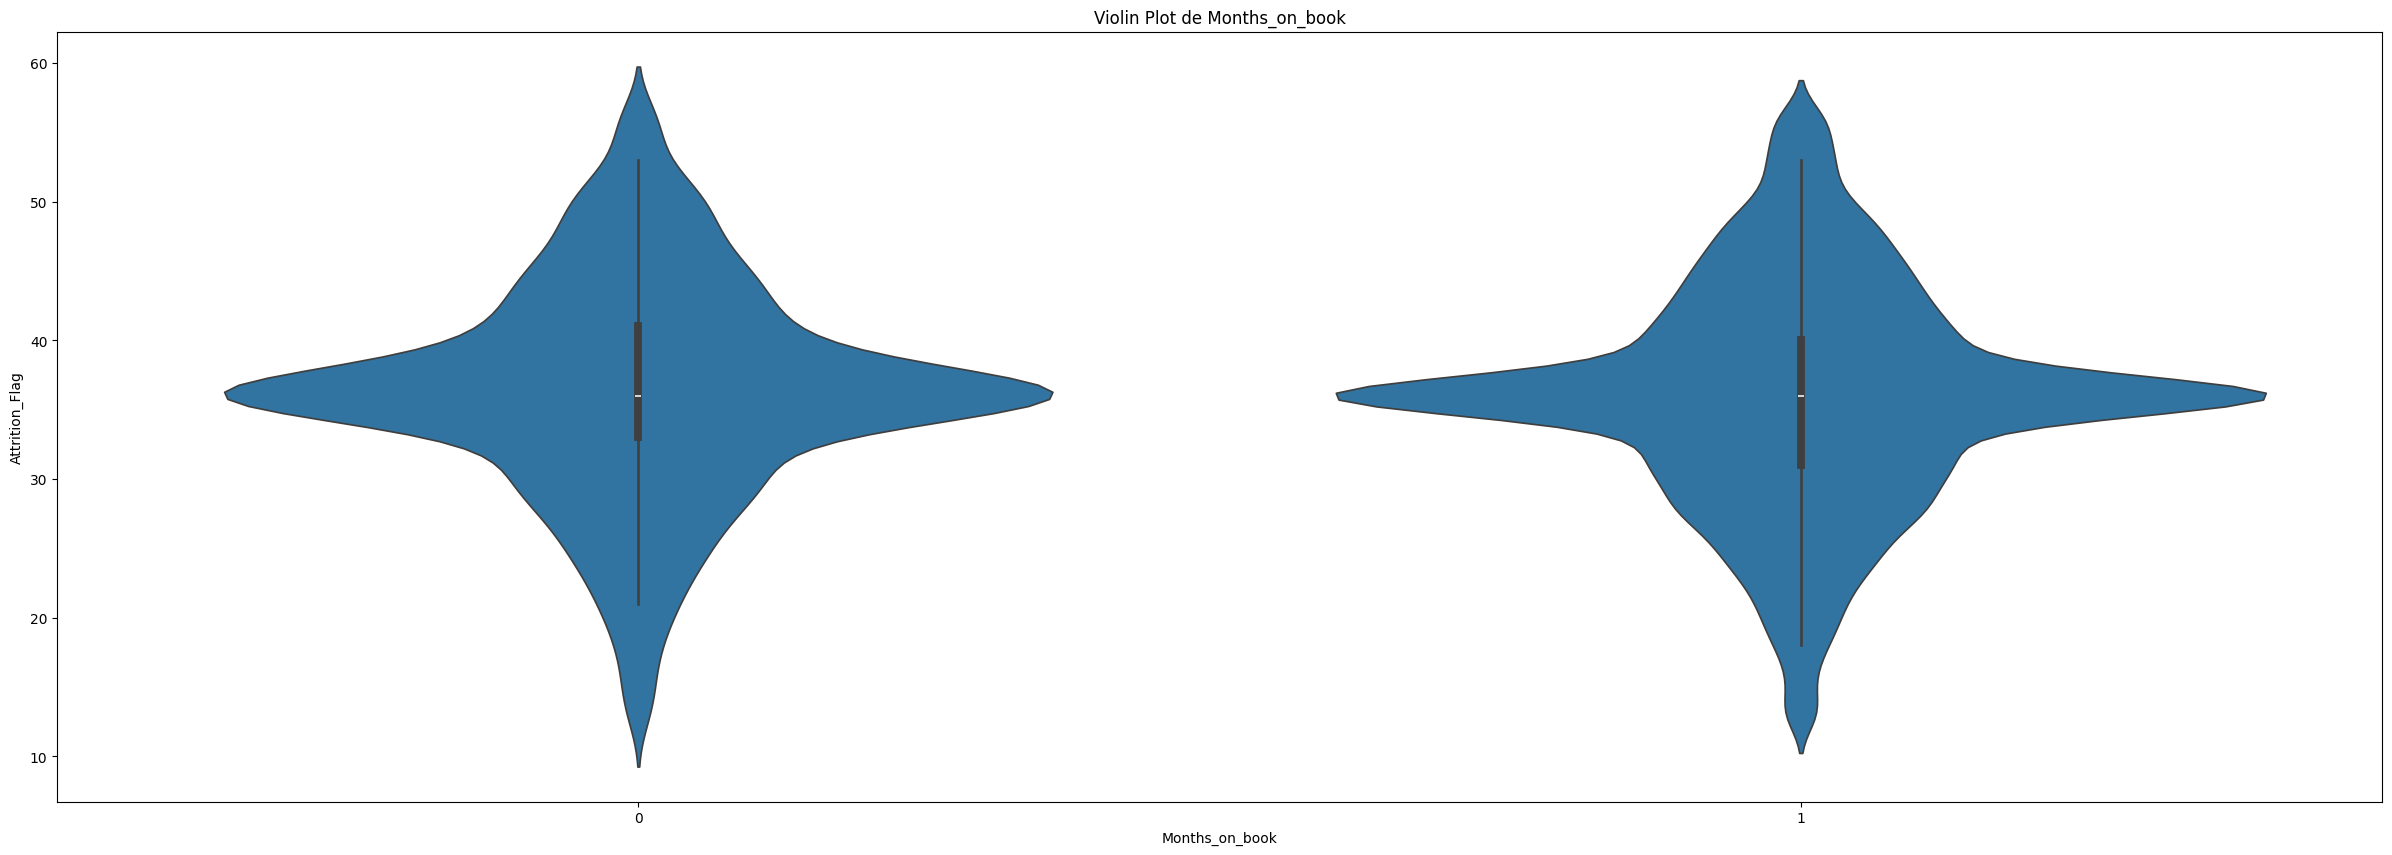

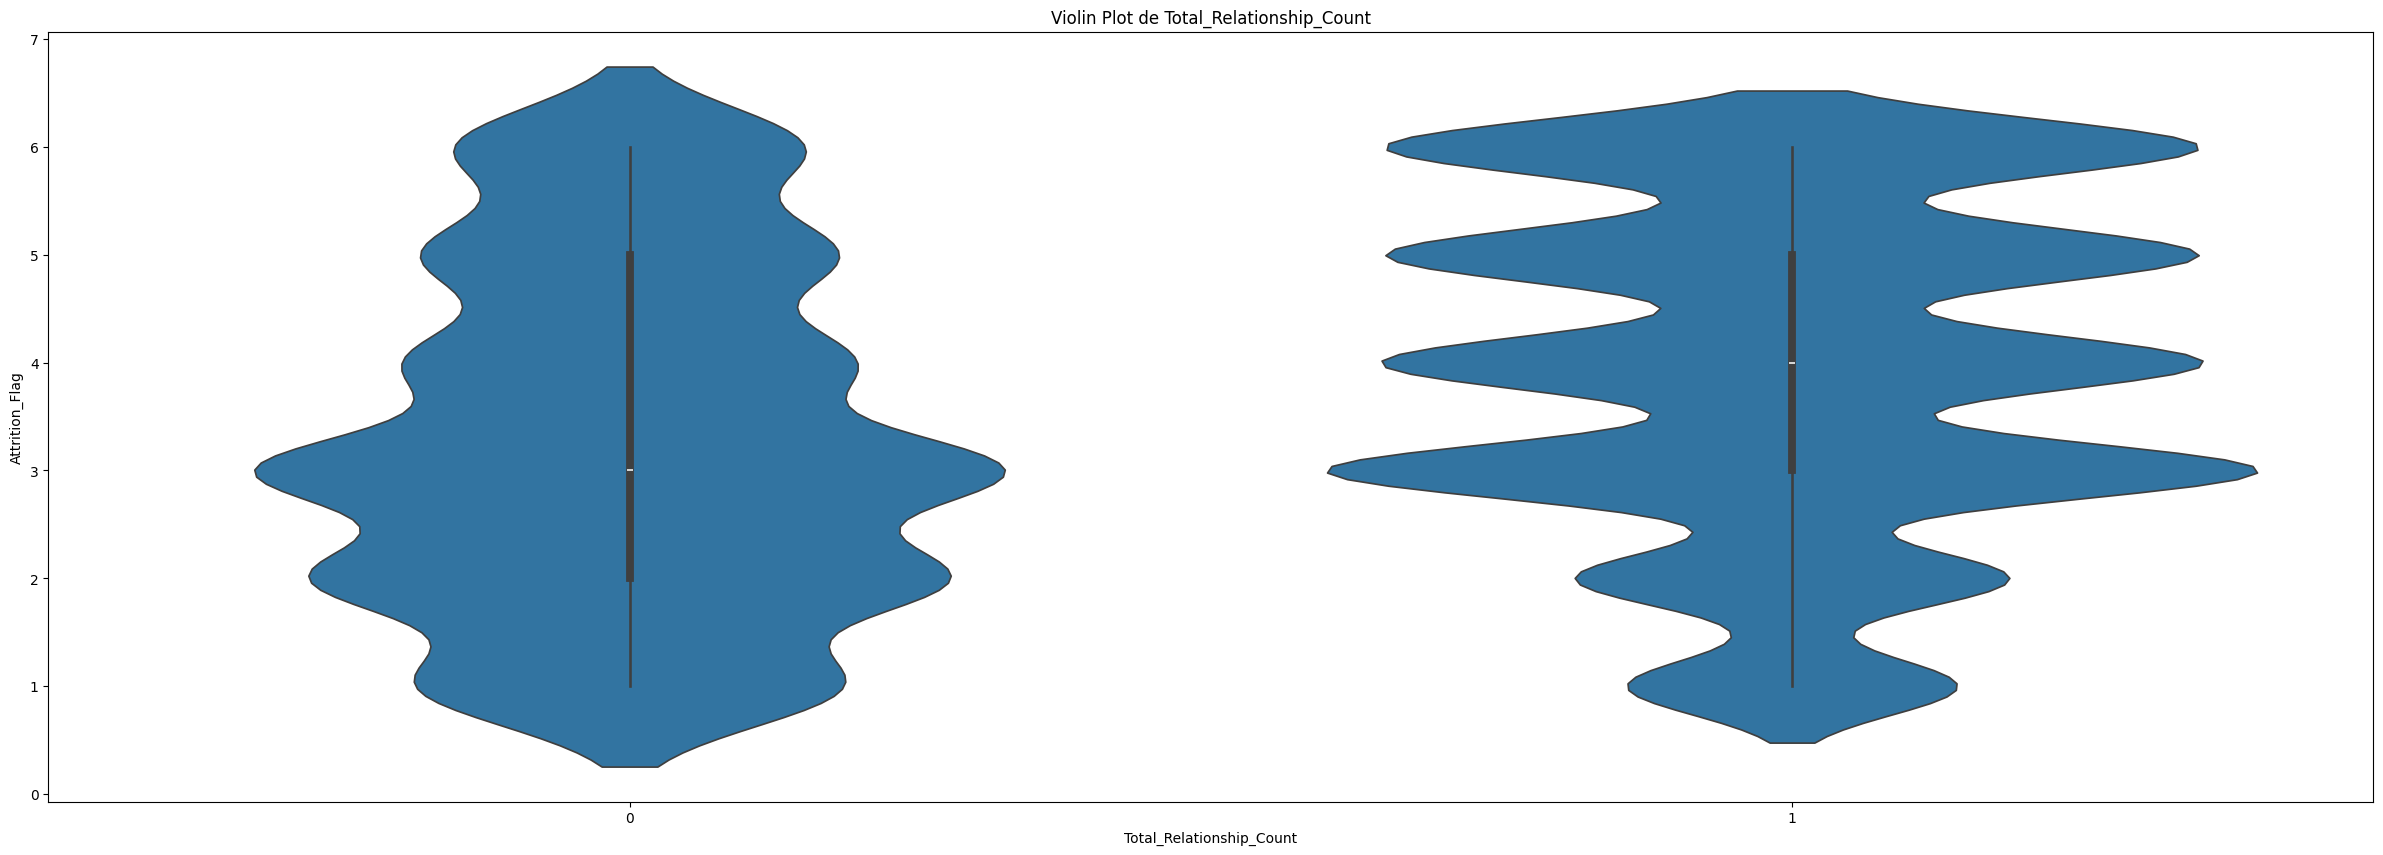

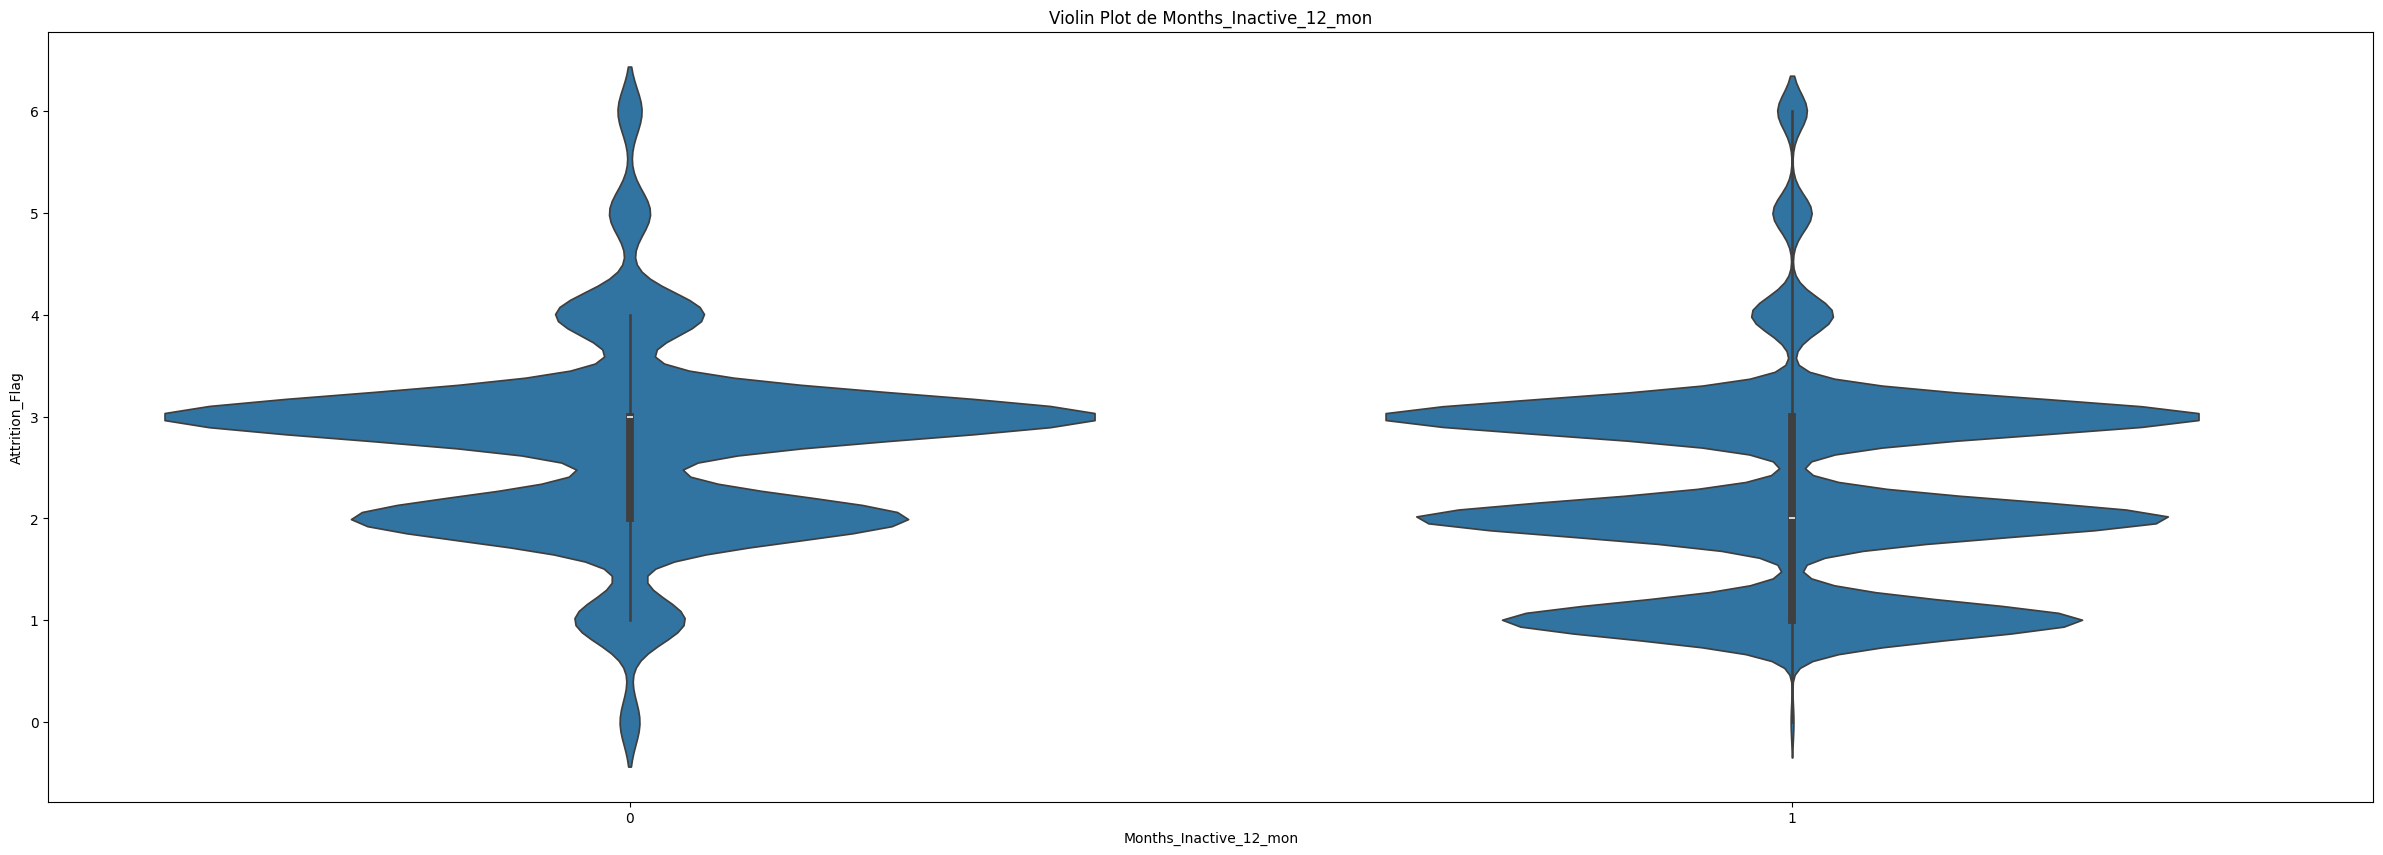

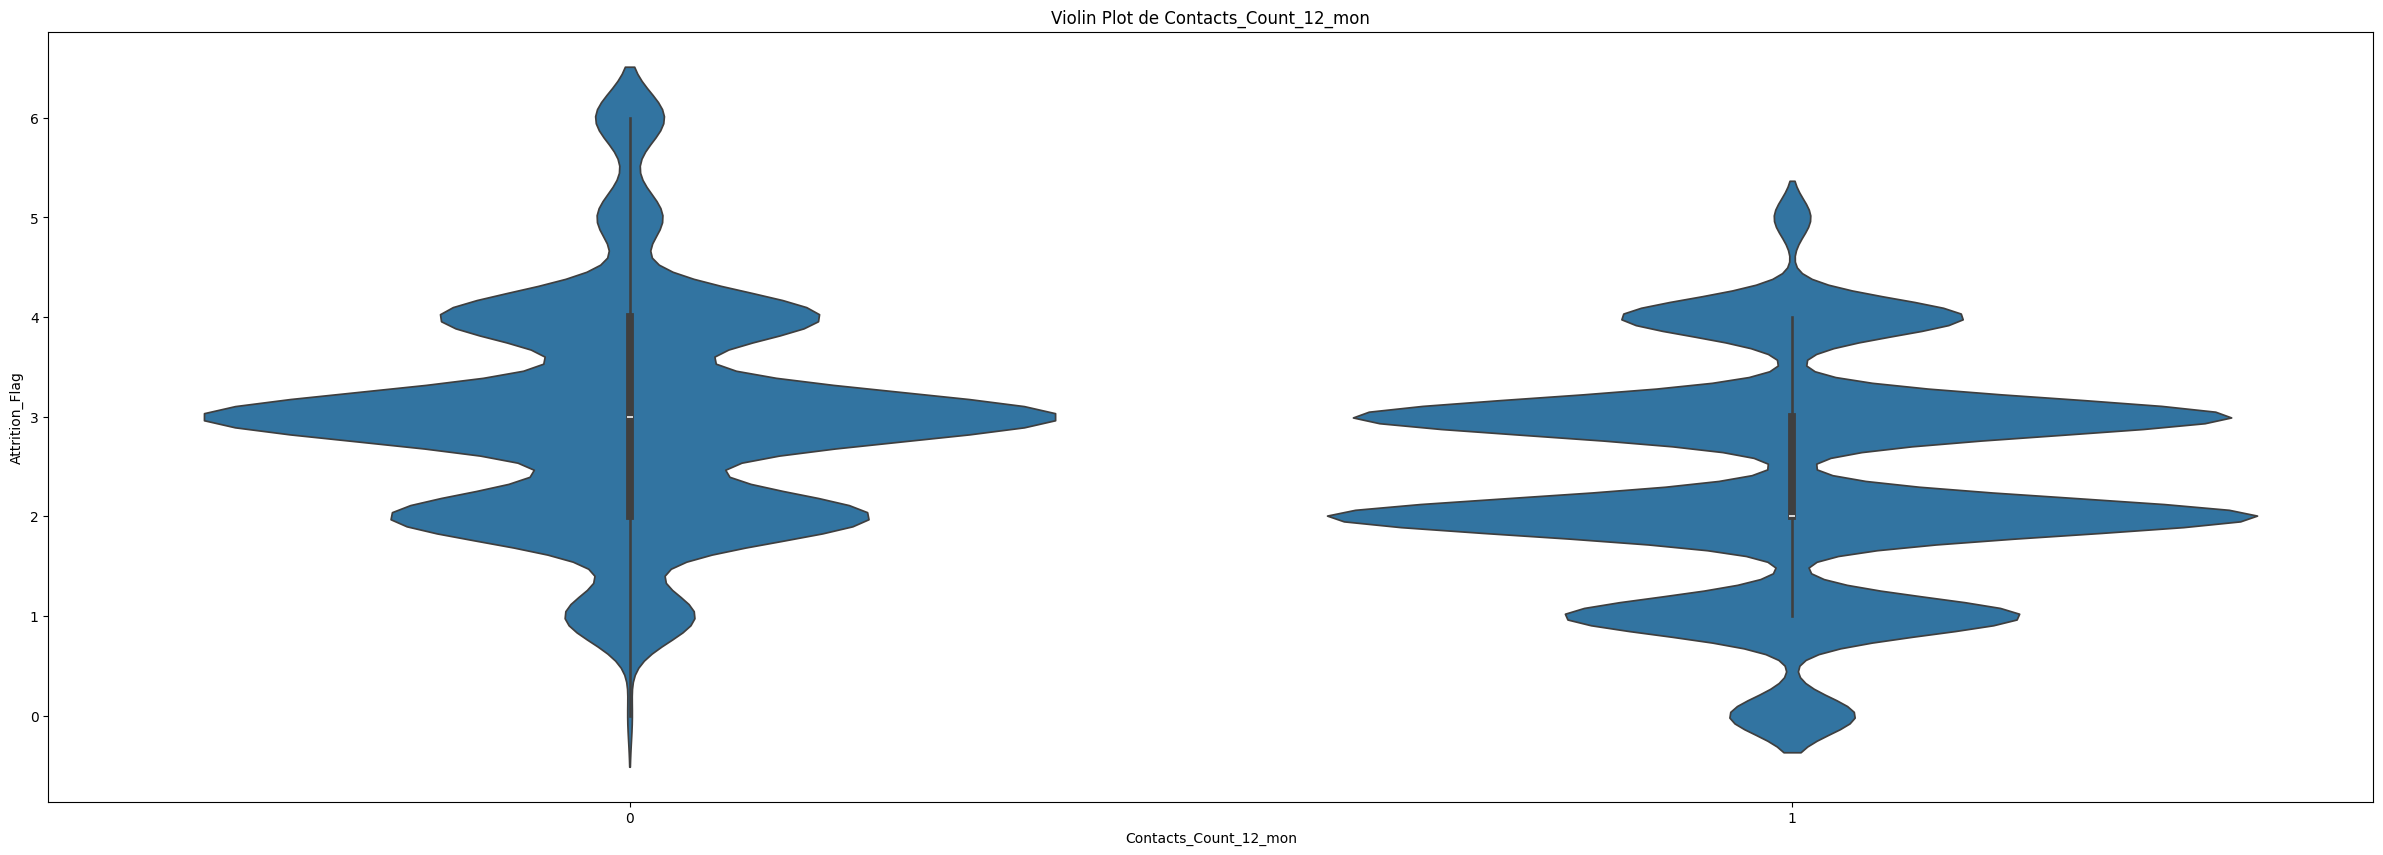

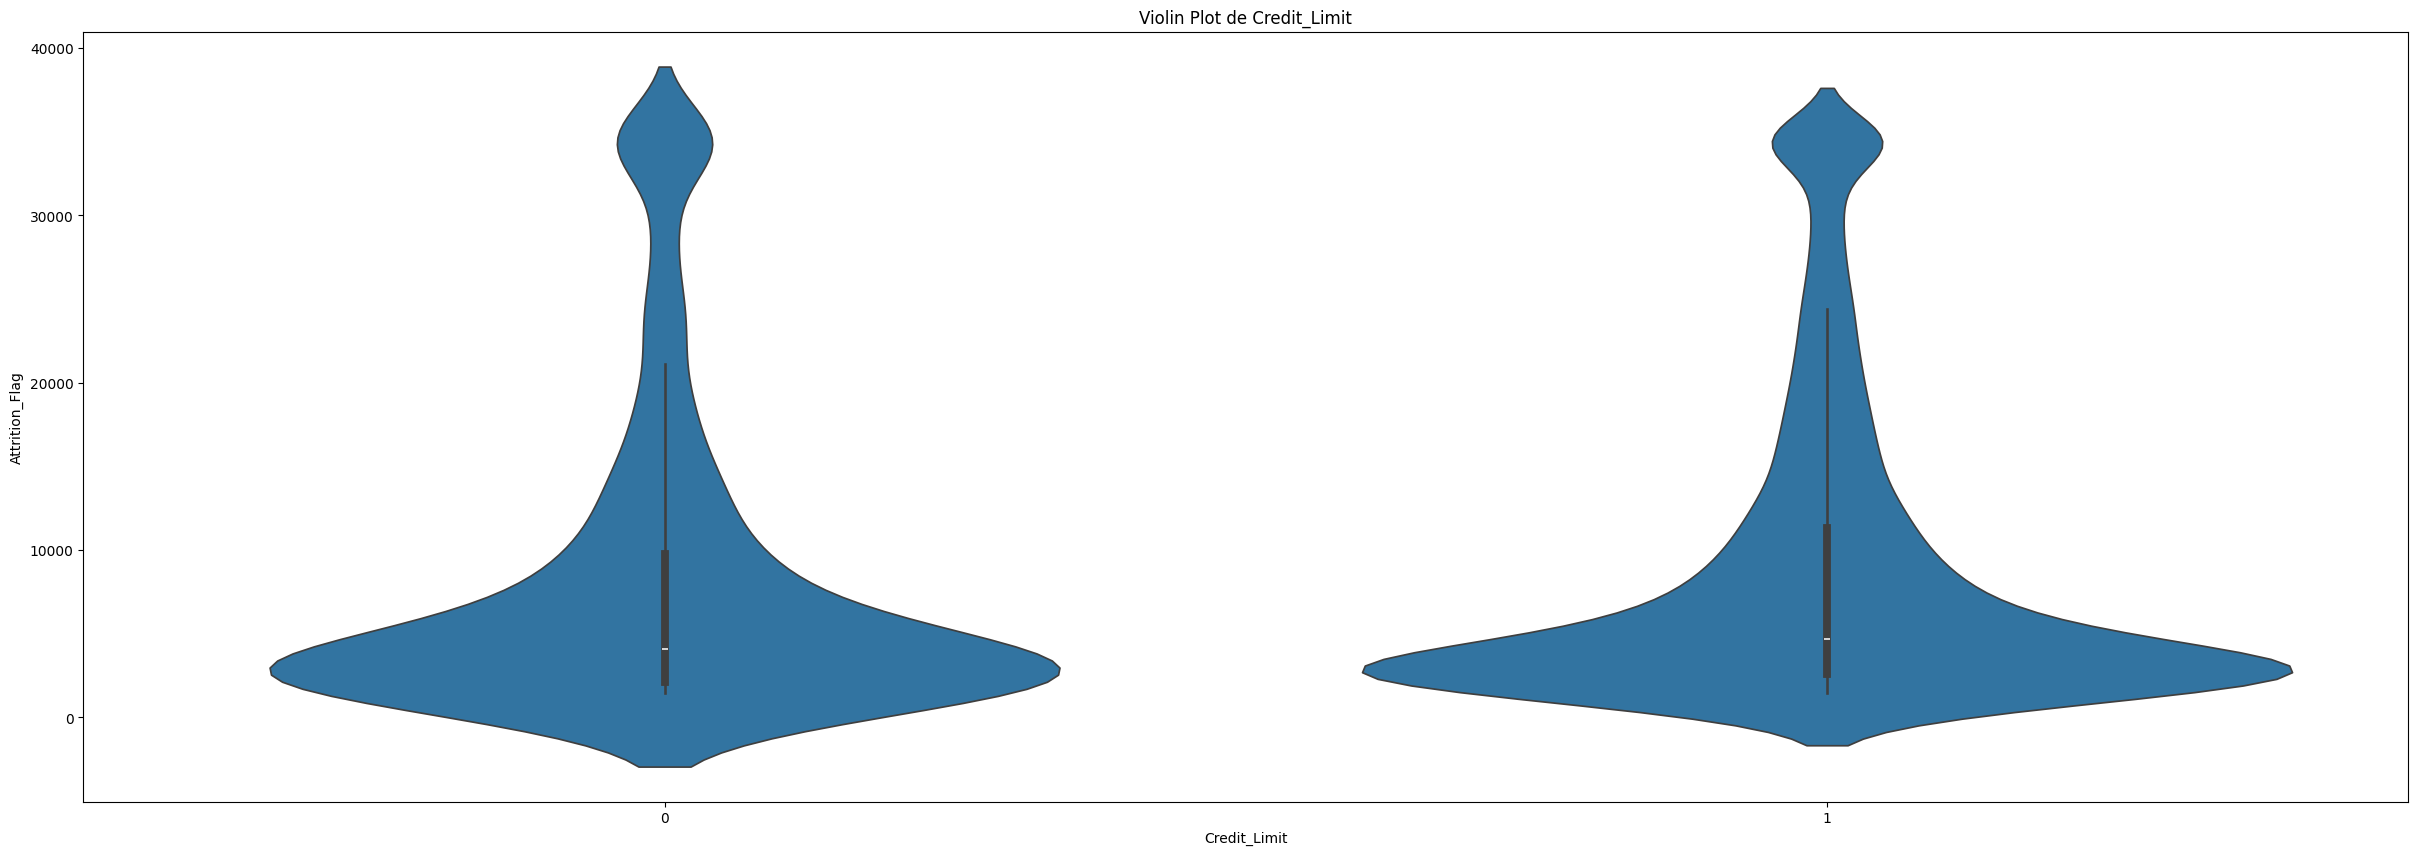

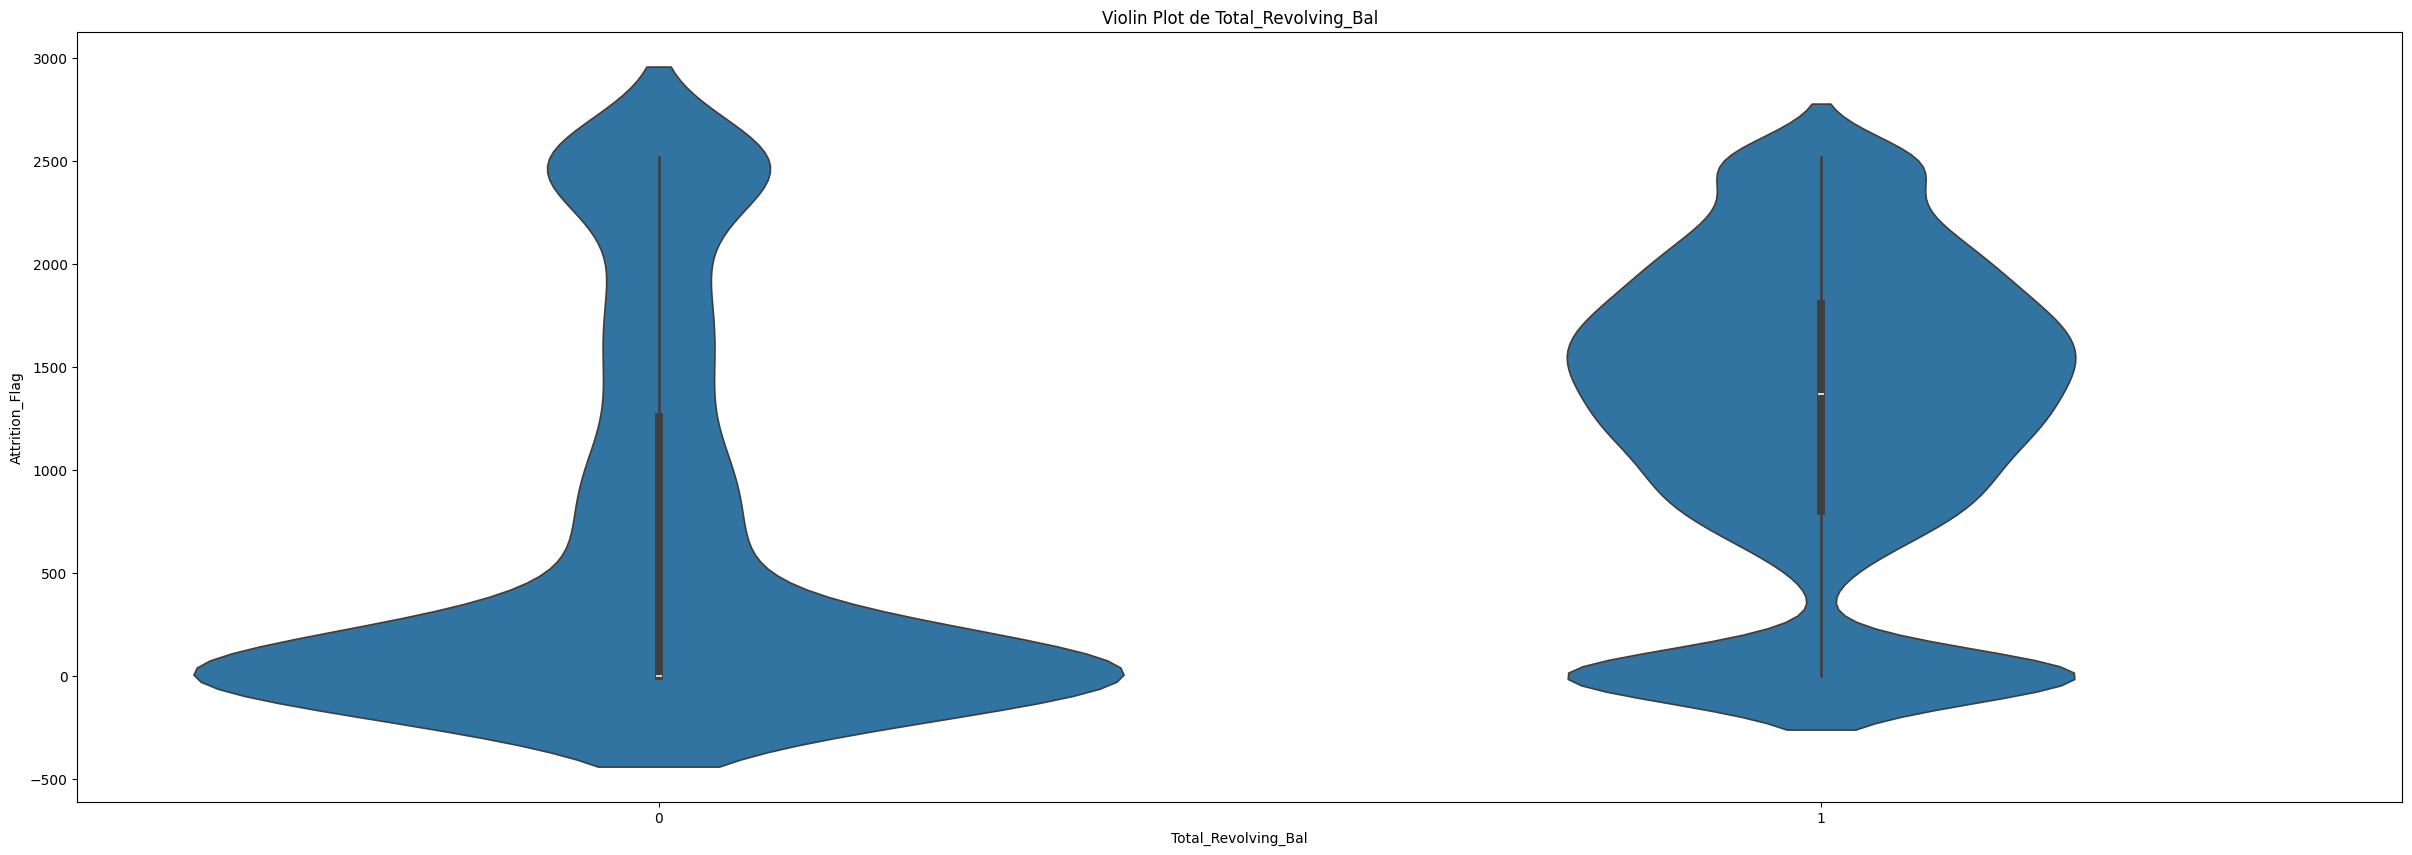

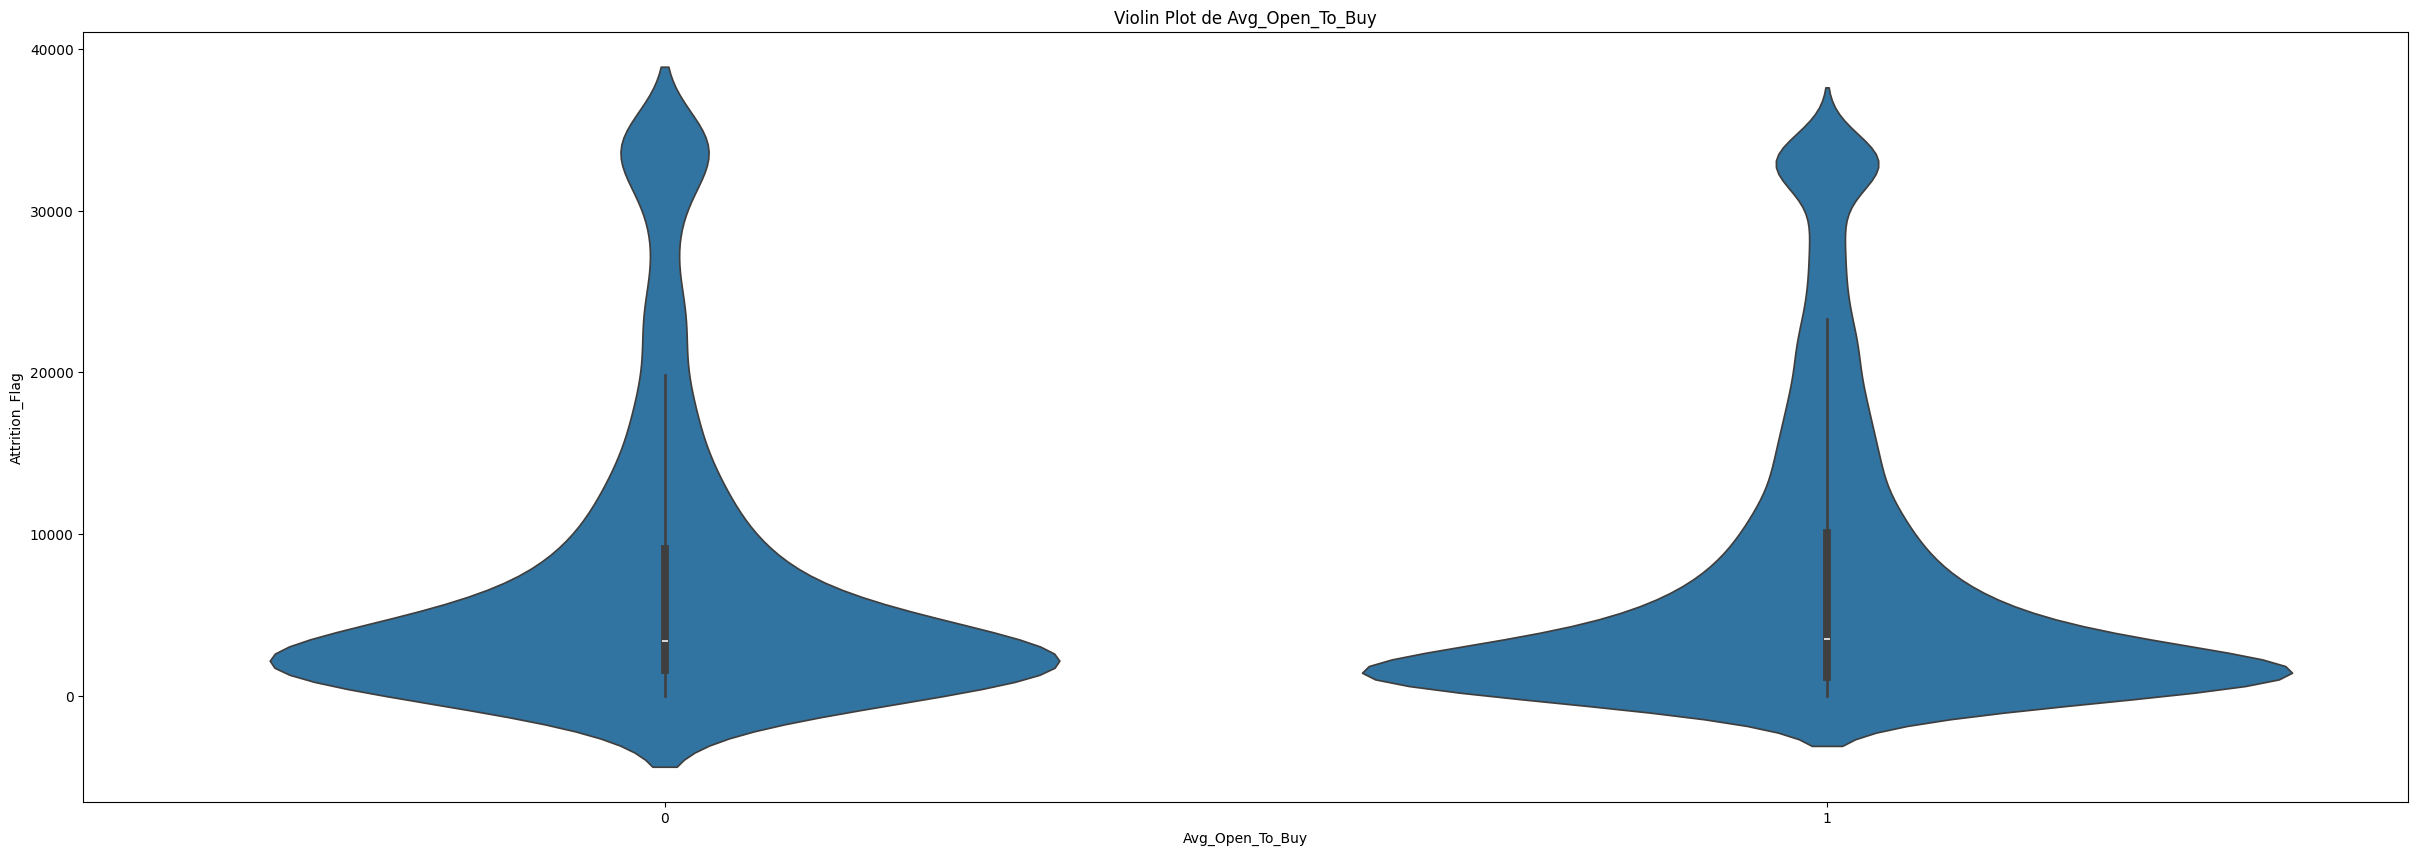

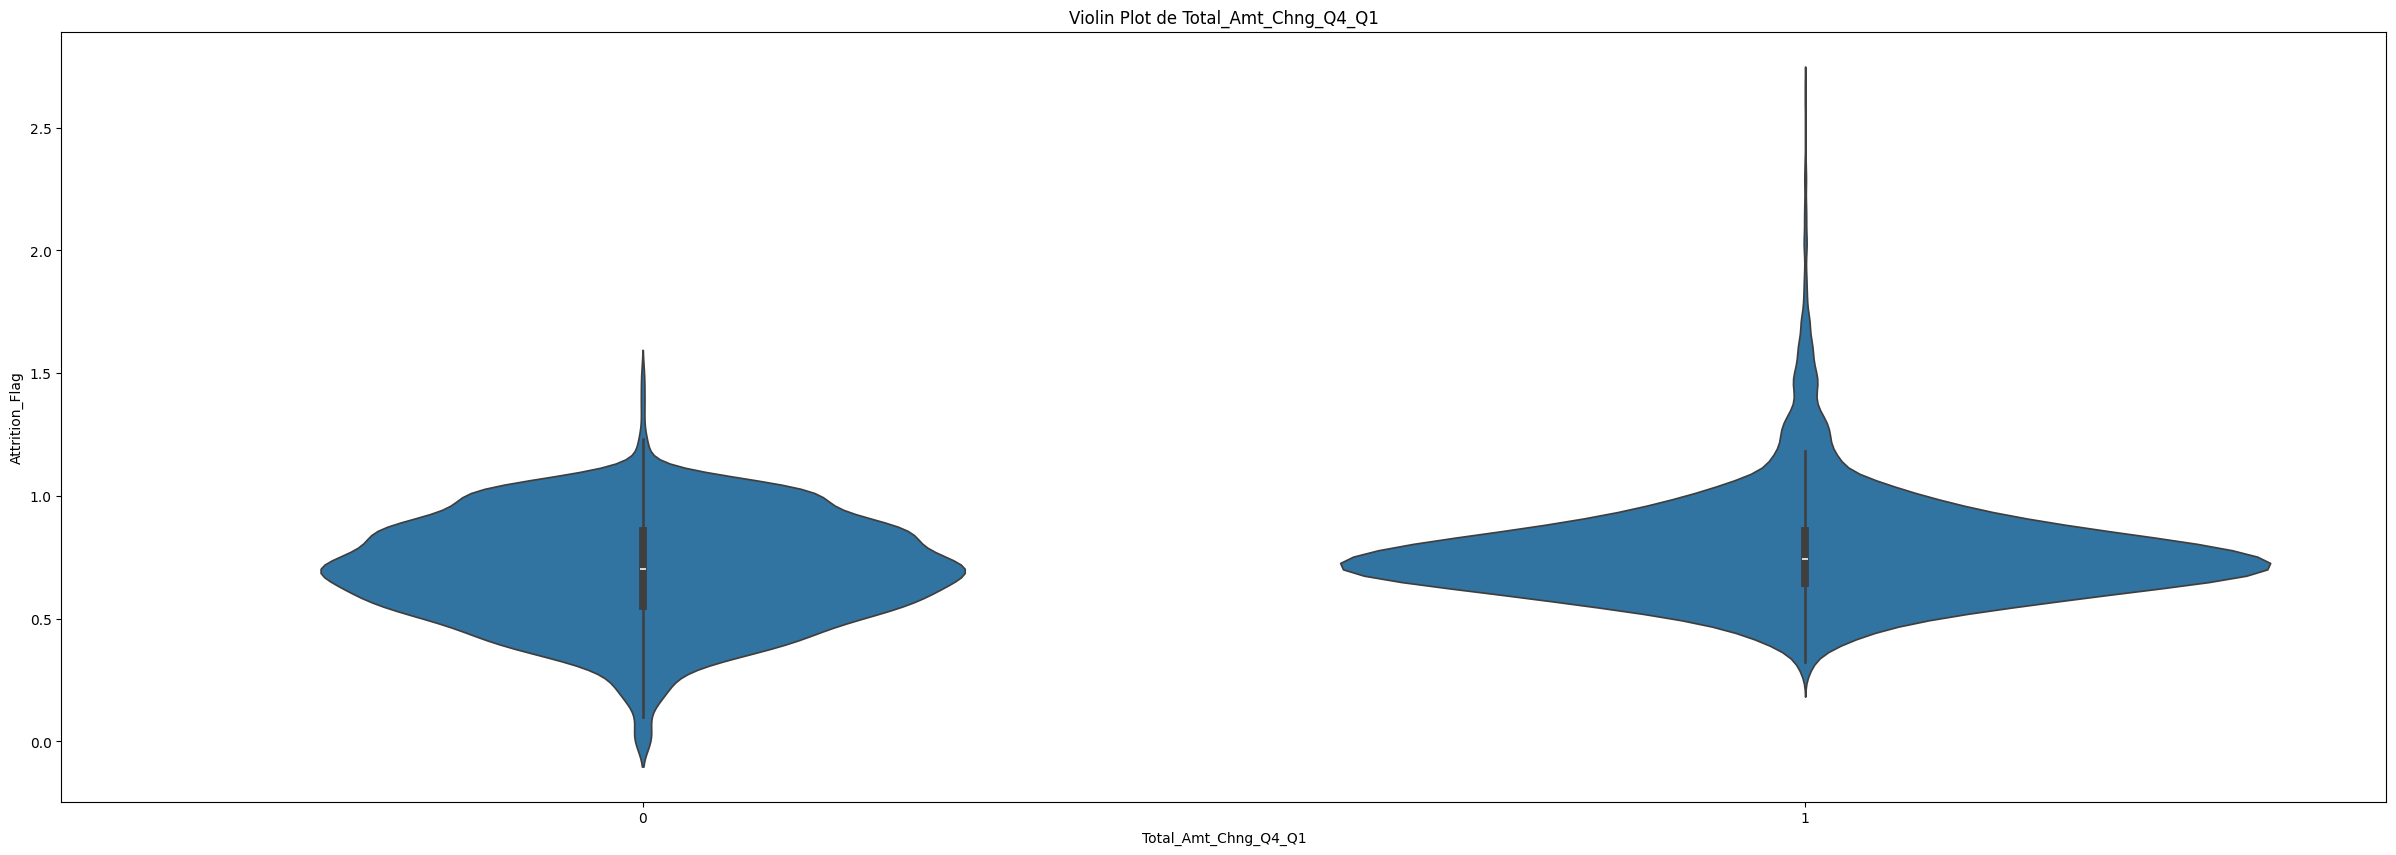

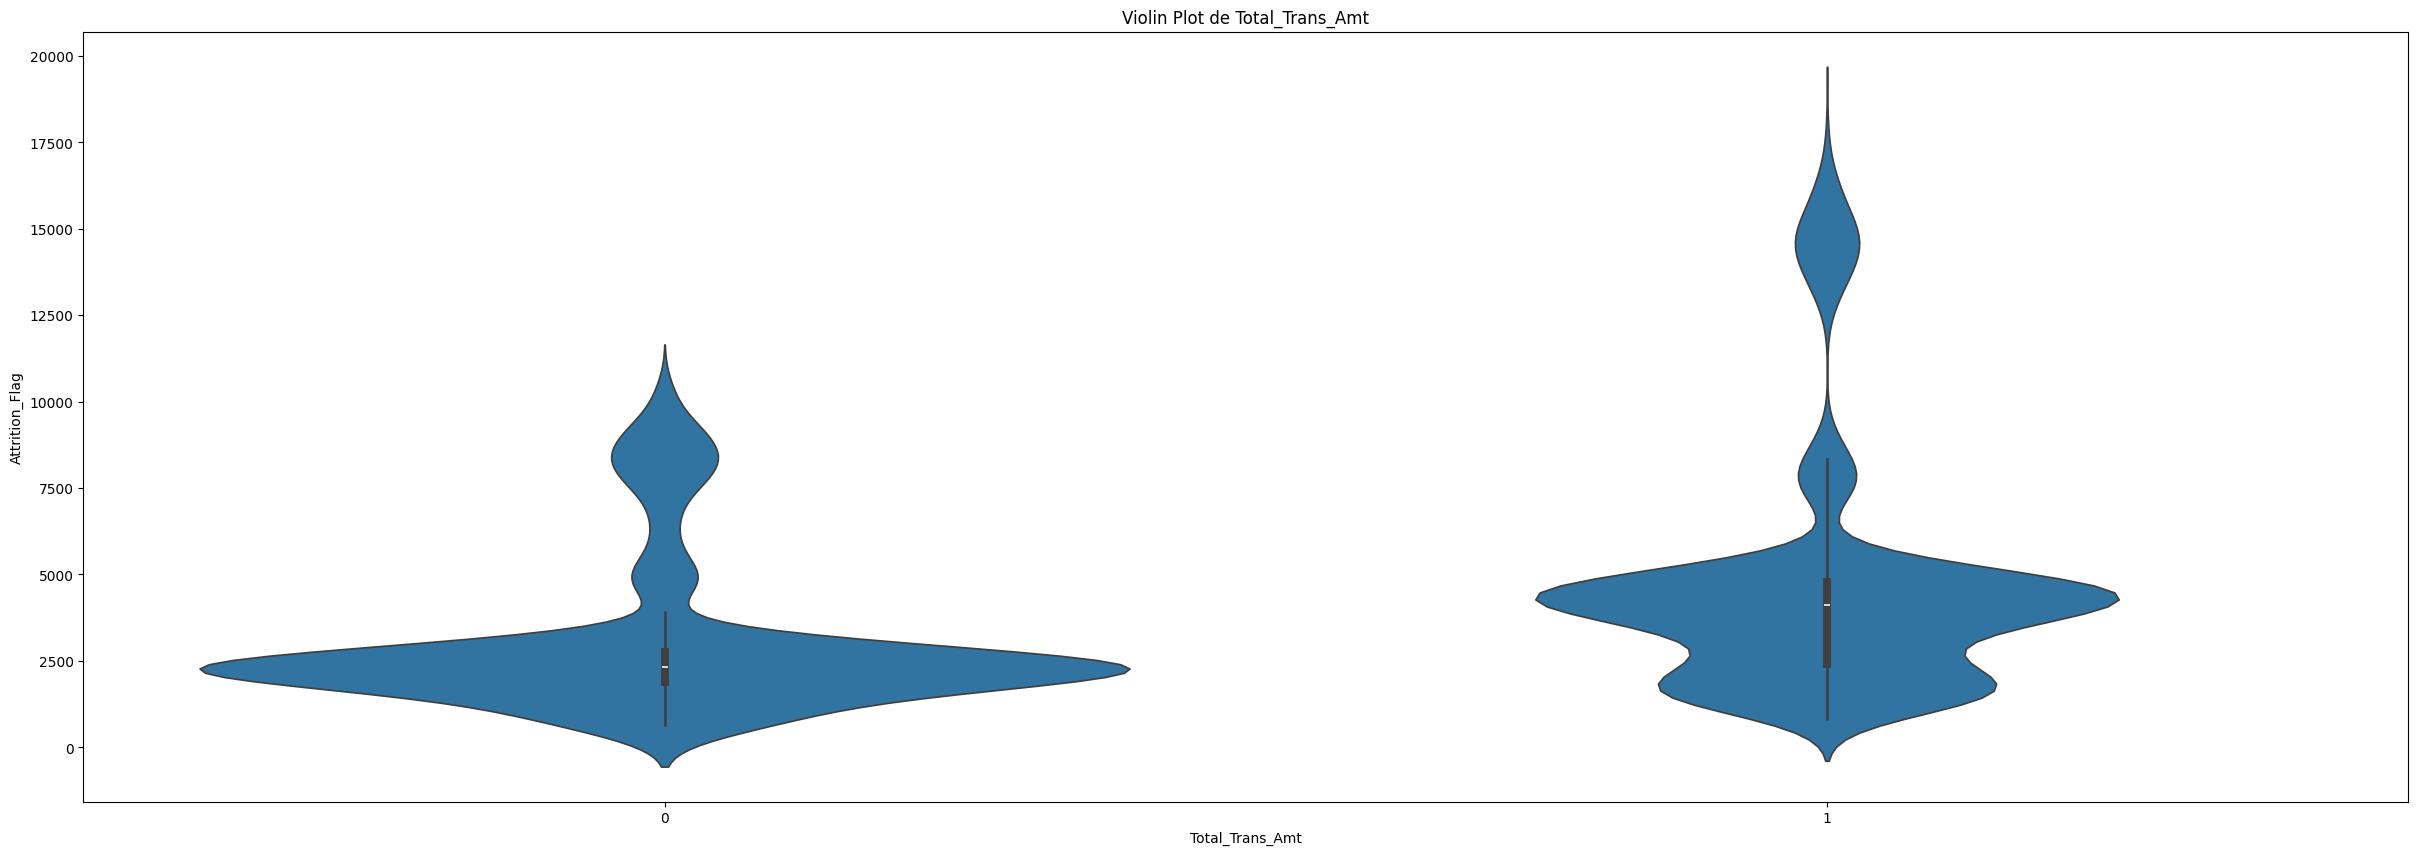

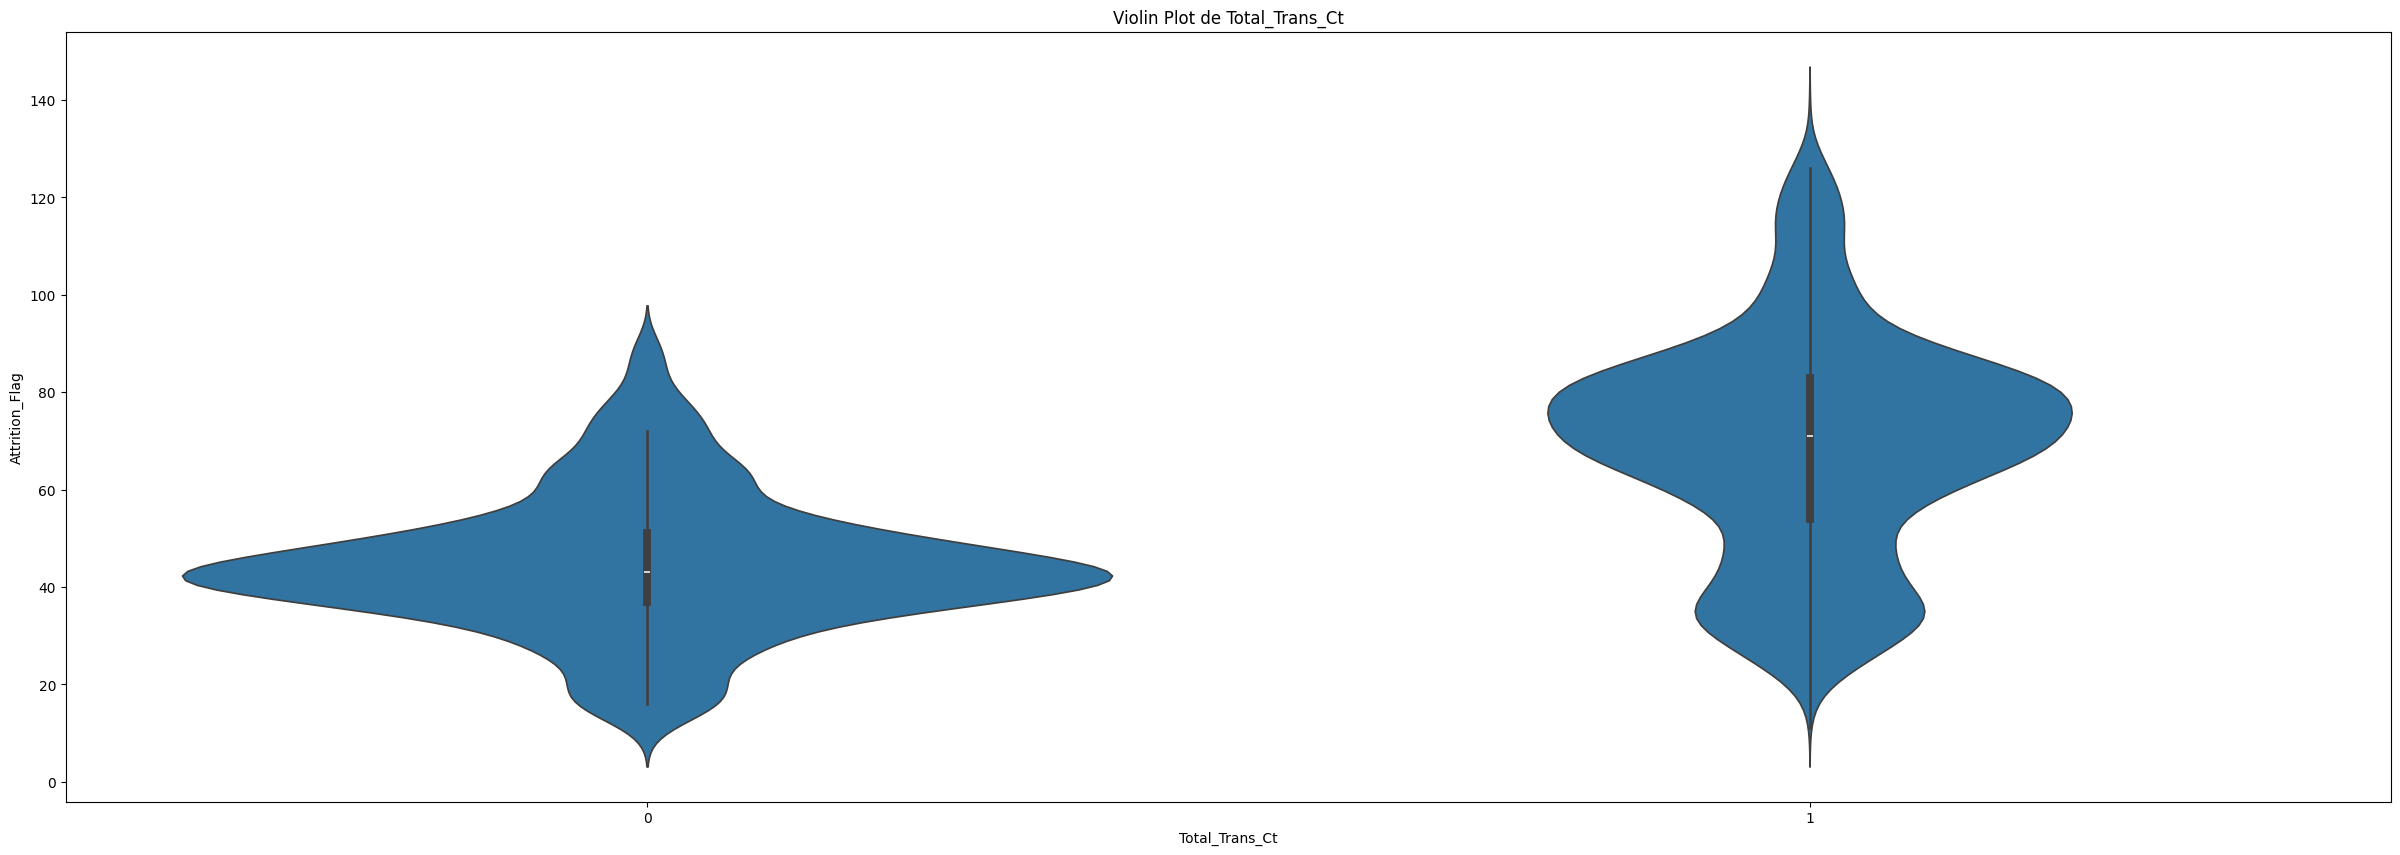

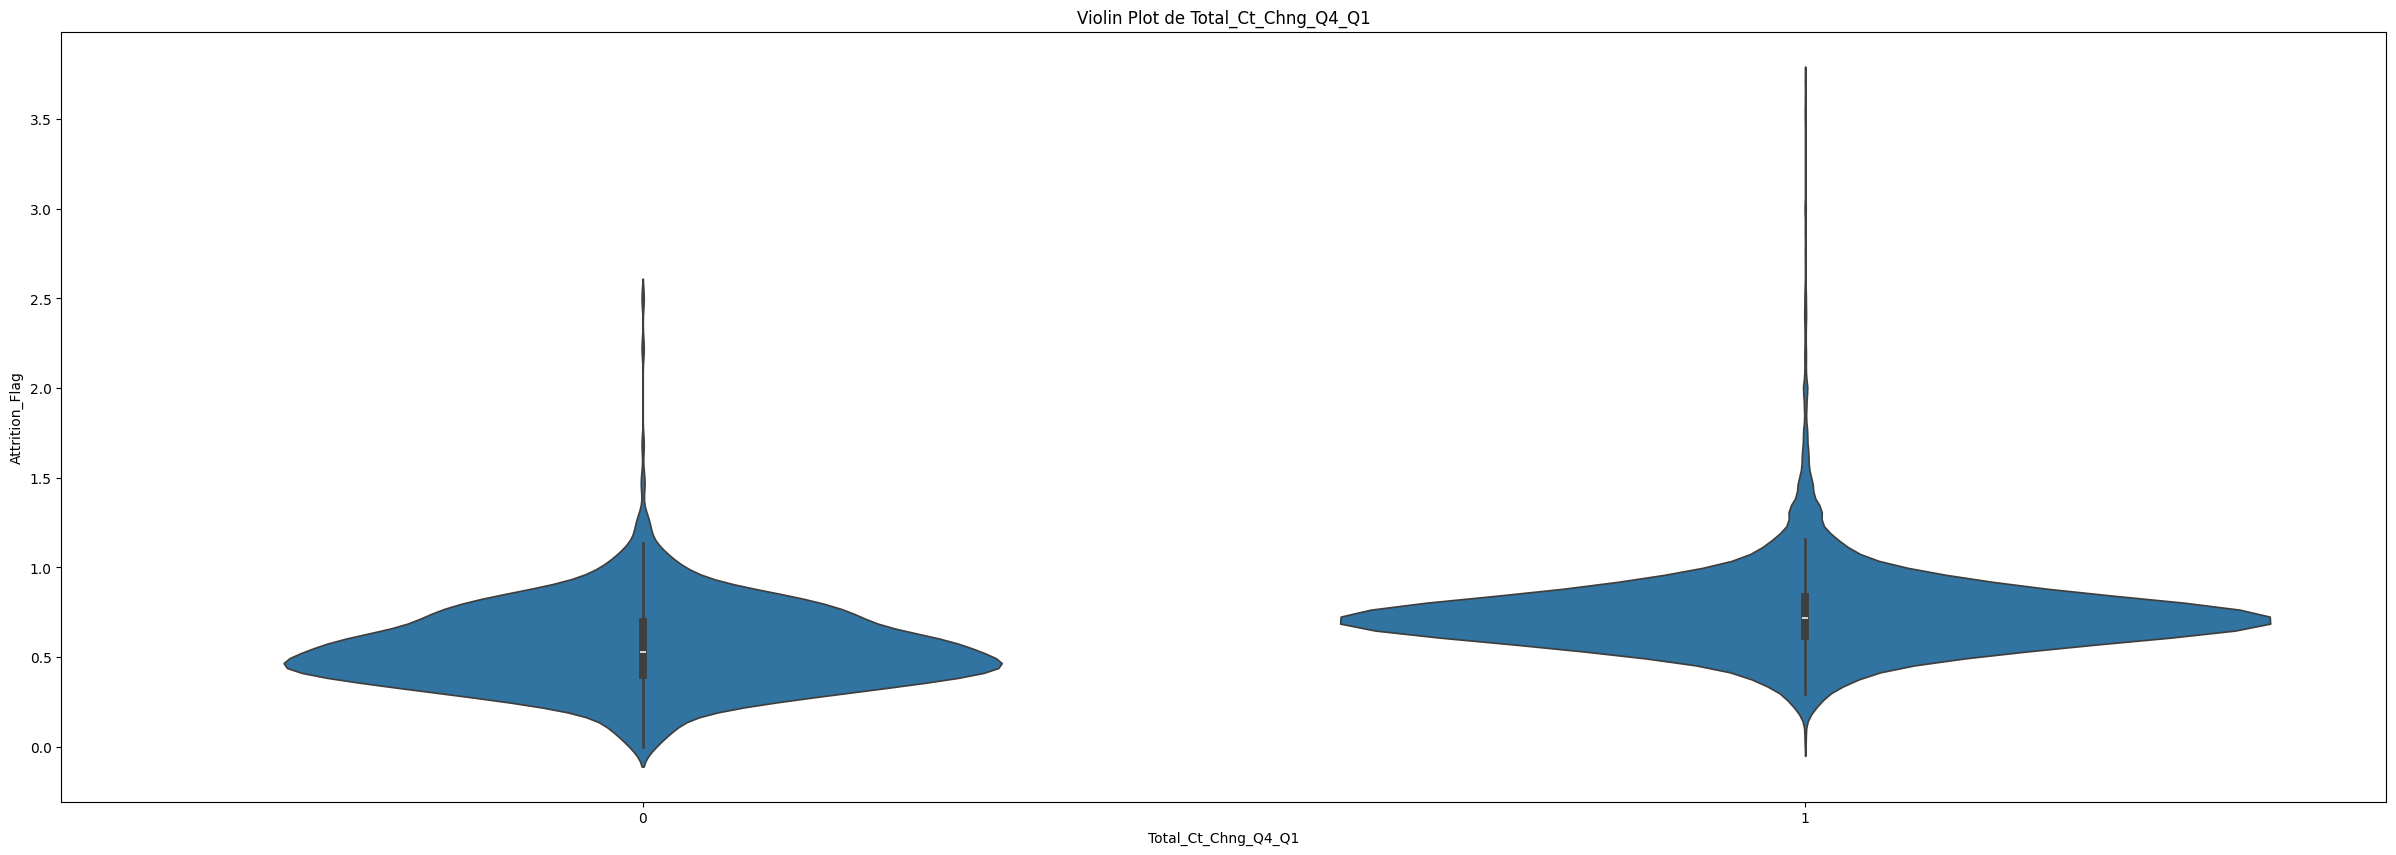

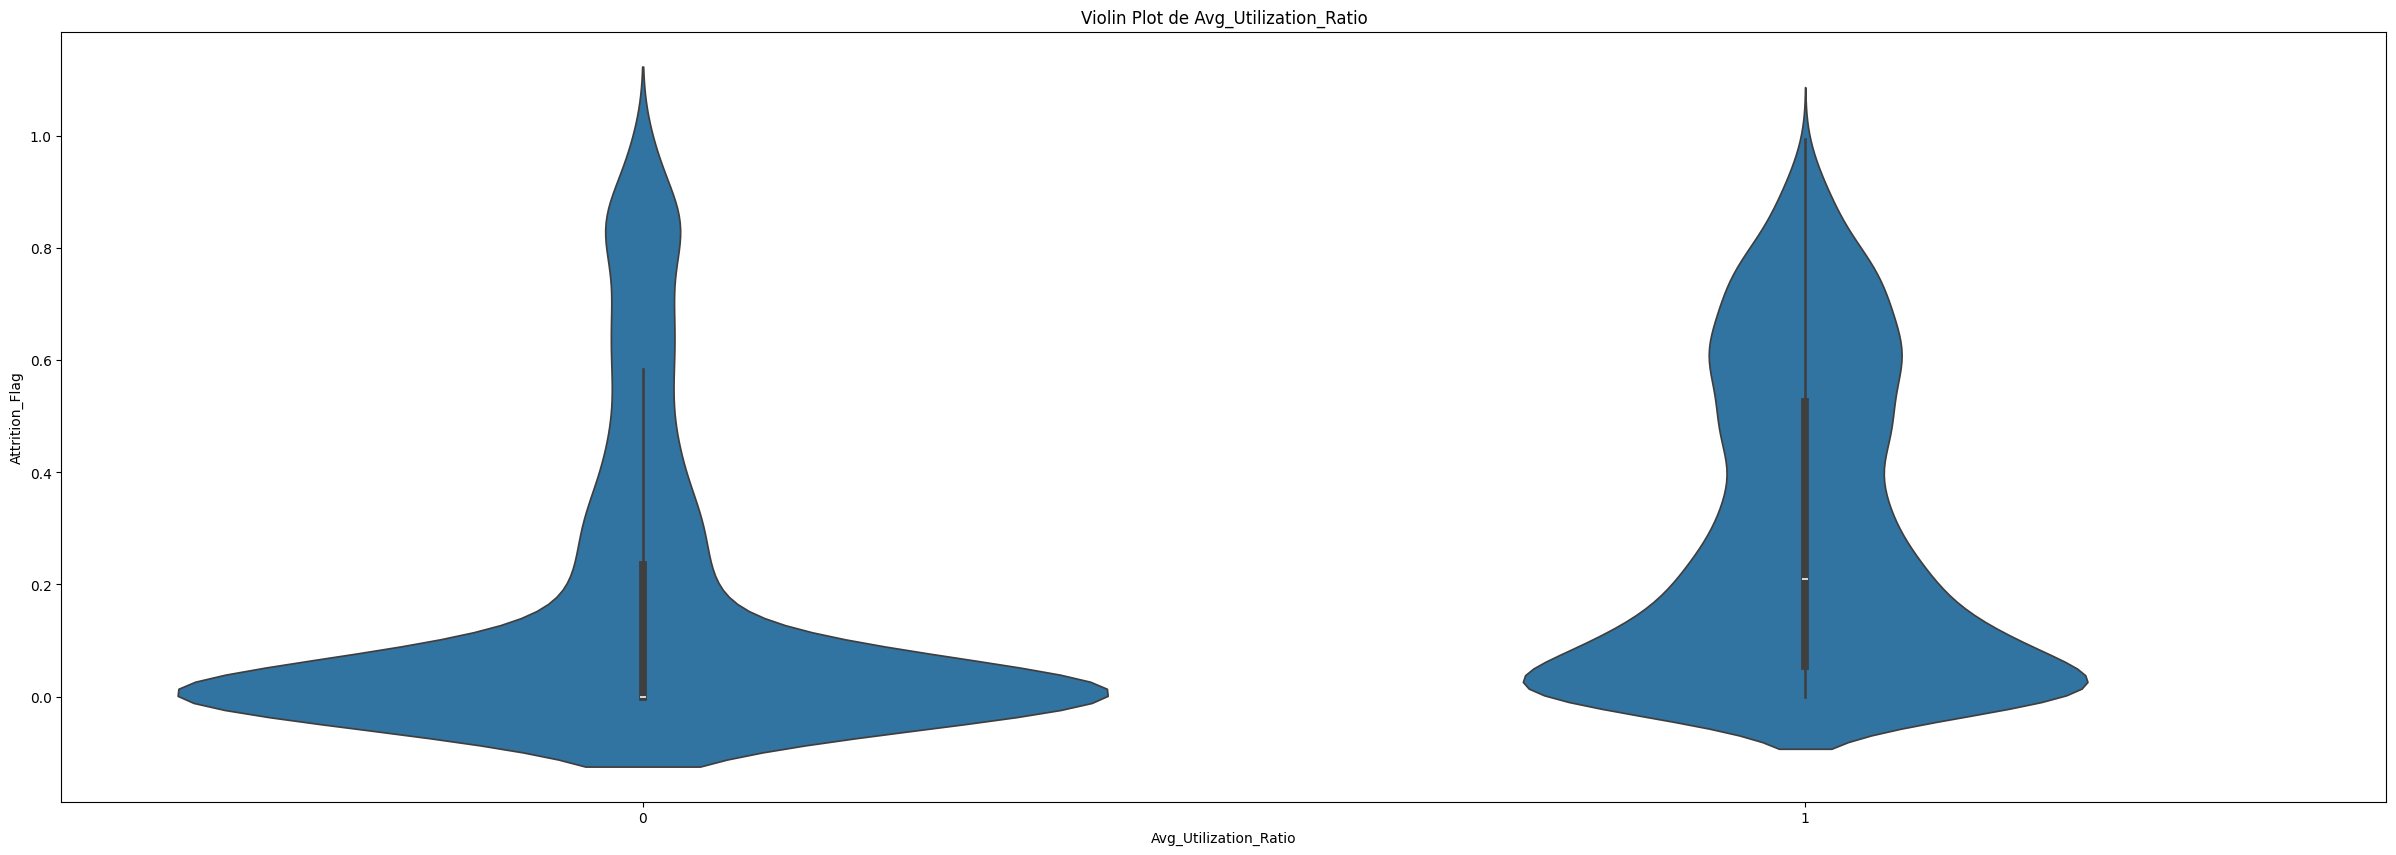

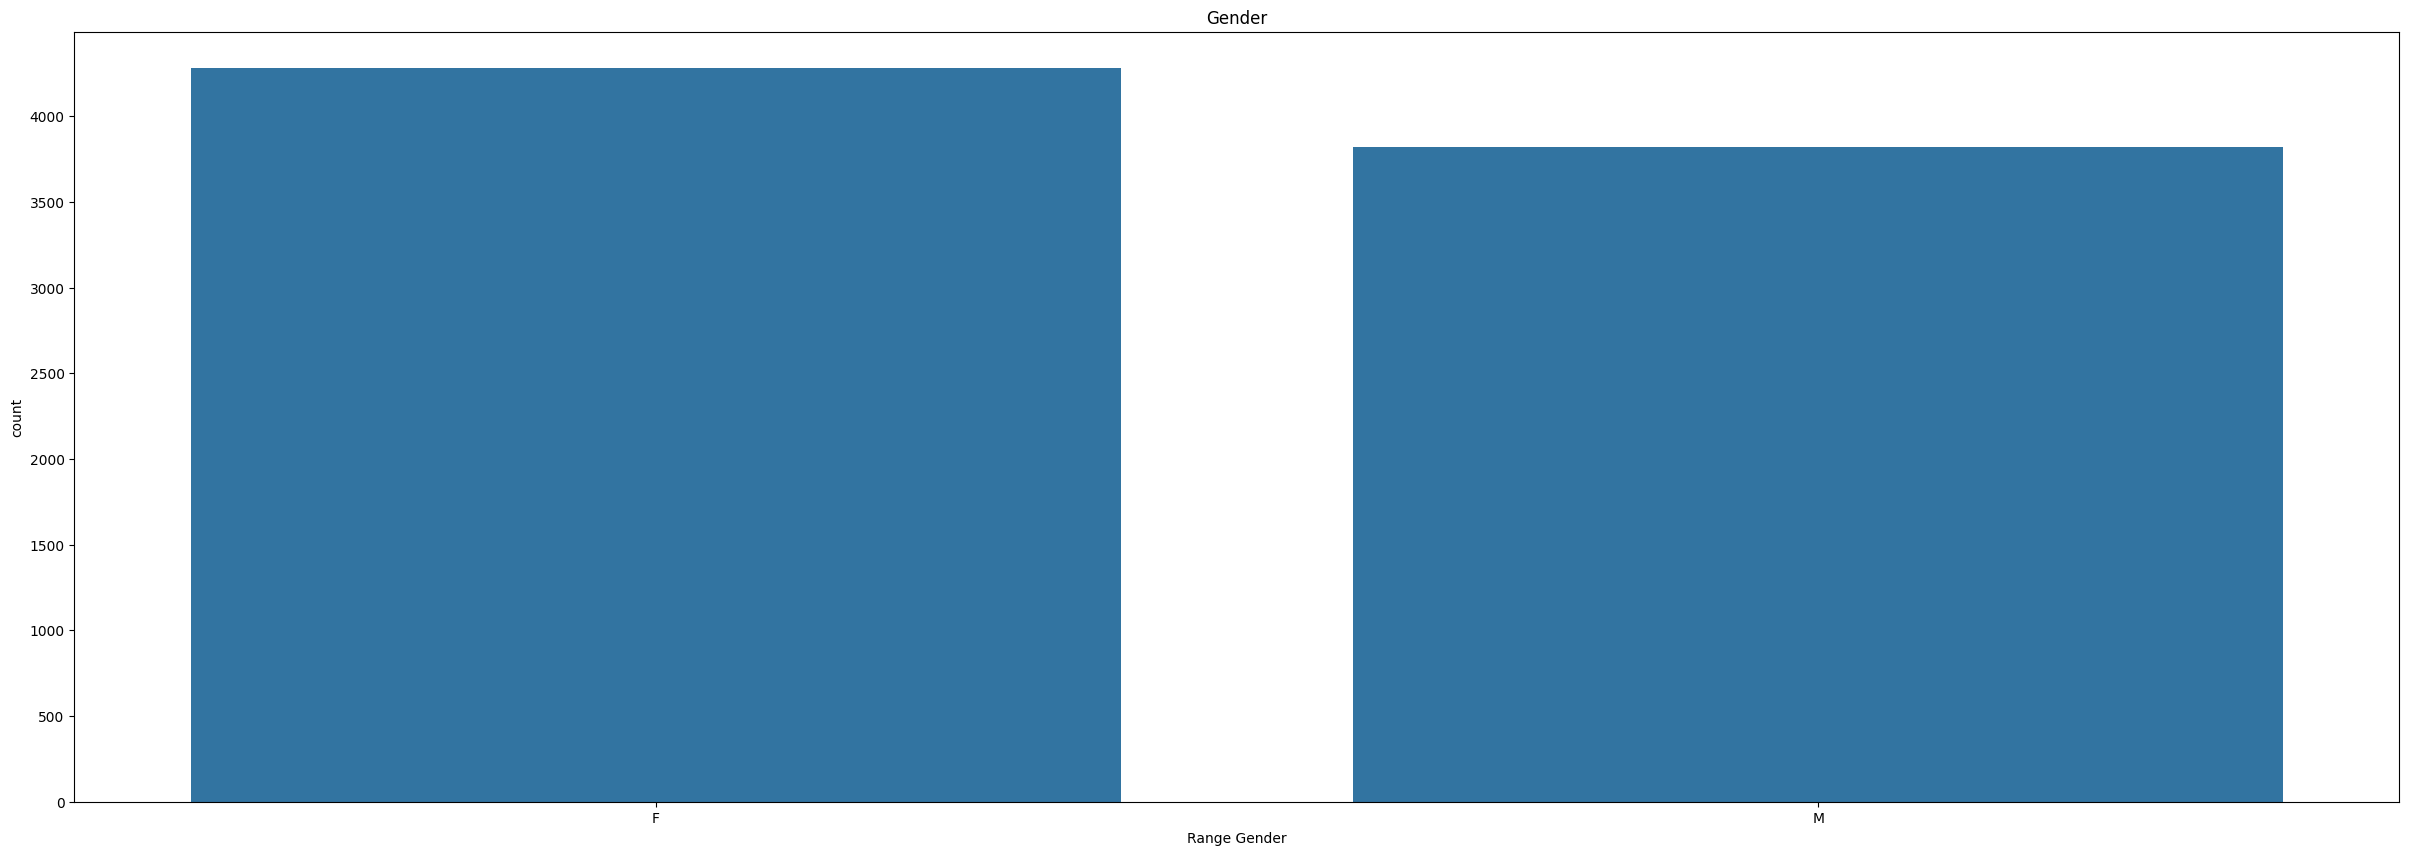

Gender
F    4279
M    3822
Name: count, dtype: int64


In [25]:
class EDA:
    def __init__(self, df, num, cat, binary, target):
        self.df = df
        self.num = num
        self.cat = cat
        self.binary = binary
        self.target = target
        self.generate_plots()

    def generate_plots(self):
        for i in self.num:
            plt.figure(figsize=(30,10))
            sns.boxplot(x=self.df[i])
            plt.title(i)
            plt.xlabel('Range ' + i)

        for i in self.cat:
            plt.figure(figsize=(30,10))
            sns.countplot(x=self.df[i])
            plt.title(i)
            plt.xlabel('Range ' + i)

        for i in self.num:
            if self.df[i].dtype in ['int64', 'float64'] and len(self.df[i].unique()) > 1:
                plt.figure(figsize=(30,10))
                sns.violinplot(x=self.target, y=i, data=self.df)
                plt.title(f'Violin Plot de {i}')
                plt.xlabel(i)
                plt.ylabel(self.target)
                plt.show()


        for i in self.binary:
            plt.figure(figsize=(30,10))
            sns.countplot(x=self.df[i])
            plt.title(i)
            plt.xlabel('Range ' + i)
            plt.show()
            print(self.df[i].value_counts())
    
EDA(df_train, num, cat, binary, target)

- Income_category, Marital_Status, Education_Level: These have an unknown value.
- Card_Category, Income_Category, Education_level: These are categories on a scale. They can be converted to numerical values ​​for statistical purposes.
Dilemma: Should I remove outliers to create a more accurate model? I have few.

Analysis of the dependent or target variable, compared to the other variables

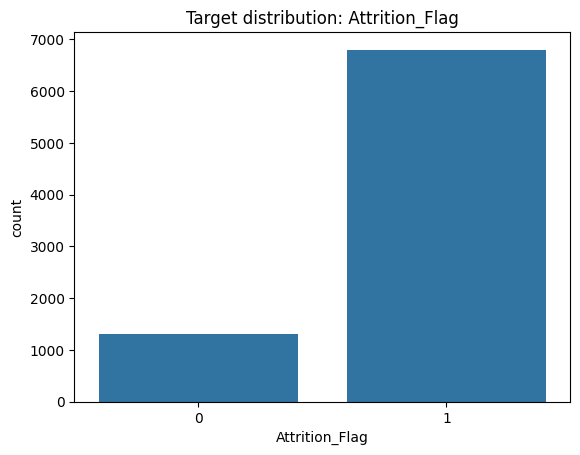

In [26]:
sns.countplot(data=df_train, x=target)
plt.title('Target distribution: '+ target)
plt.show()

- The data needs to be rebalanced.
- In this case, F1 is one of the best metrics; it has a relationship with evaluation metrics.

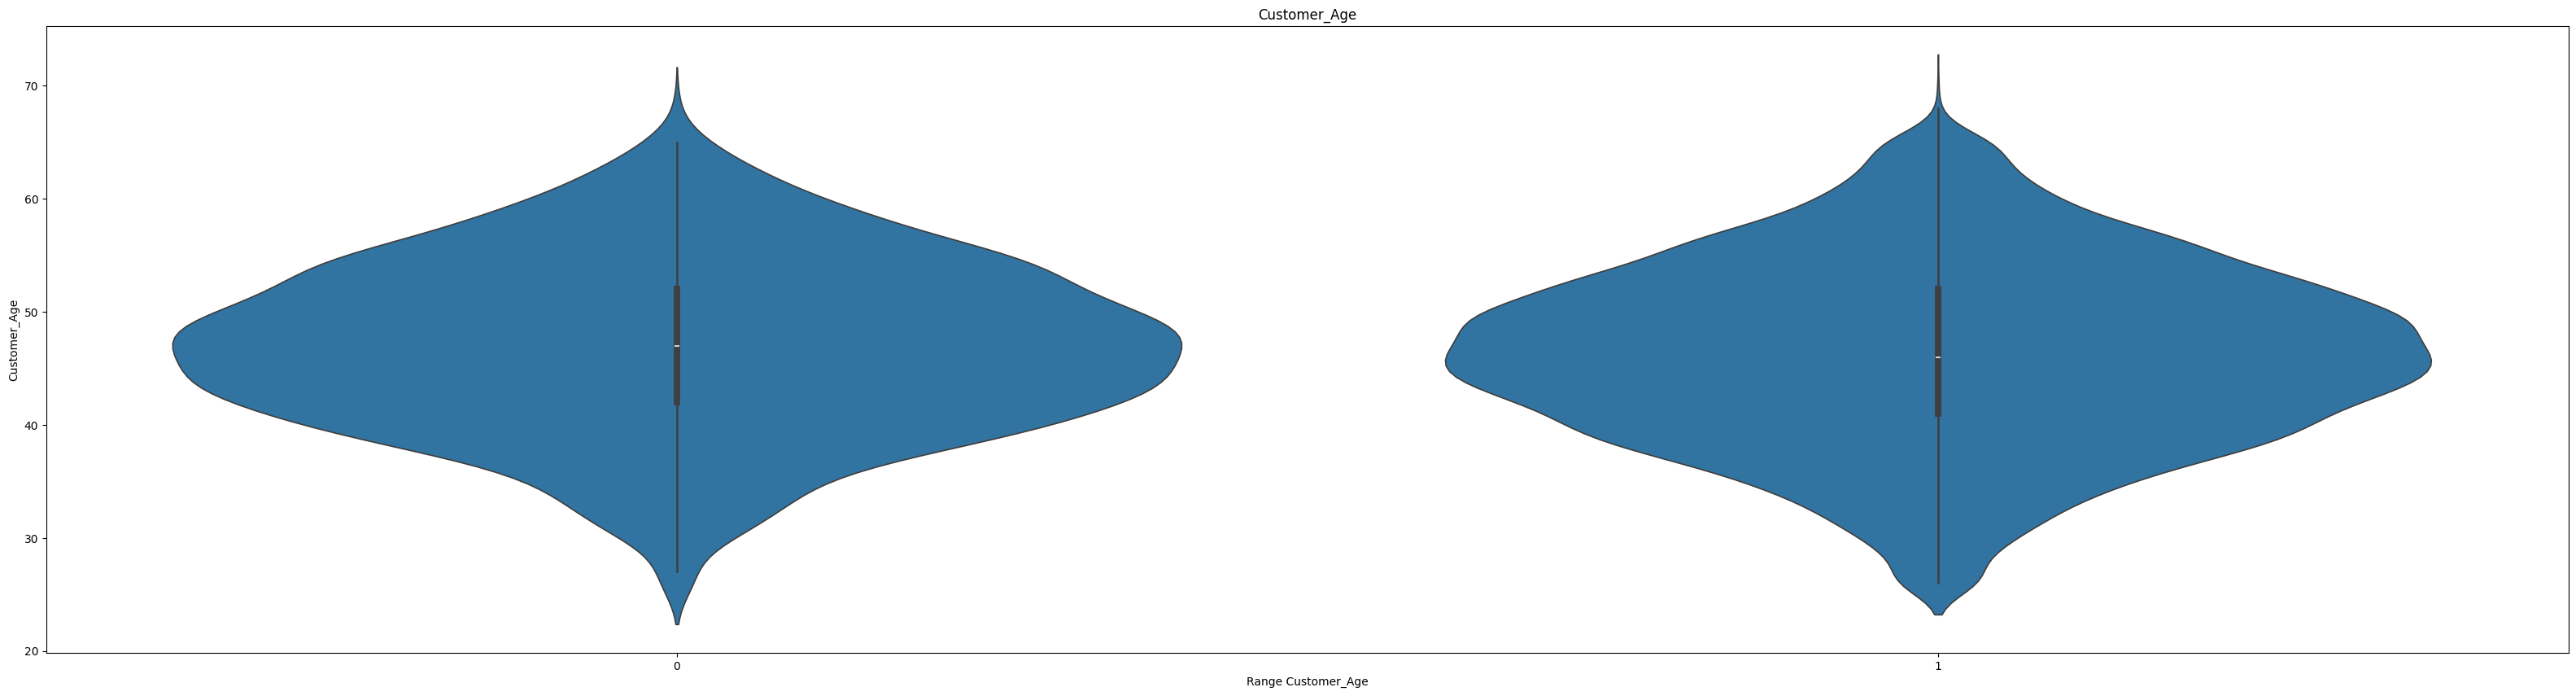

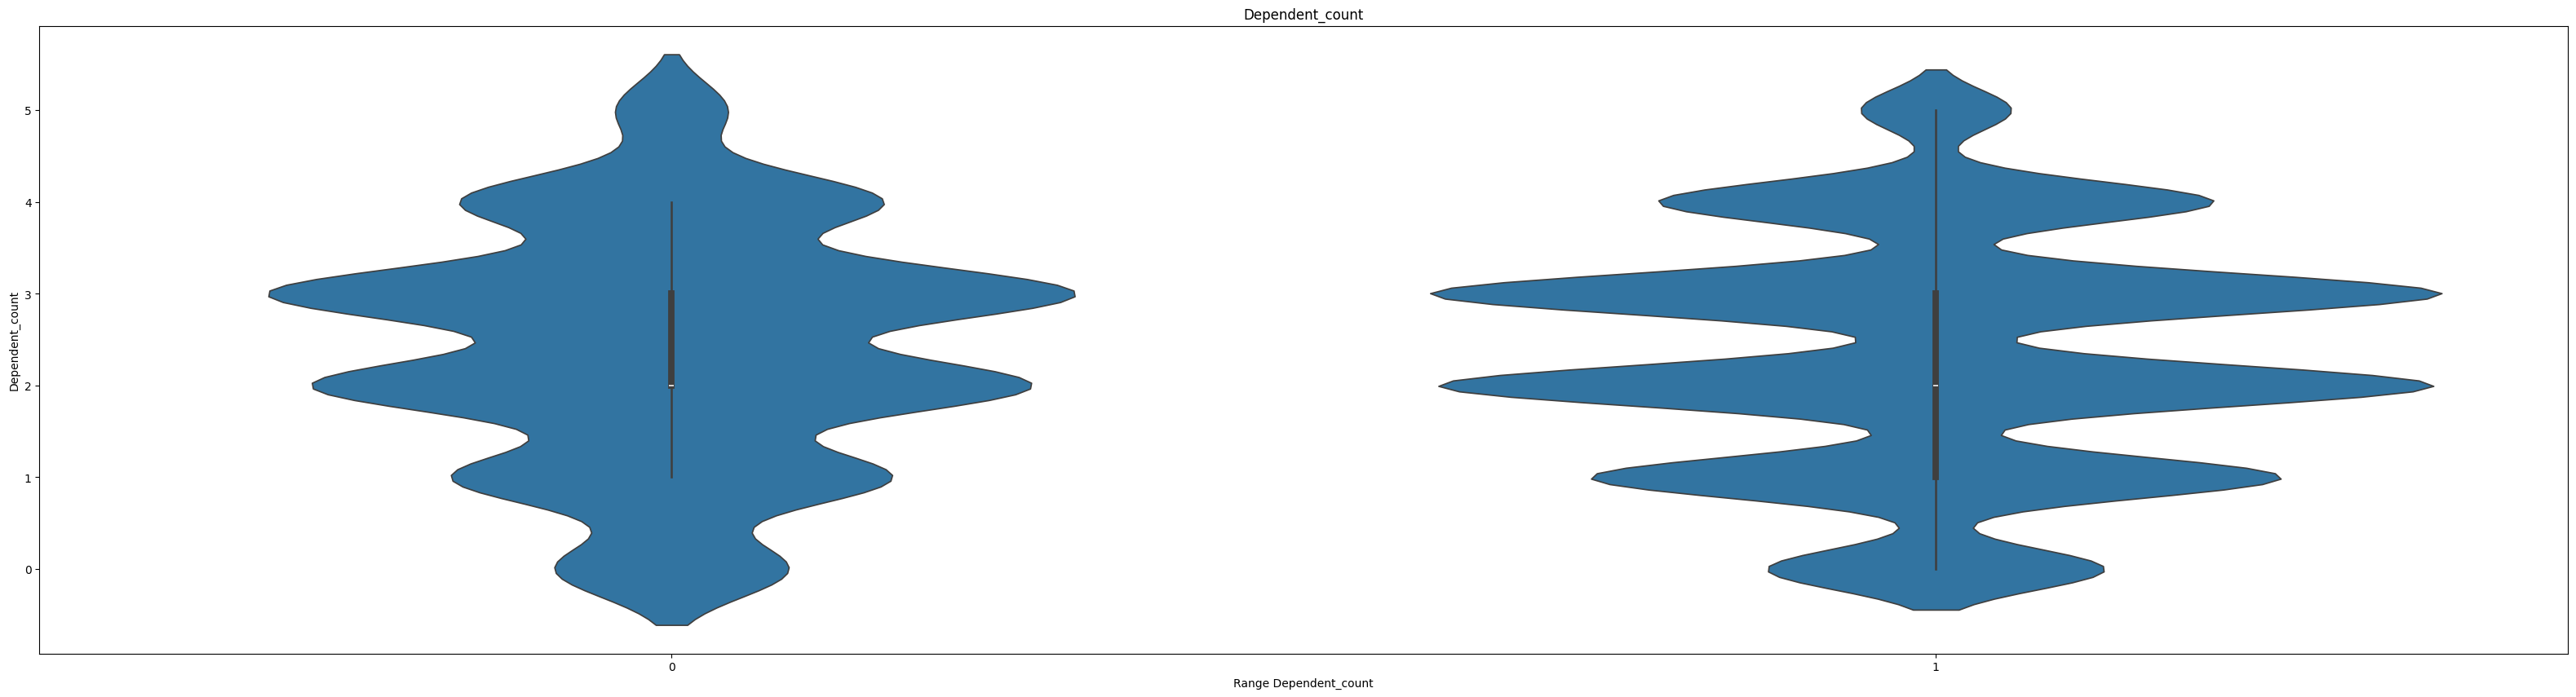

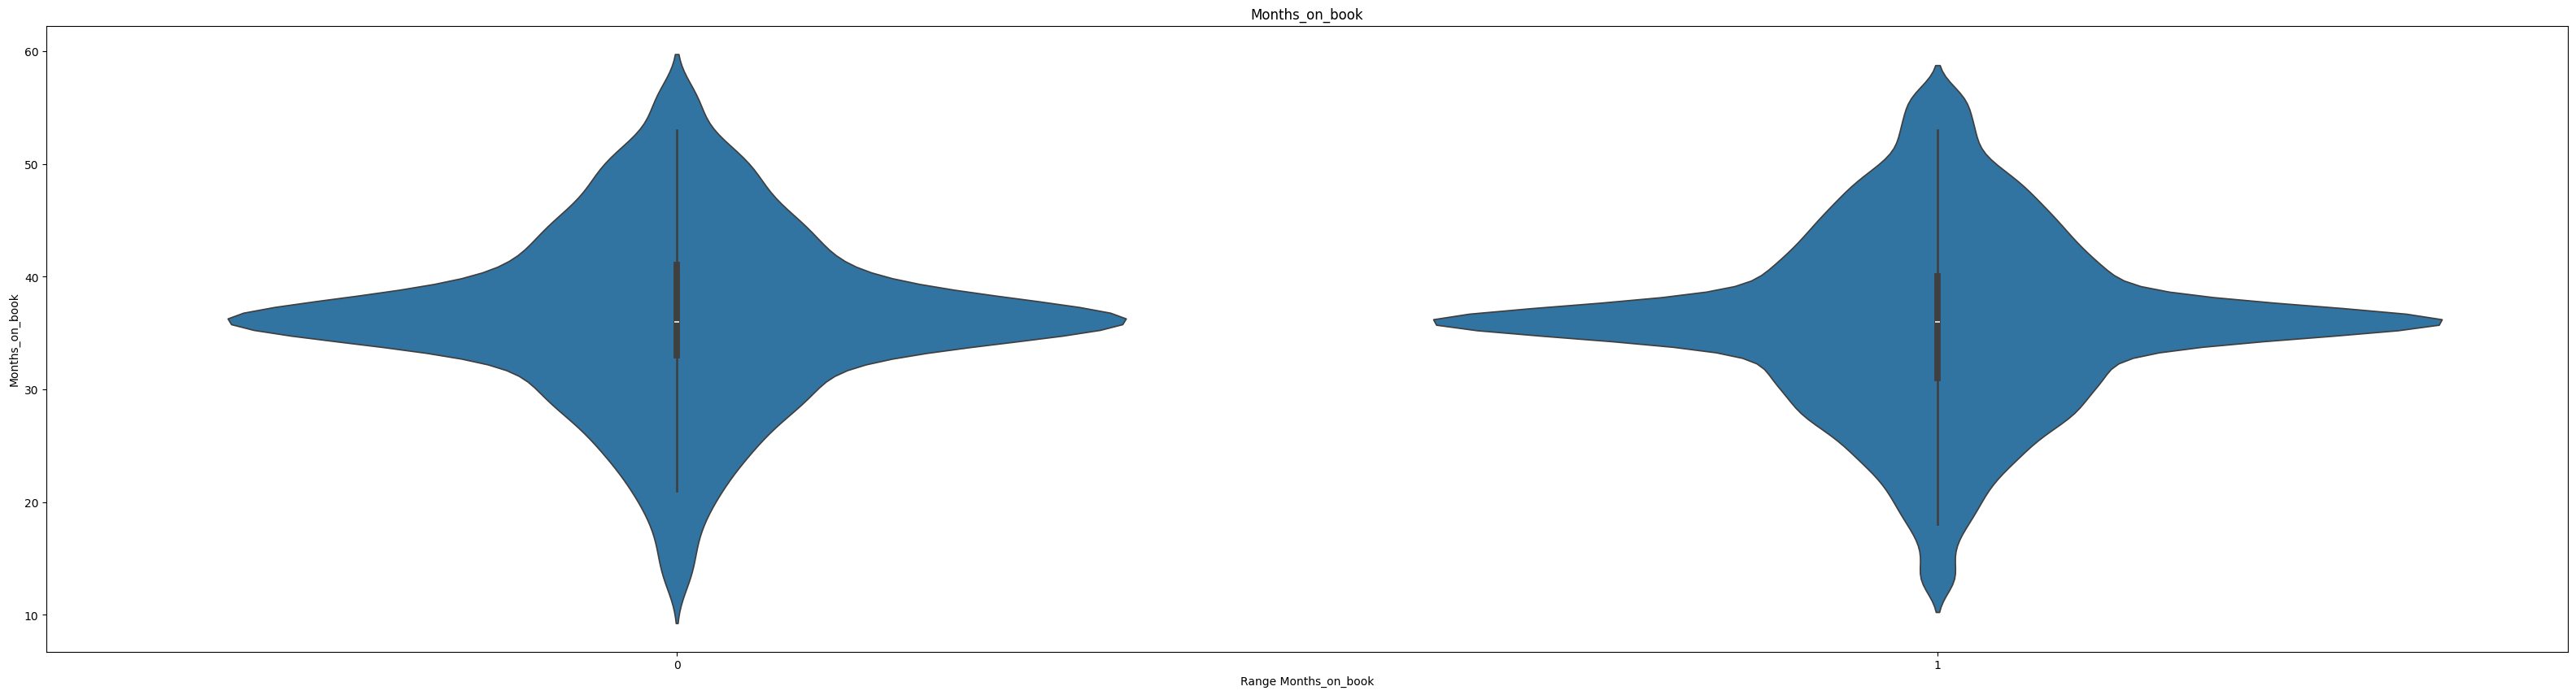

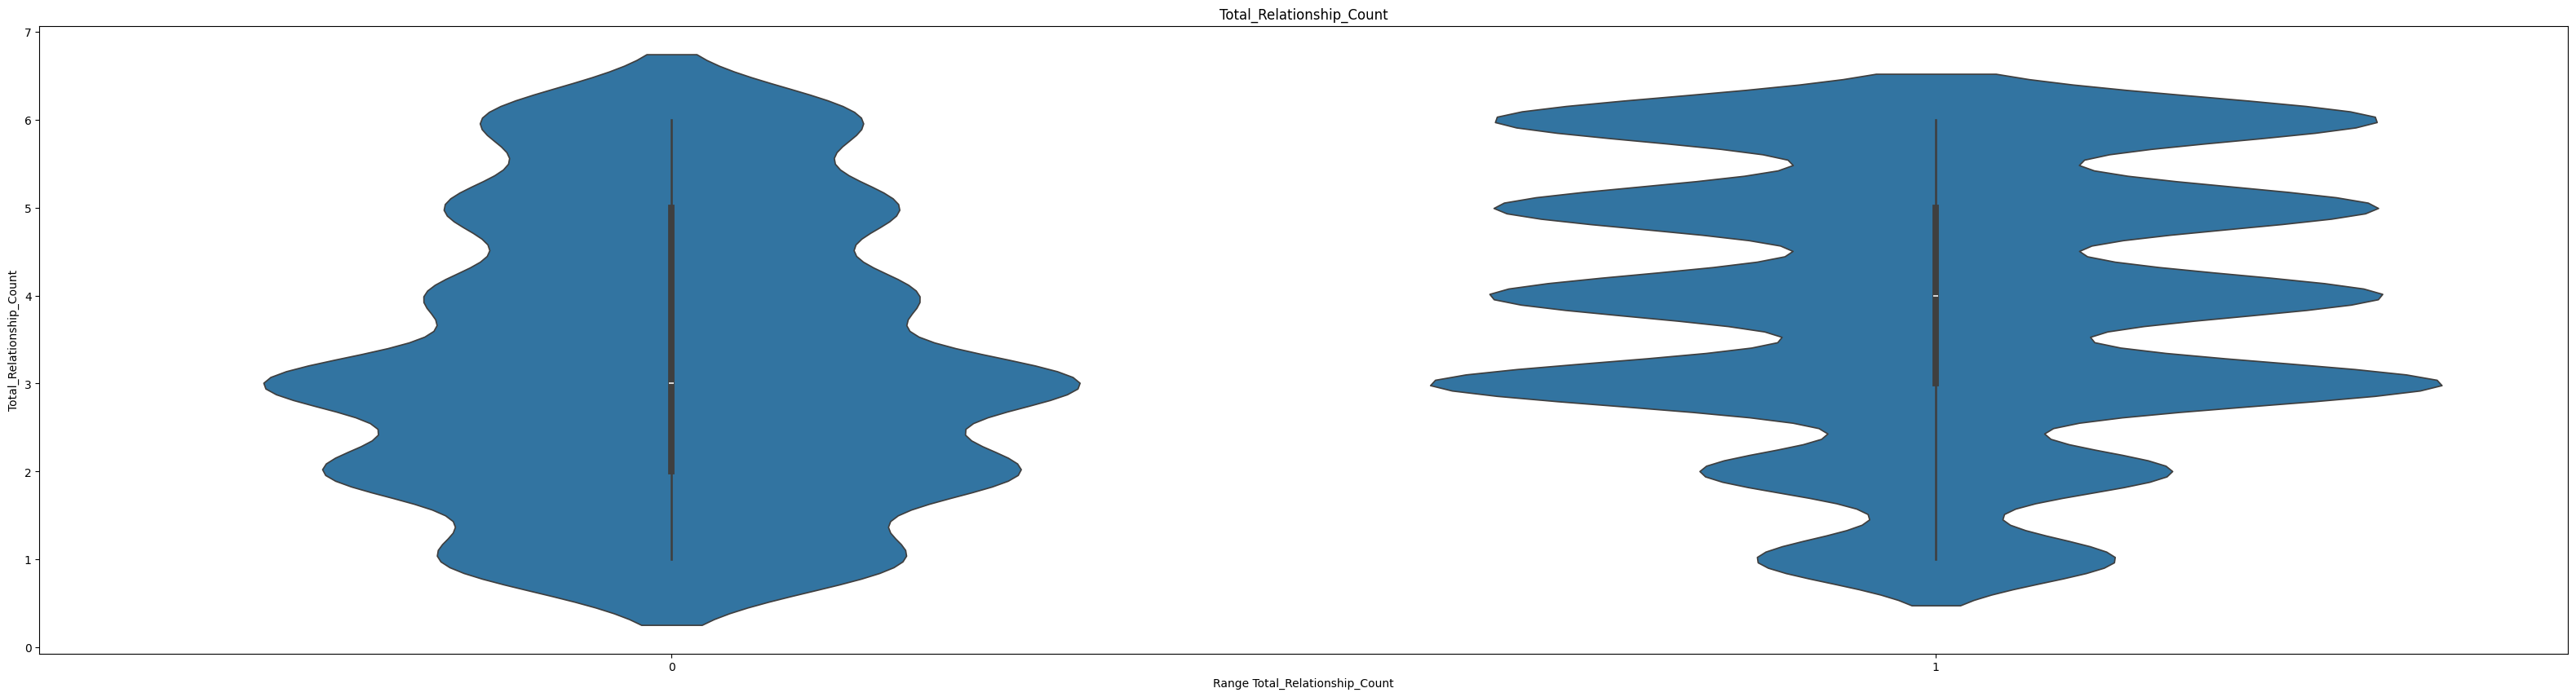

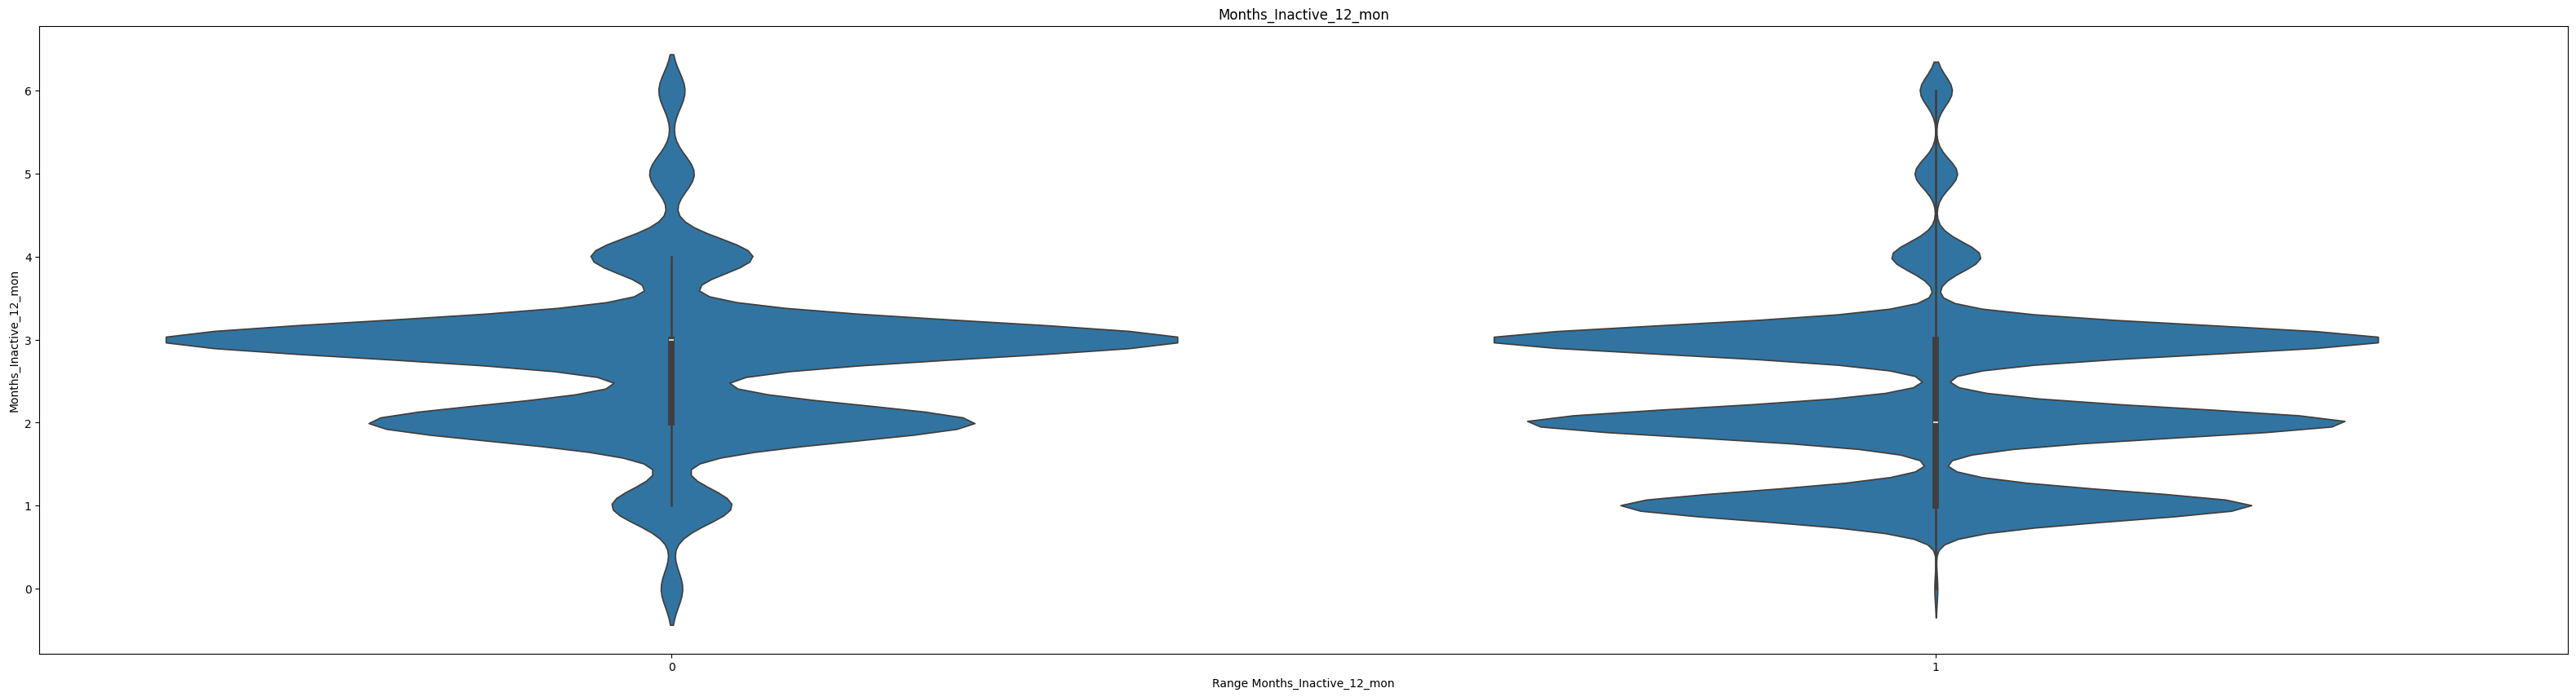

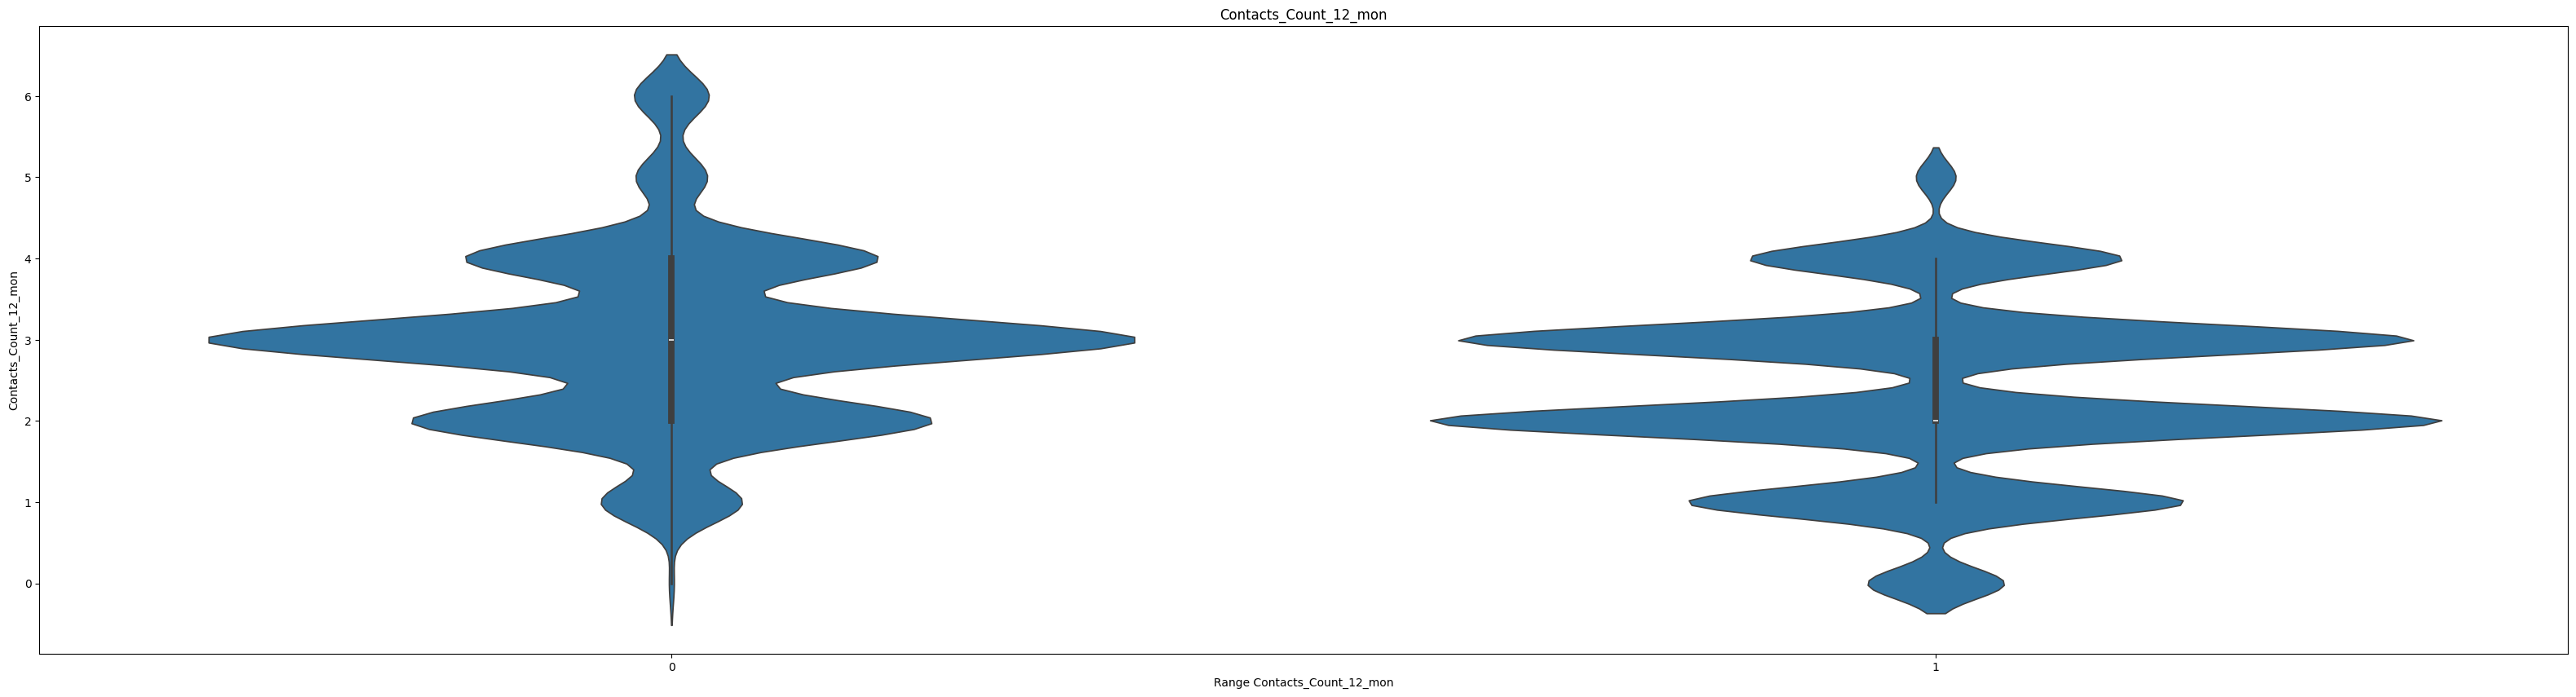

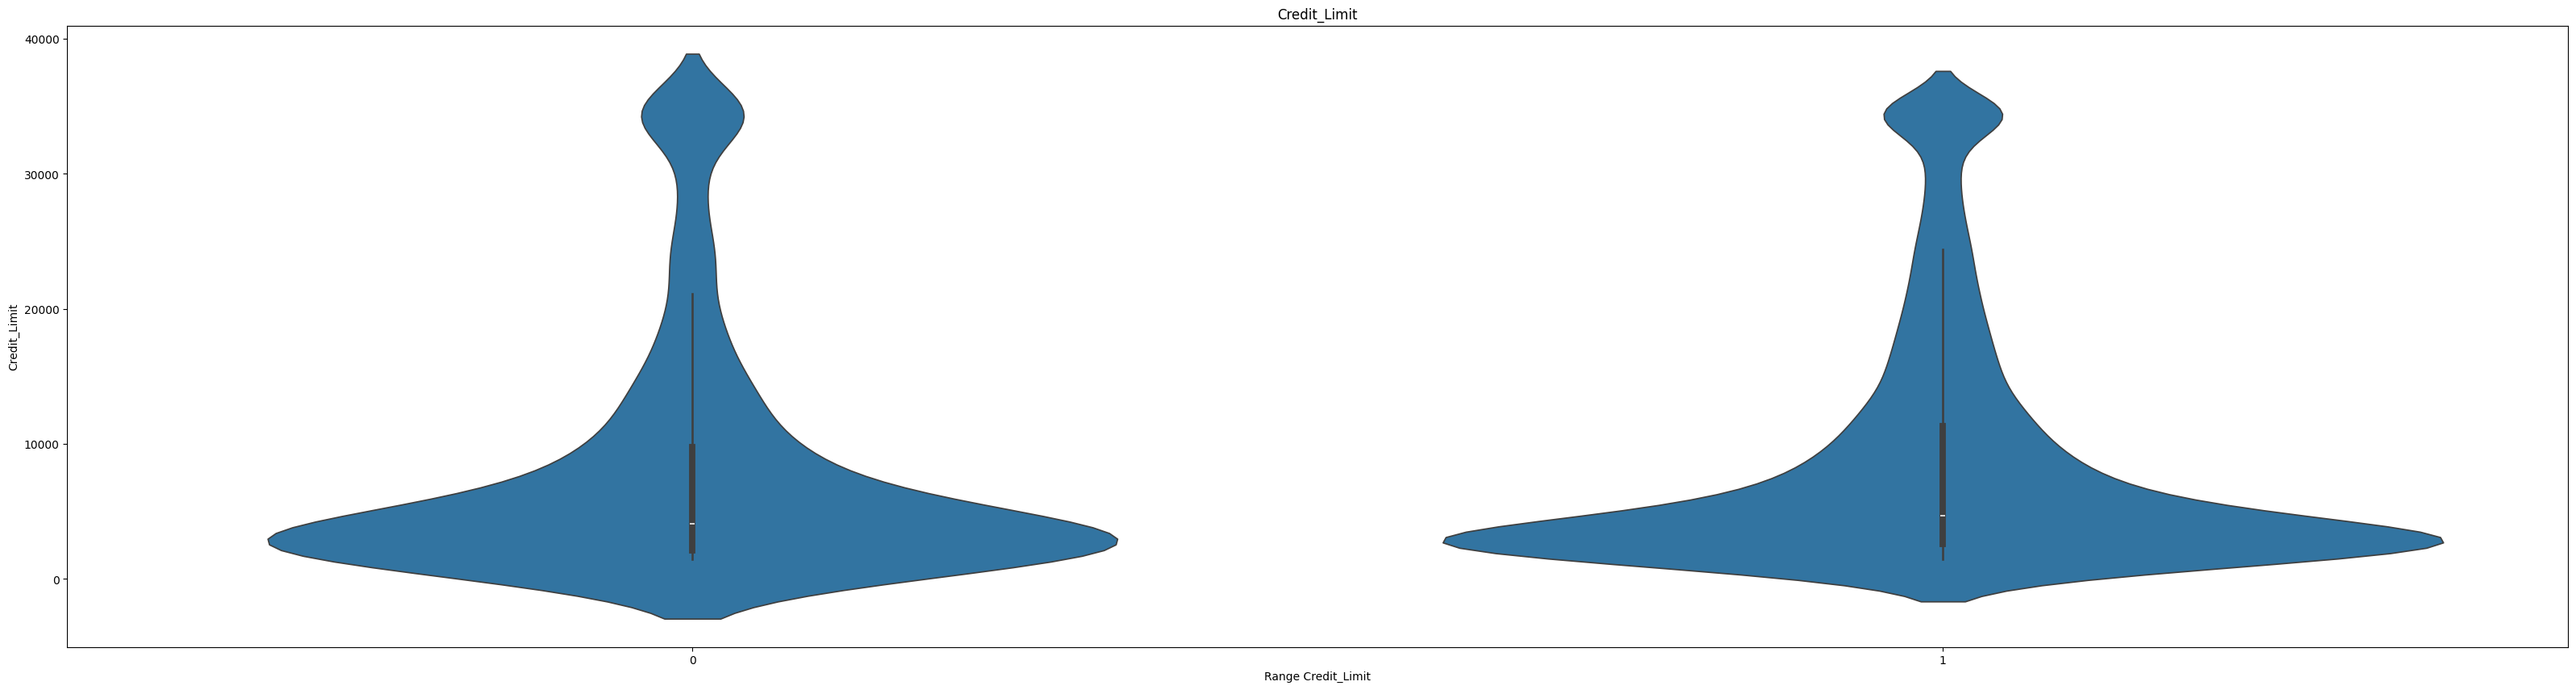

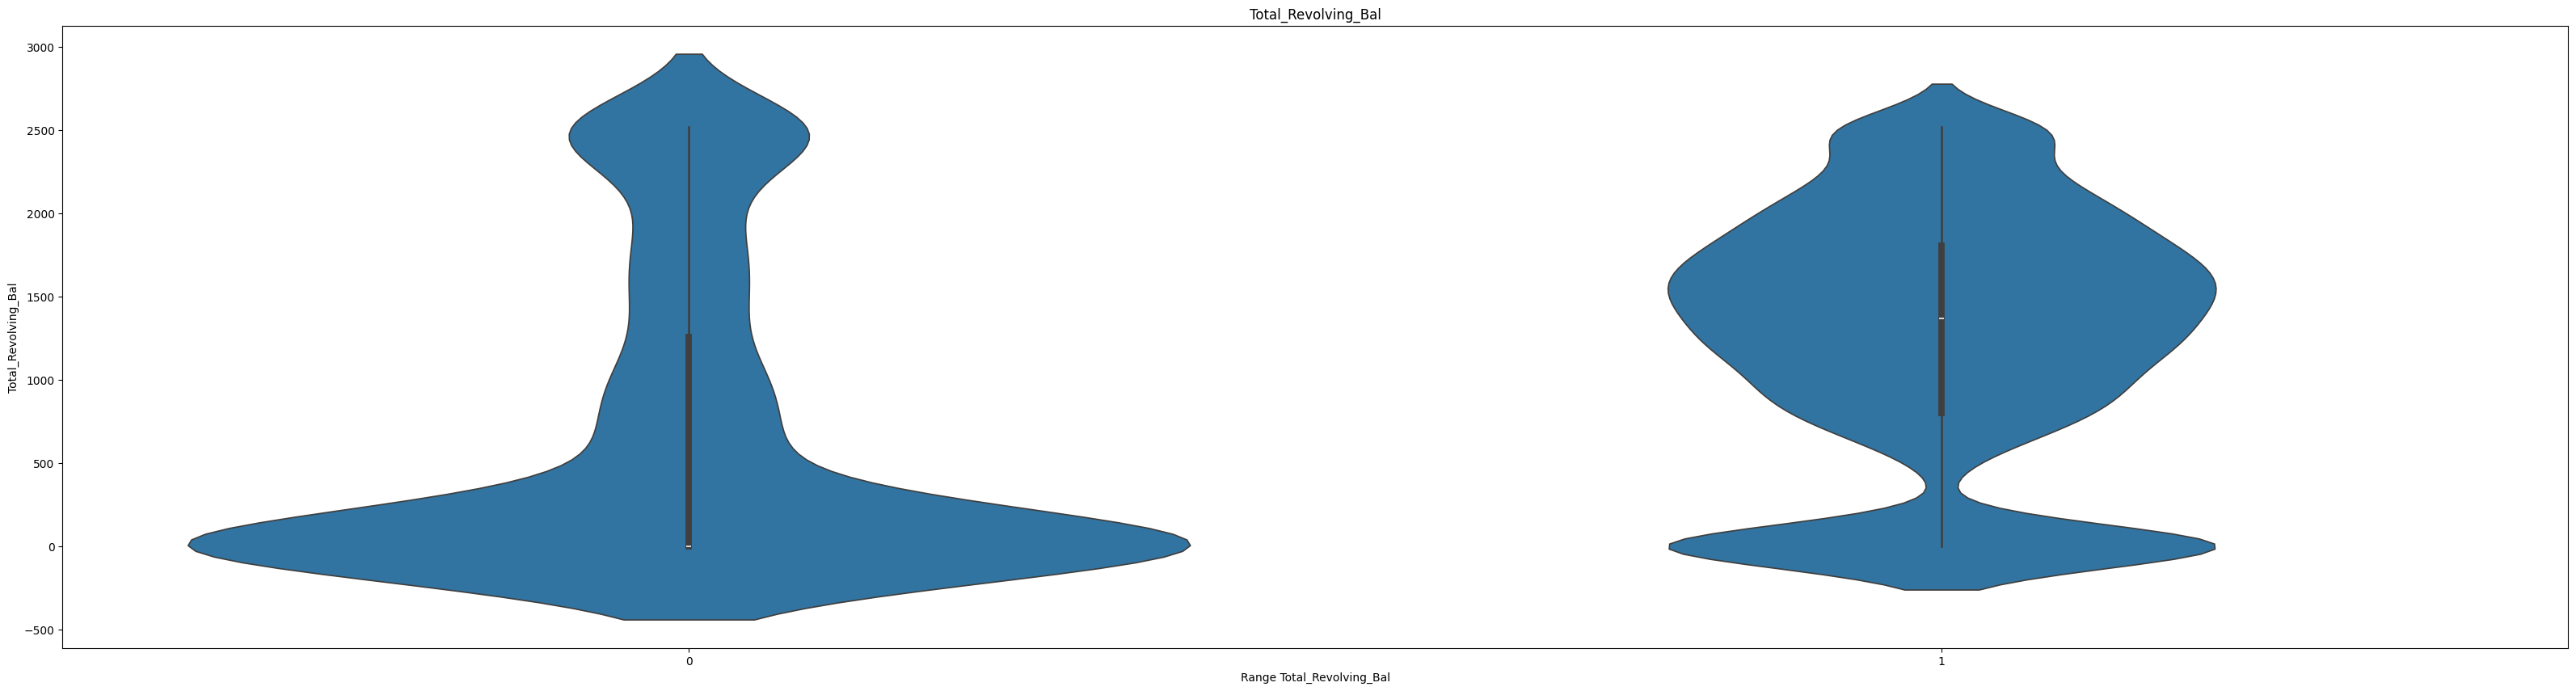

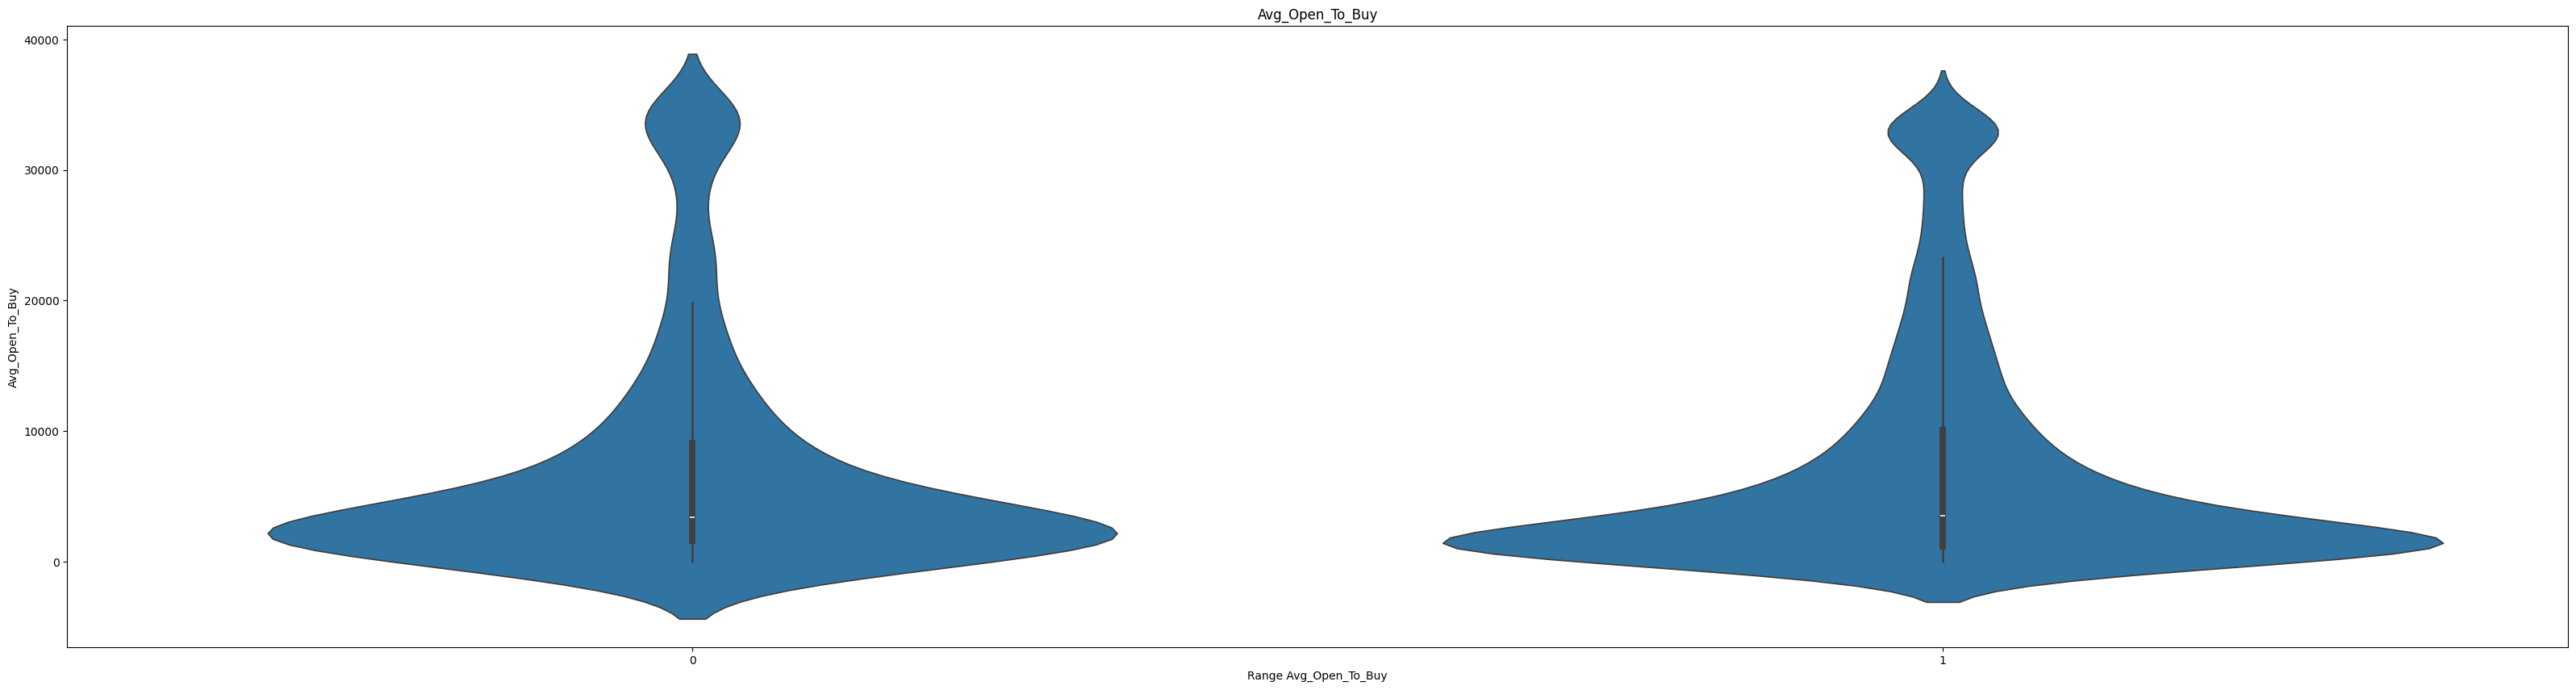

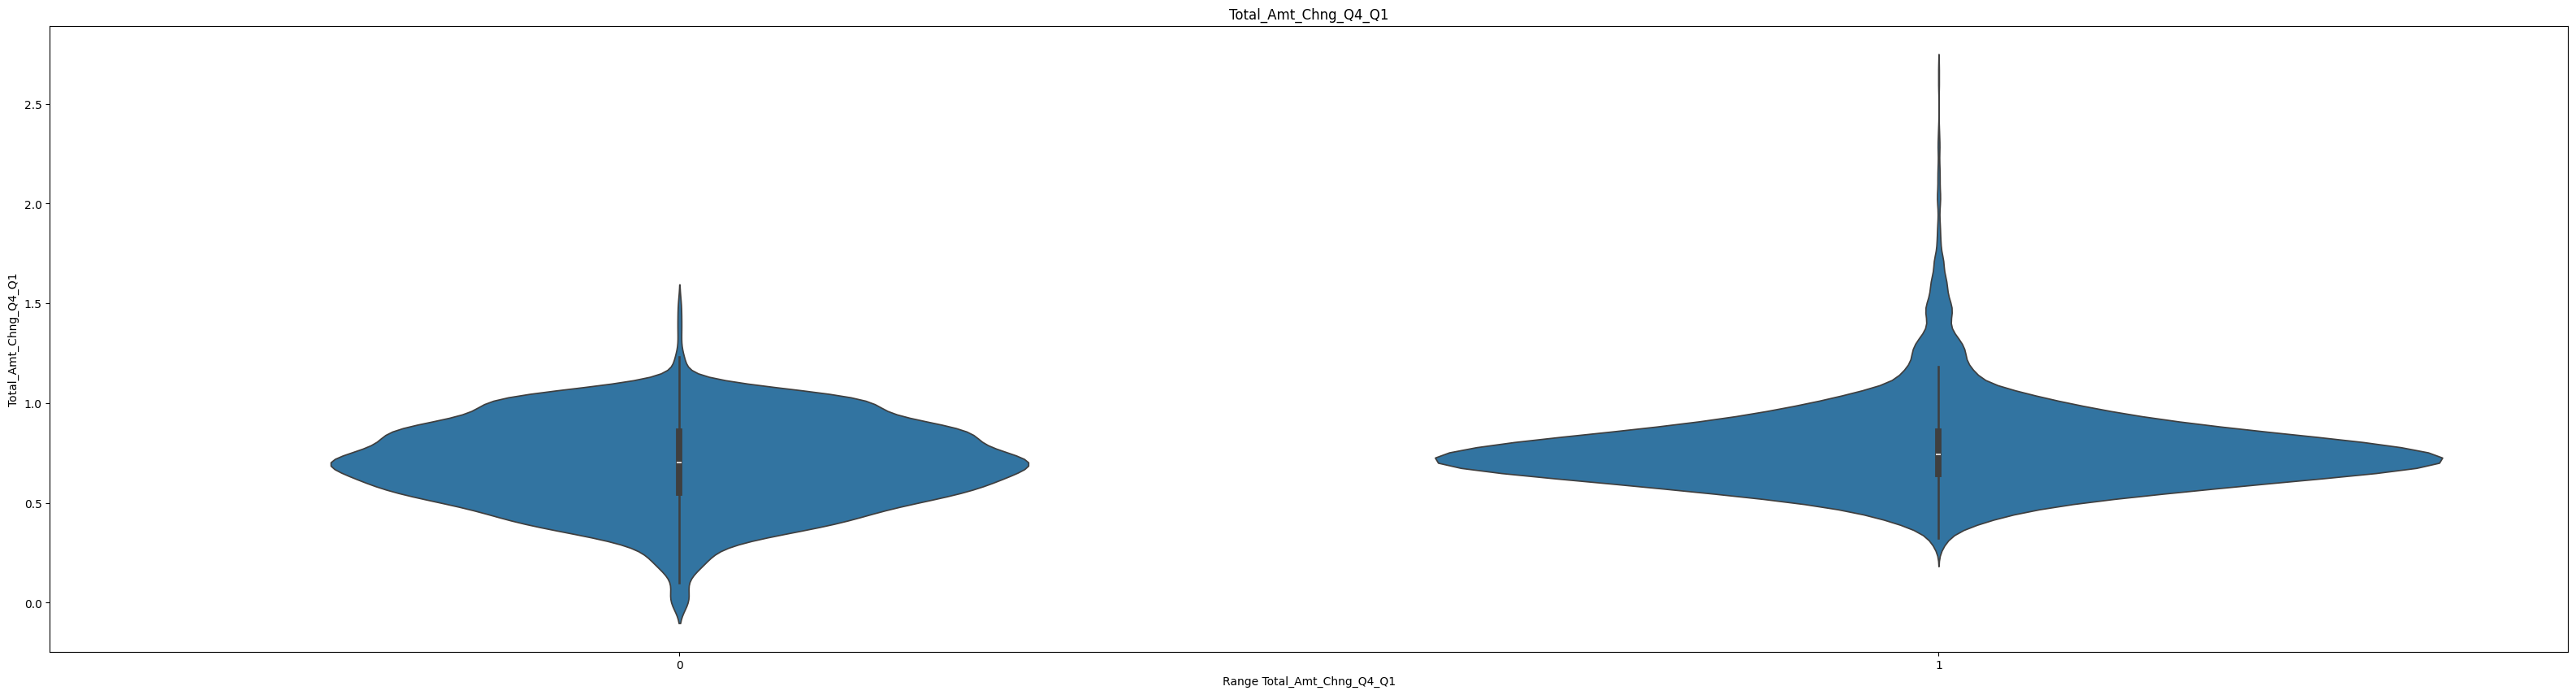

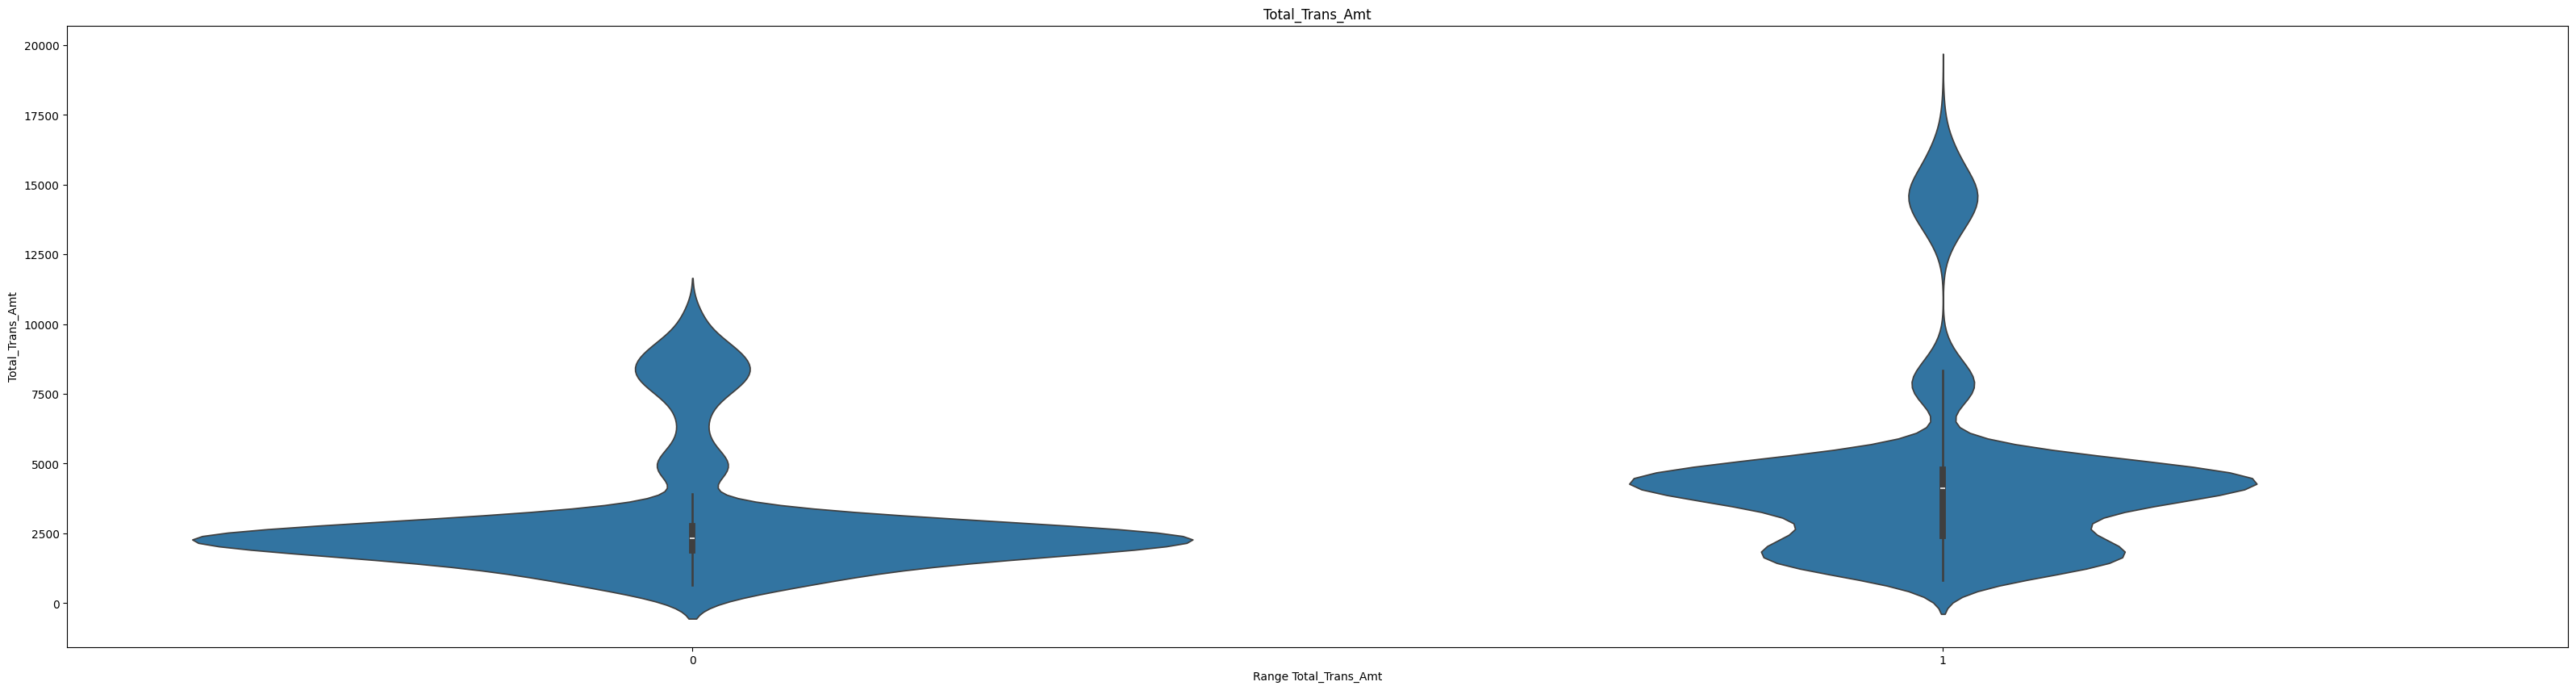

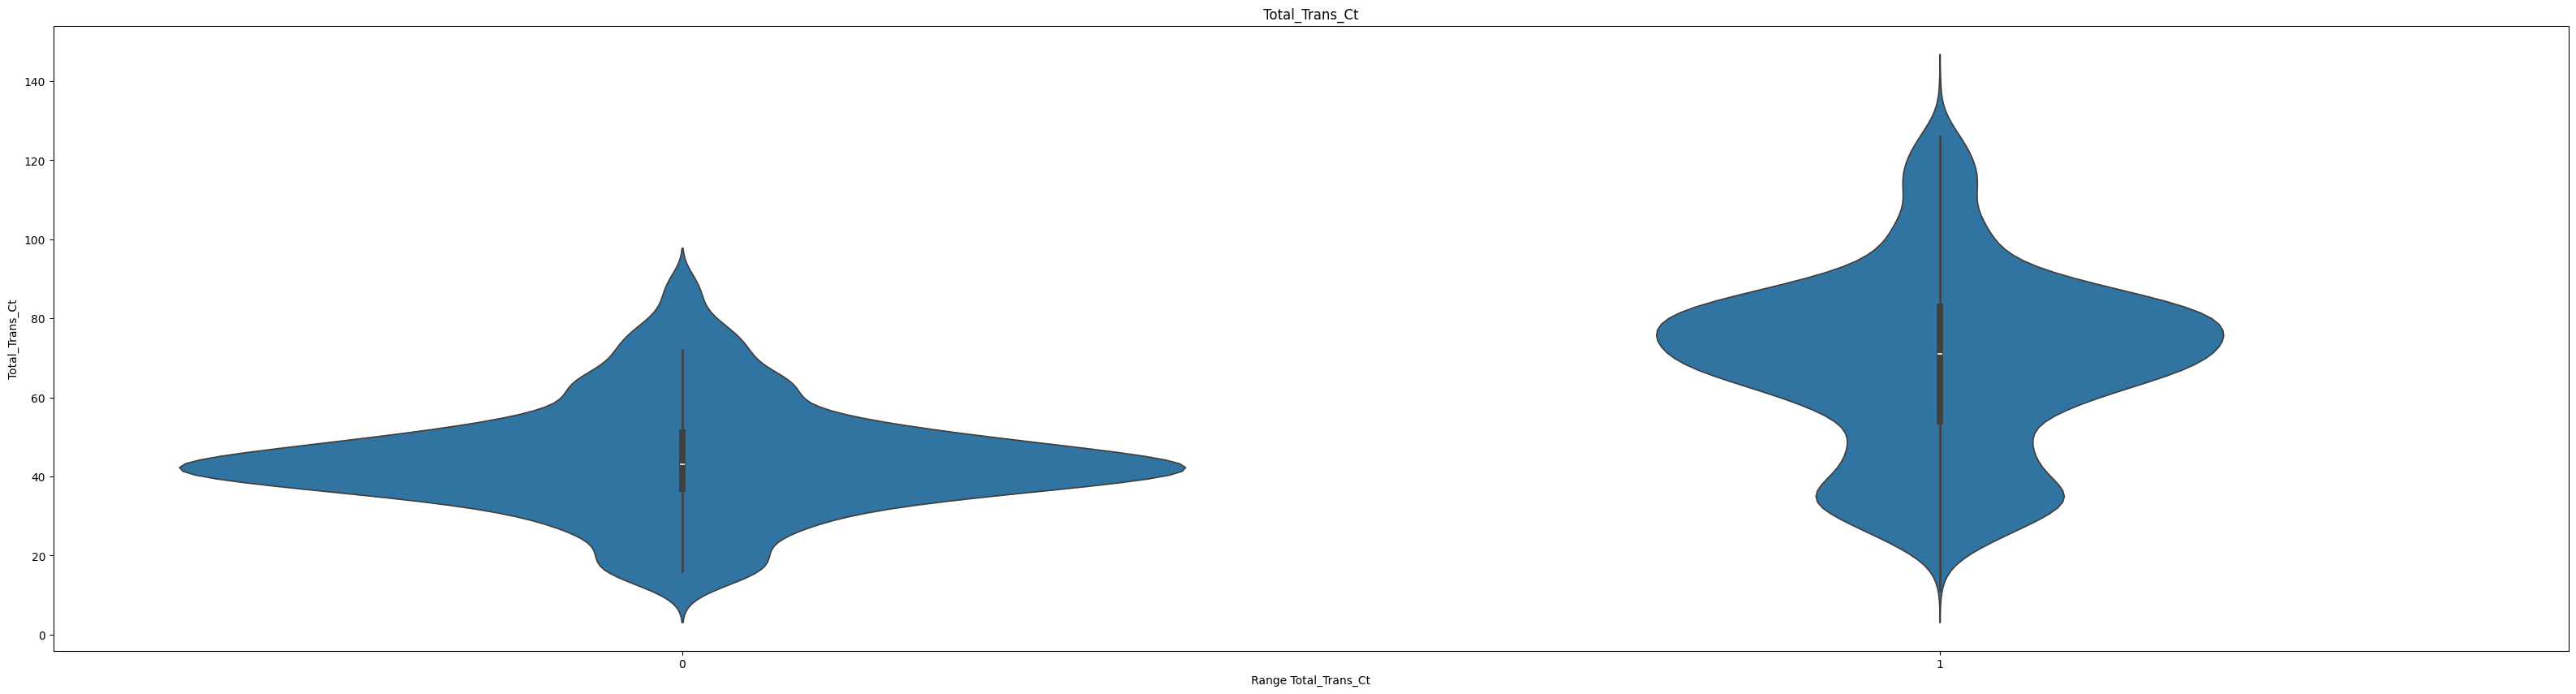

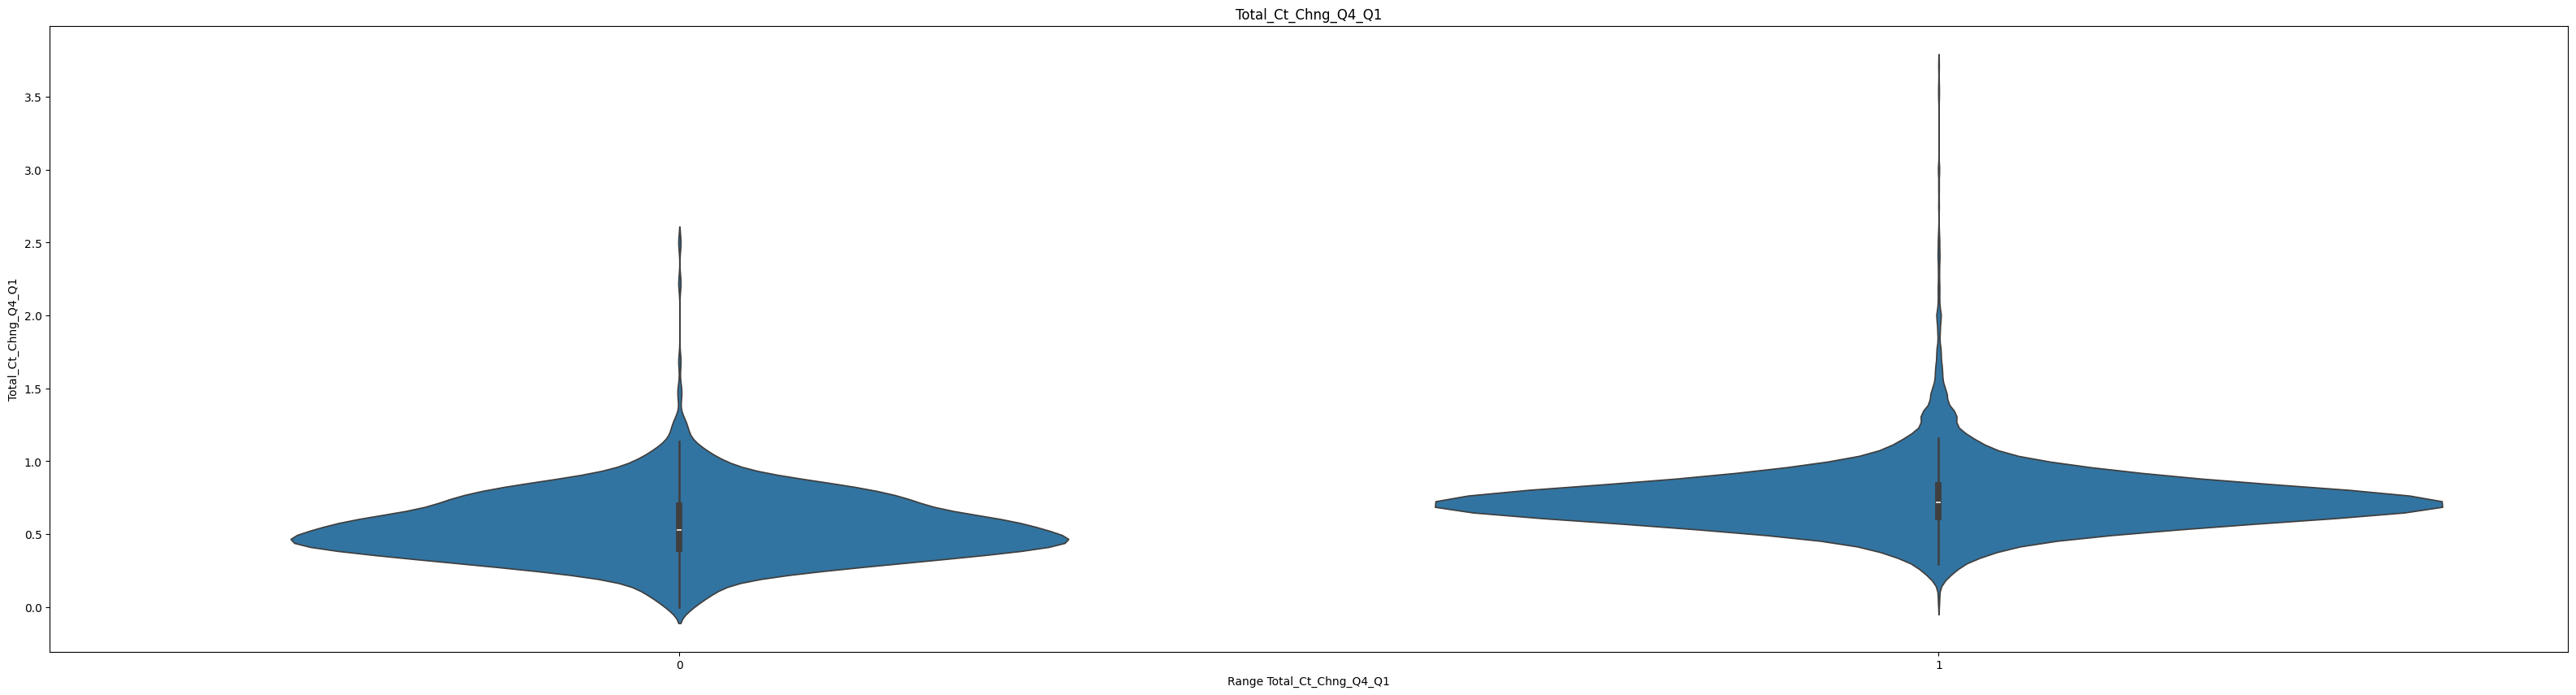

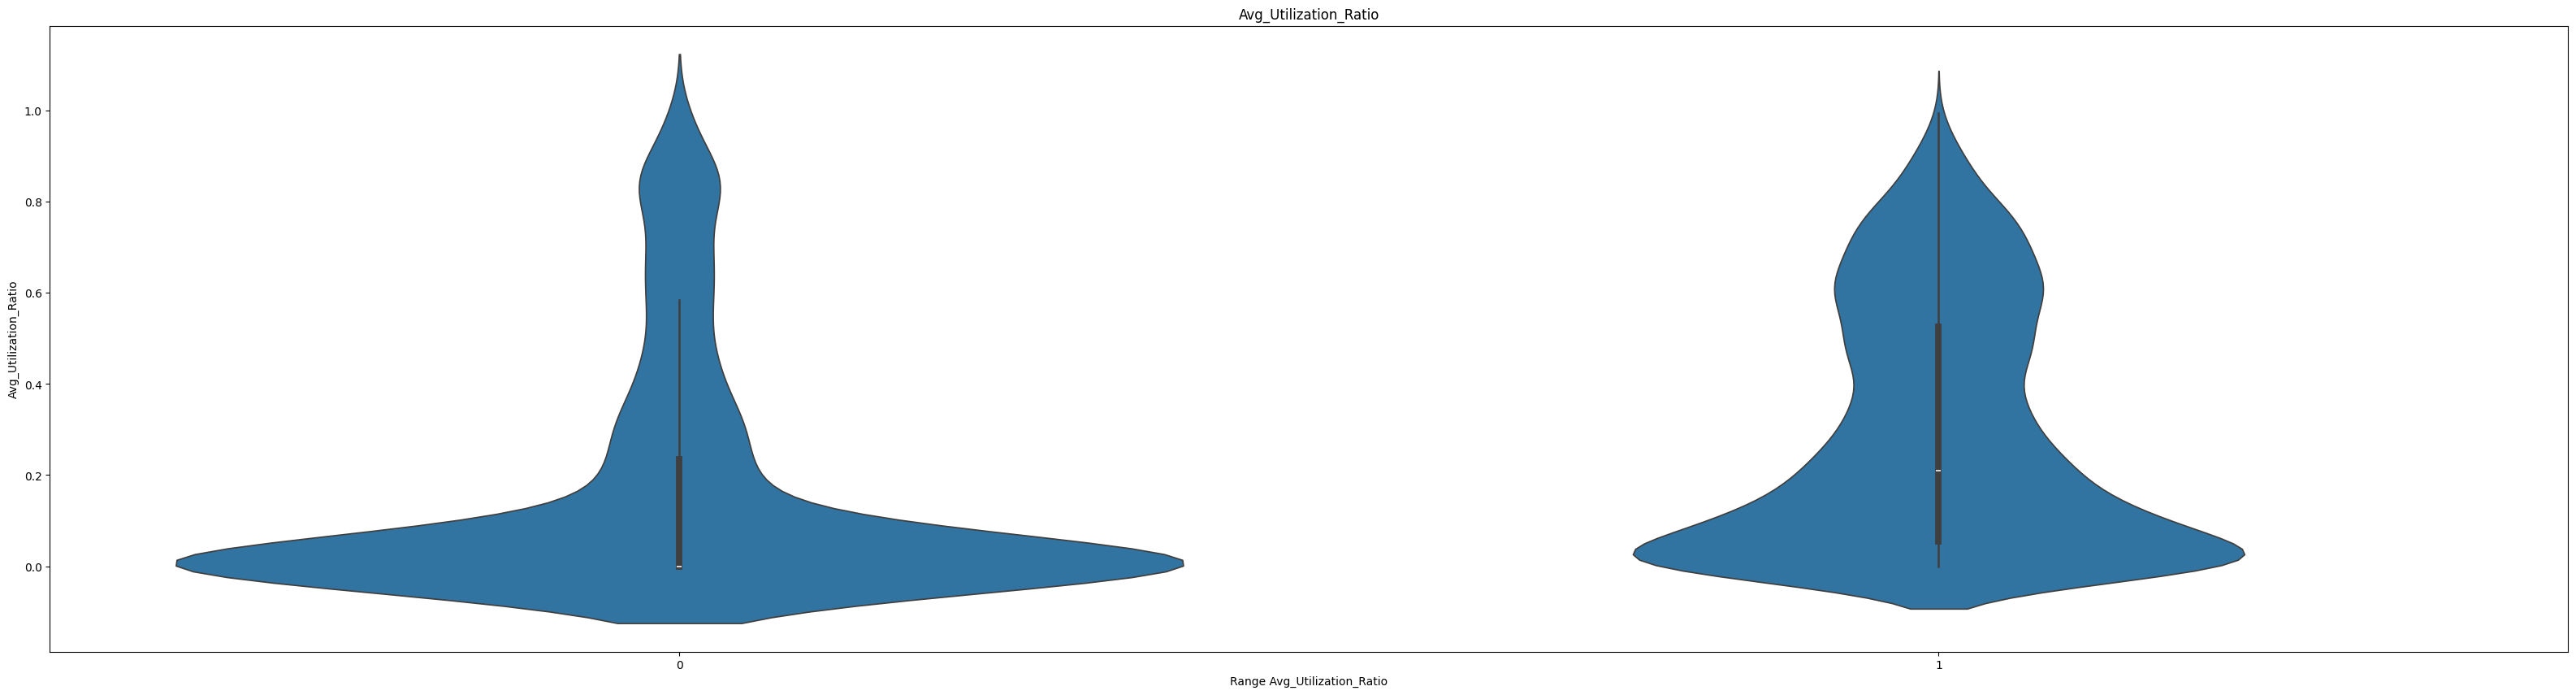

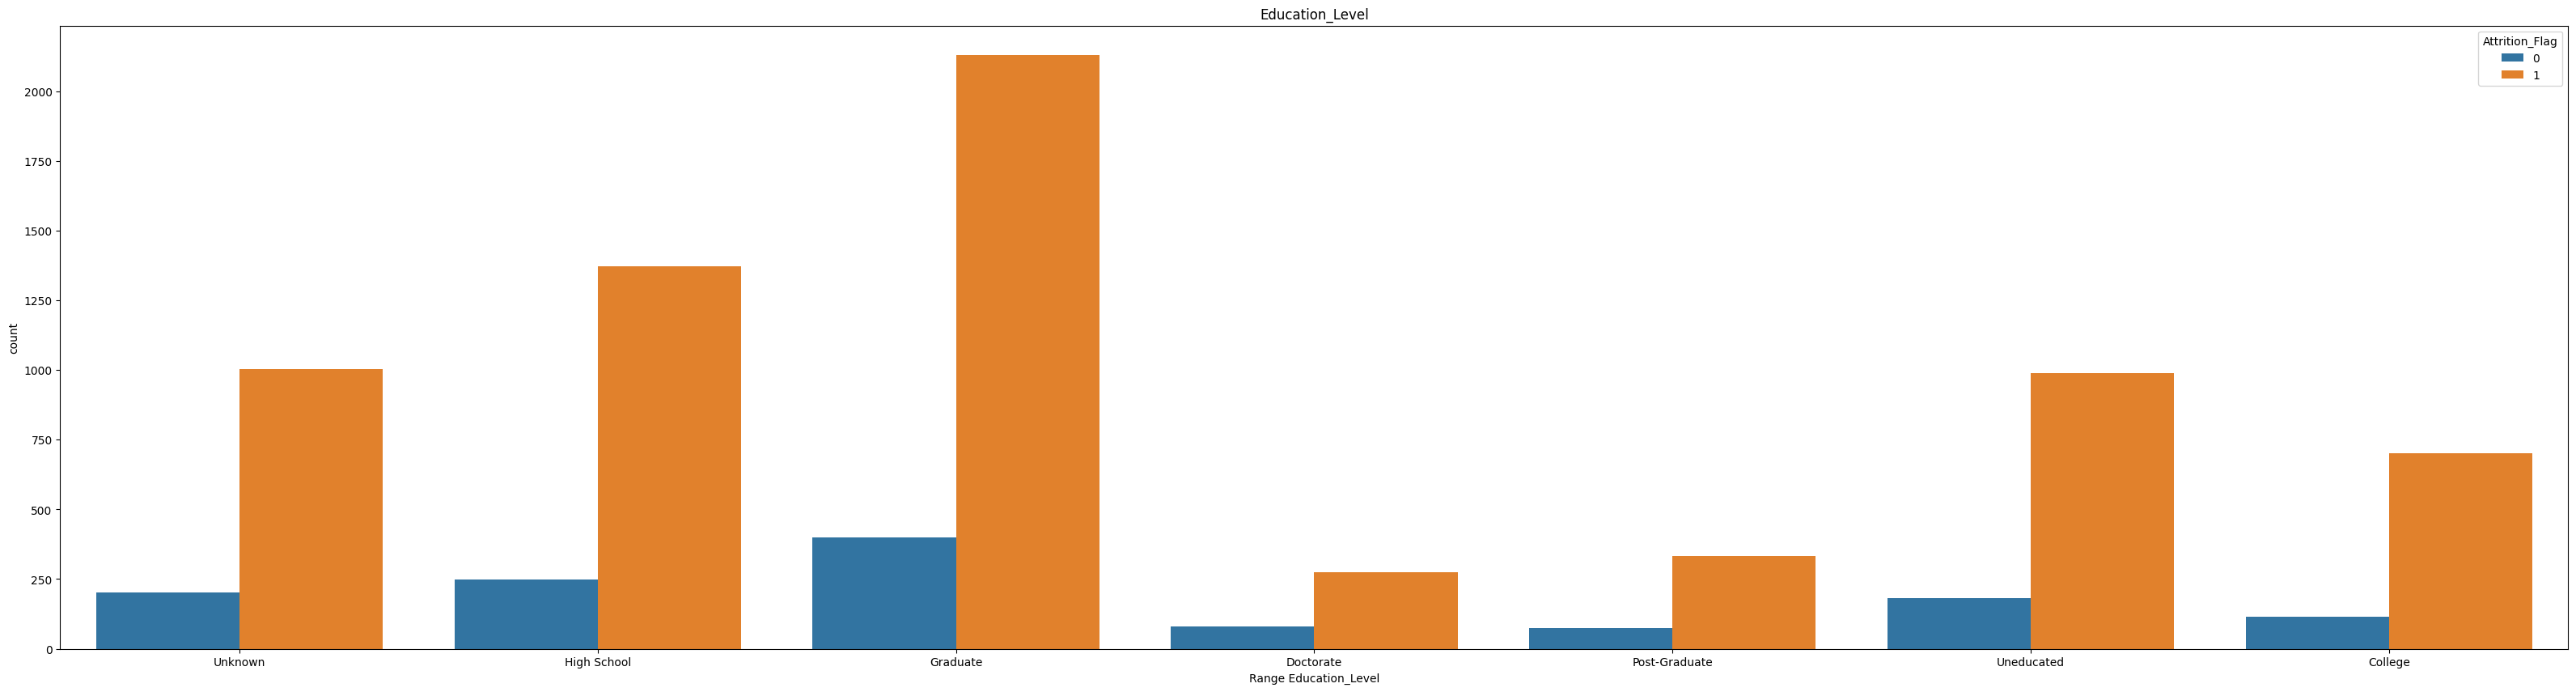

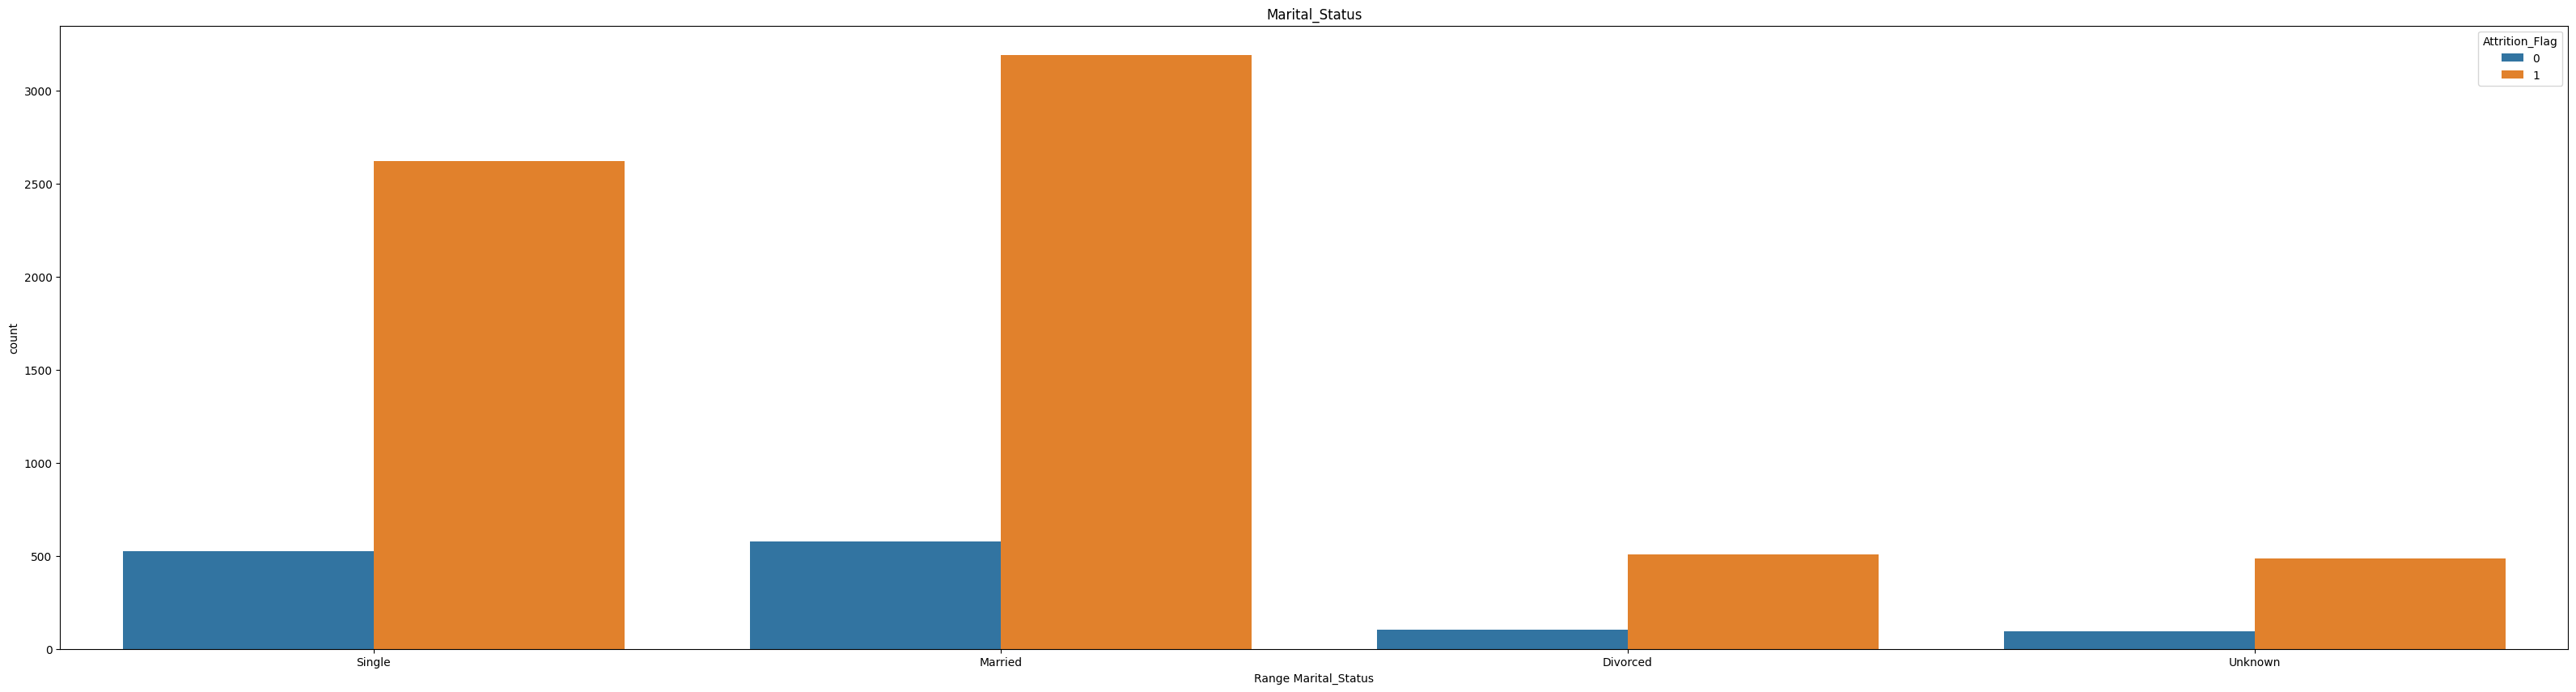

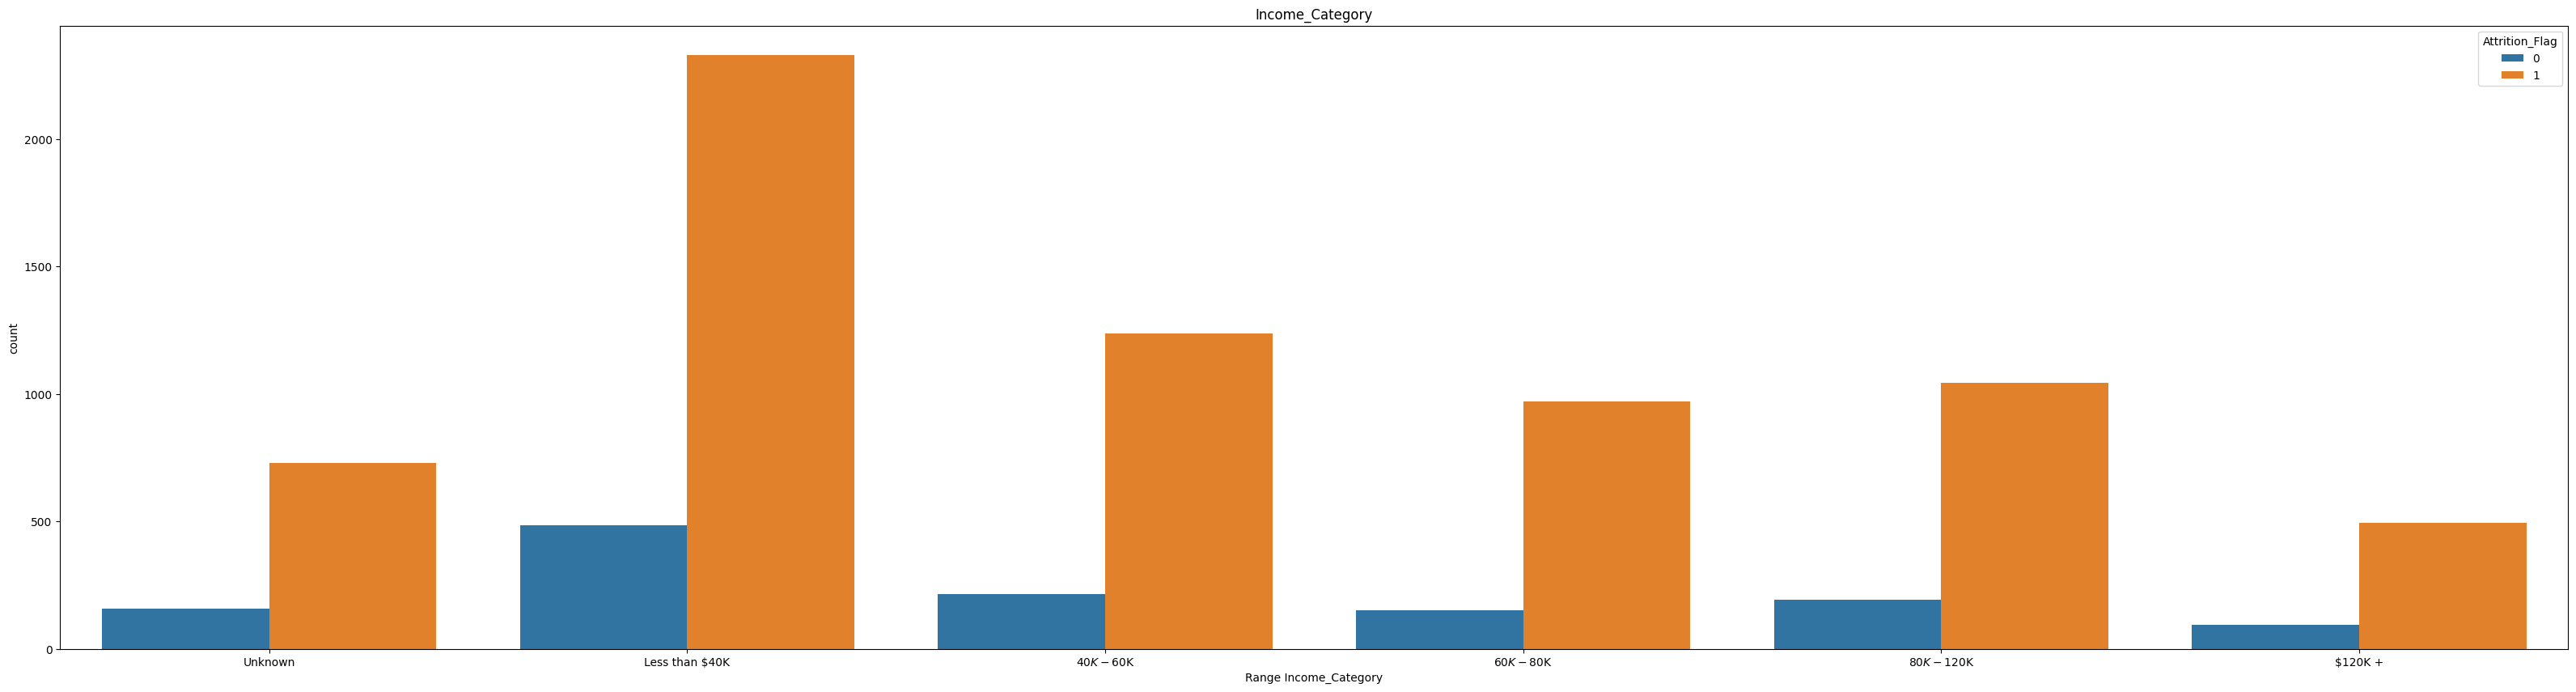

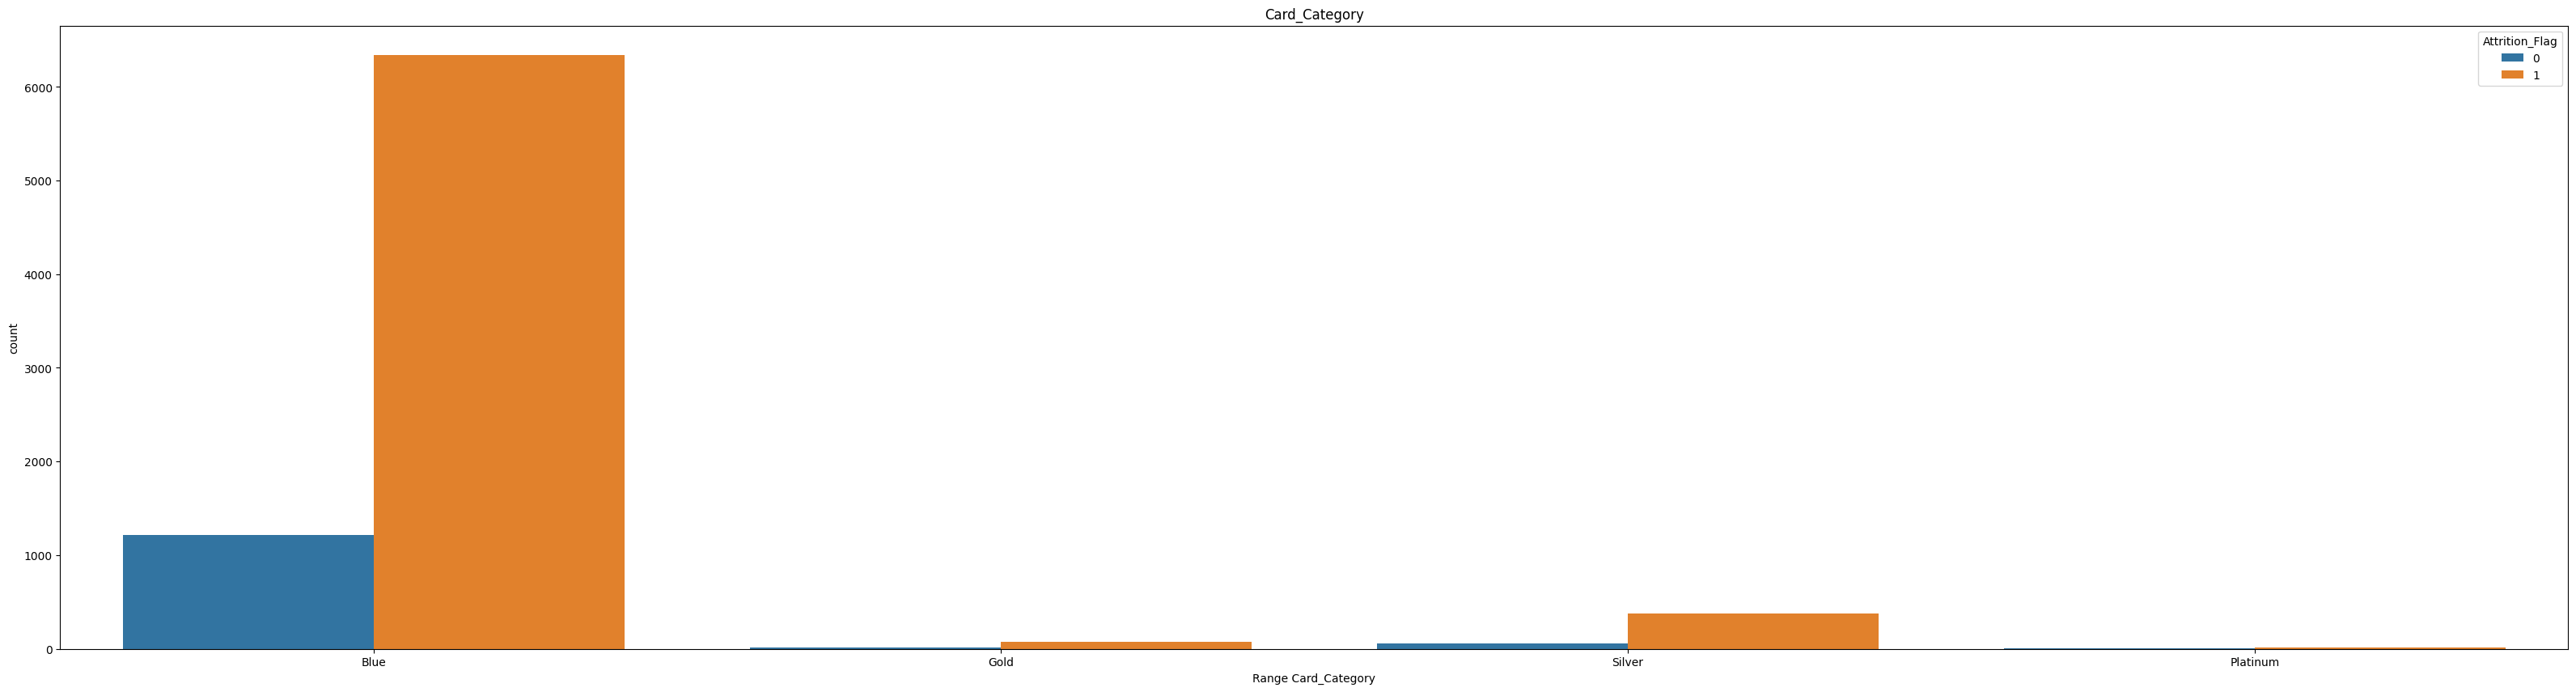

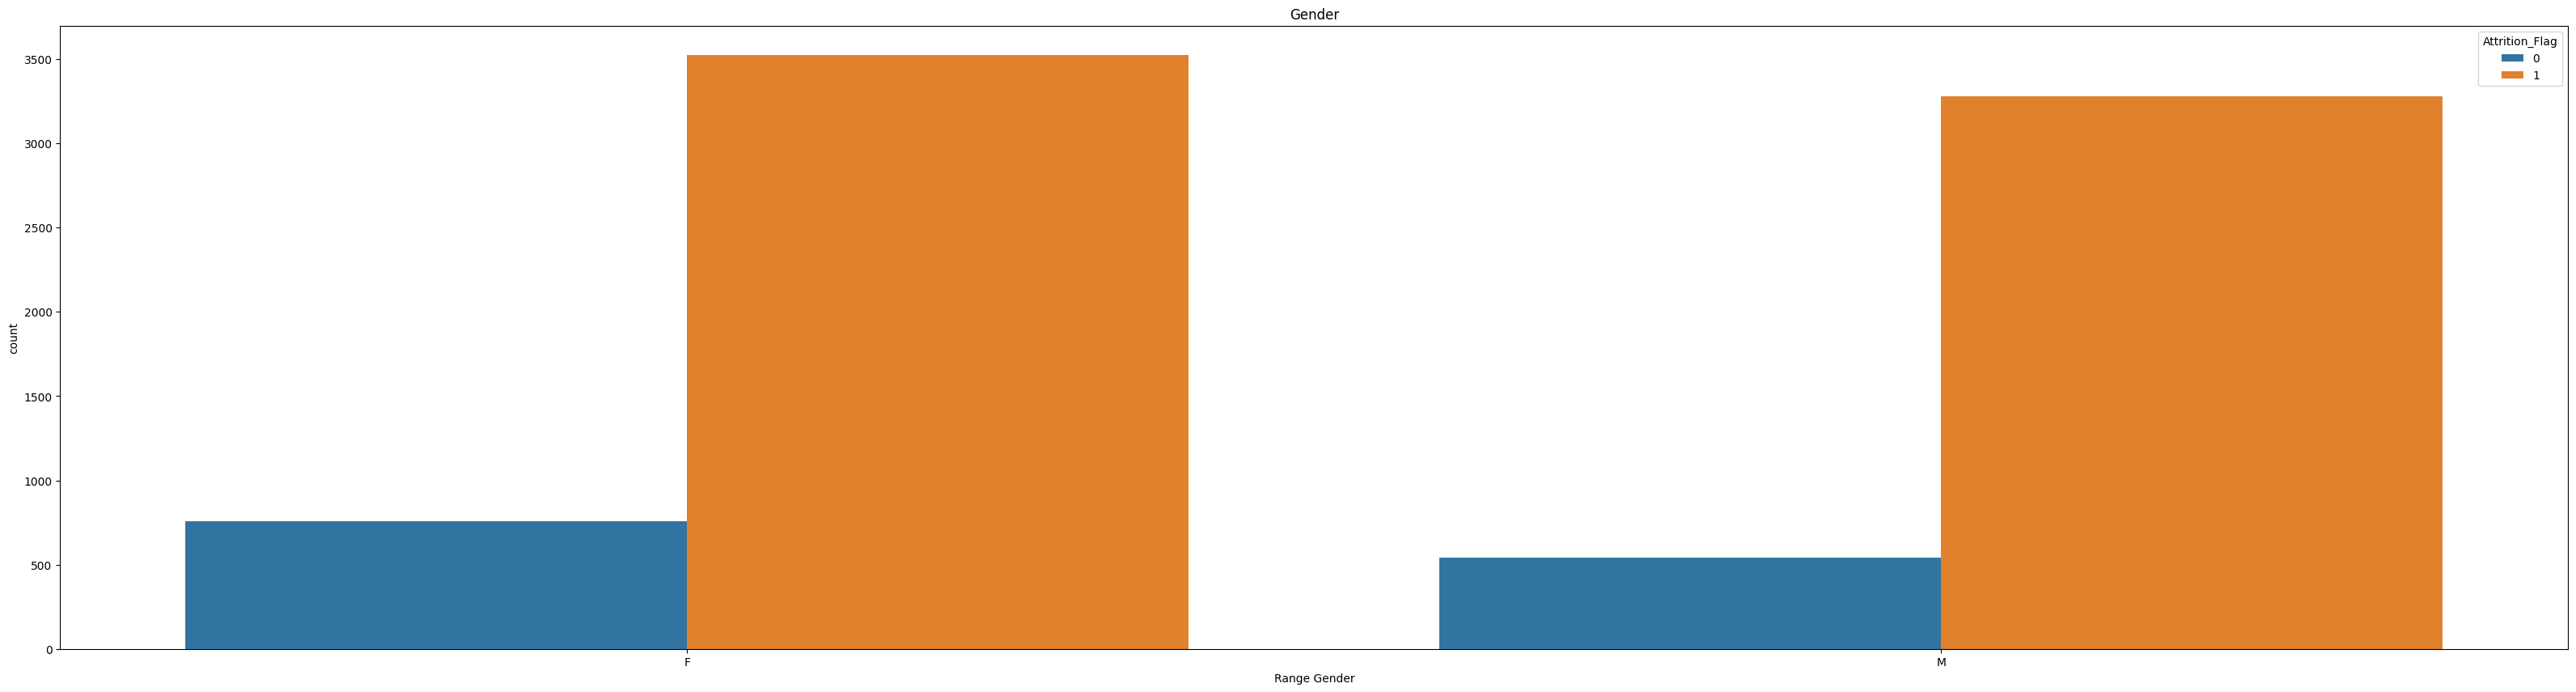

In [27]:
class TargetVariables:

    def __init__(self, df_train, num, cat, binary, target):
        self.df_train=df_train 
        self.num=num 
        self.cat = cat 
        self.binary=binary 
        self.target=target 

    def generate_plots(self):
        
        for i in self.num:
            plt.figure(figsize=(40, 10))
            sns.violinplot(x=self.target, y=i, data=self.df_train)
            plt.title(i)
            plt.xlabel('Range ' + i)
            plt.show()

        for i in self.cat:
            plt.figure(figsize=(40, 10))
            sns.countplot(x=i, hue=self.target, data=self.df_train)
            plt.title(i)
            plt.xlabel('Range ' + i)
            plt.show()

        for i in self.binary:
            plt.figure(figsize=(40, 10))
            sns.countplot(x=i, hue=self.target, data=self.df_train)
            plt.title(i)
            plt.xlabel('Range ' + i)
            plt.show() 

TargetVariables(df_train, num, cat, binary, target).generate_plots()

Income Category: People who quit typically earn less than 40k.
Total Revolving Balance: People who quit typically have a balance close to 0.
Total Transactions: People who quit typically have made few transactions.
Average Utilization Ratio: People who quit don't use the service much.

## PIPELINE

Automate most of the code

In [28]:
df_train['Education_Level'].value_counts()

Education_Level
Graduate         2528
High School      1619
Unknown          1205
Uneducated       1171
College           816
Post-Graduate     407
Doctorate         355
Name: count, dtype: int64

In [29]:
class UnknownTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy()
        for col, unknown_col in self.columns.items():
            unknown = df[col] == 'Unknown'
            df[unknown_col] = unknown.astype(int)
        return df

In [30]:
class CategoricalToNumeric(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy()
        df['Education_Level'] = df['Education_Level'].replace({
            'Uneducated': 0,
            'College': 1,
            'High School': 2,
            'Graduate': 3,
            'Post-Graduate': 4,
            'Doctorate': 5,
            'Unknown': -1,
        })

        df['Income_Category'] = df['Income_Category'].replace({
            'Less than $40K': 0,
            '$40K - $60K': 1,
            '$60K - $80K': 2,
            '$80K - $120K': 3,
            '$120K +': 4,
            'Unknown': -1,
        })

        df['Card_Category'] = df['Card_Category'].replace({
            'Blue': 0,
            'Silver': 1,
            'Gold': 2,
            'Platinum': 3,
        })

        return df


        

In [31]:
class DataFrameProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, index_column):
        self.index_column = index_column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_train = X.drop(['CLIENTNUM'], axis=1)
        X_train.set_index([self.index_column], inplace=True)
        return X_train

In [32]:
class ArrayToDataFrameTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column_names=None):
        self.column_names = column_names

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.column_names is None:
            # Generate default column names
            self.column_names = ['col{}'.format(i) for i in range(X.shape[1])]
        # Convert array to DataFrame
        df = pd.DataFrame(X, columns=self.column_names)
        return df


In [33]:
class MultiColumnLabelEncoder:
    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        output = X.copy()
        le = LabelEncoder()
        for col in self.columns:
            output[col] = le.fit_transform(output[col])
        return output

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [34]:
pipe_train = Pipeline(steps=[
    ('UnknownTransformer', UnknownTransformer({'Education_Level': 'Education_Level_Unknown',
                        'Income_Category': 'Income_Category_Unknown'})),
    ('CategoricalToNumeric', CategoricalToNumeric()),
    ('DataFrameProcessor', DataFrameProcessor('train_idx')),
    ('Encoder', MultiColumnLabelEncoder(columns=['Gender', 'Marital_Status'])),

])

In [35]:
pipe_test = Pipeline(steps=[
    ('UnknownTransformer', UnknownTransformer({'Education_Level': 'Education_Level_Unknown', 'Income_Category': 'Income_Category_Unknown'})),
    ('CategoricalToNumeric', CategoricalToNumeric()),
    ('DataFrameProcessor',DataFrameProcessor('test_idx')),
    ('Encoder', MultiColumnLabelEncoder(columns=['Gender', 'Marital_Status'])),
])

In [36]:
pipe_train = pipe_train.fit_transform(df_train)
pipe_train

C:\Users\Carlos\AppData\Local\Temp\ipykernel_4276\3805185464.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Education_Level'] = df['Education_Level'].replace({
C:\Users\Carlos\AppData\Local\Temp\ipykernel_4276\3805185464.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Income_Category'] = df['Income_Category'].replace({
C:\Users\Carlos\AppData\Local\Temp\ipykernel_4276\3805185464.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavi

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag,Education_Level_Unknown,Income_Category_Unknown
train_idx,,,,,,,,,,,,,,,,,,,,,
0,54,0,1,-1,2,-1,0,36,1,3,...,1728,1995.0,0.595,8554,99,0.678,0.464,1,1,1
1,58,0,4,2,1,-1,0,48,1,4,...,1803,3593.0,0.493,2107,39,0.393,0.334,0,0,1
2,45,0,4,-1,2,0,2,36,6,1,...,1648,14339.0,0.732,1436,36,1.250,0.103,1,1,0
3,34,0,2,3,2,0,0,36,4,3,...,2517,1108.0,1.158,2616,46,1.300,0.694,1,0,0
4,49,0,2,2,1,1,0,39,5,3,...,1926,794.0,0.602,3806,61,0.794,0.708,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8096,44,0,1,3,2,1,0,38,3,2,...,2517,1625.0,0.809,2104,44,0.833,0.608,0,0,0
8097,53,0,3,2,0,-1,0,36,4,3,...,0,7939.0,0.551,2269,42,0.312,0.000,0,0,1
8098,42,0,4,3,3,0,0,32,3,1,...,1547,767.0,0.804,4678,74,1.000,0.669,1,0,0


In [37]:
pipe_test = pipe_test.fit_transform(df_test)
pipe_test

C:\Users\Carlos\AppData\Local\Temp\ipykernel_4276\3805185464.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Education_Level'] = df['Education_Level'].replace({
C:\Users\Carlos\AppData\Local\Temp\ipykernel_4276\3805185464.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Income_Category'] = df['Income_Category'].replace({
C:\Users\Carlos\AppData\Local\Temp\ipykernel_4276\3805185464.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavi

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Unknown,Income_Category_Unknown
test_idx,,,,,,,,,,,,,,,,,,,,,
0,48,0,3,0,2,0,0,39,4,3,...,2991.0,1508,1483.0,0.703,3734,64,0.882,0.504,0,0
1,59,1,1,0,2,0,0,53,5,5,...,2192.0,1569,623.0,0.706,4010,79,0.717,0.716,0,0
2,37,0,2,3,0,0,0,36,4,3,...,1734.0,987,747.0,0.879,4727,67,0.914,0.569,0,0
3,47,1,3,5,0,1,0,36,4,2,...,4786.0,1516,3270.0,0.940,4973,74,0.850,0.317,0,0
4,42,1,3,-1,2,3,0,33,3,3,...,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,34,1,2,3,2,3,0,29,3,1,...,13395.0,1678,11717.0,1.006,2650,69,0.865,0.125,0,0
2022,35,0,1,1,2,0,0,25,2,2,...,2231.0,1791,440.0,0.820,2576,42,0.750,0.803,0,0
2023,44,0,1,0,0,0,0,37,1,2,...,5594.0,1235,4359.0,0.549,5220,75,0.829,0.221,0,0


Split 

In [38]:
# X_train,X_test,y_train,y_test

In [39]:
X_train=pipe_train.drop(target, axis=1)
y_train=pipe_train[target]
X_test=pipe_test
# y_test=?
# y_pred

In [40]:
X_train.sample(5)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Unknown,Income_Category_Unknown
train_idx,,,,,,,,,,,,,,,,,,,,,
7730,48,0,2,2,2,0,0,35,4,6,...,1686.0,1271,415.0,1.087,3445,64,0.730,0.754,0,0
5157,40,1,3,1,0,2,0,34,3,3,...,19666.0,1180,18486.0,0.898,3391,54,0.636,0.060,0,0
2964,47,1,3,1,1,4,1,27,6,3,...,34516.0,2315,32201.0,0.599,1805,46,0.704,0.067,0,0
8037,49,0,3,3,1,0,0,35,3,3,...,2919.0,2032,887.0,0.654,4937,75,0.667,0.696,0,0
6341,36,0,0,-1,1,0,1,19,1,2,...,13313.0,0,13313.0,1.080,15549,121,0.833,0.000,1,0


In [41]:
y_train.sample(5)

train_idx
7773    1
1057    1
2526    1
7133    0
2308    1
Name: Attrition_Flag, dtype: int64

In [42]:
X_test.sample(5)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_Unknown,Income_Category_Unknown
test_idx,,,,,,,,,,,,,,,,,,,,,
760,48,1,4,3,1,3,1,40,6,2,...,34516.0,807,33709.0,0.967,3937,80,1.051,0.023,0,0
1006,49,0,2,0,2,0,0,37,5,1,...,2934.0,2381,553.0,0.762,3396,64,0.778,0.812,0,0
1376,43,1,3,2,3,2,0,36,5,3,...,20811.0,1425,19386.0,0.382,1483,38,0.520,0.068,0,0
267,41,1,5,1,1,2,0,31,1,3,...,5002.0,1945,3057.0,1.035,16161,109,0.787,0.389,0,0
444,28,1,0,2,1,-1,0,21,5,3,...,25618.0,1209,24409.0,1.228,2157,49,1.882,0.047,0,1


- Normalize data
- Rebalance

## MODELS


In [43]:
def f1(model,X,y):
    model.fit(X,y)
    return f1_score(y,model.predict(X))
def f1_cross_validation(model, X, y):
    cross_val = cross_val_score(model, X, y, cv=4, scoring='f1')
    return cross_val.mean()
label_, f1_train_ , f1_valida_ = [], [], []

In [44]:
def evaluate_classification(label, model, X, y):
    f1_train = f1(model,X,y)
    f1_valida = f1_cross_validation(model,X,y)
    label_.append(label)
    f1_train_.append(f1_train)
    f1_valida_.append(f1_valida)
    return pd.DataFrame({'Model': label_,
                      'F1 Score Train': f1_train_,
                      'F1 Score Cross-Valida': f1_valida_
                      }).sort_values('F1 Score Cross-Valida',ascending=False)

In [45]:
df_train.Attrition_Flag.value_counts()

Attrition_Flag
1    6801
0    1300
Name: count, dtype: int64

In [46]:
evaluate_classification(label='LogisticRegression',
                        model=LogisticRegression(),
                        X=X_train, y=y_train)

evaluate_classification(label='SVC',
                        model=SVC(),
                        X=X_train, y=y_train)

evaluate_classification(label='SVC_Rebalanced',
                        model=SVC(class_weight='balanced'),
                        X=X_train, y=y_train)

evaluate_classification(label='GradientBoosting',
                        model=GradientBoostingClassifier(),
                        X=X_train, y=y_train)

evaluate_classification(label='XGBoost',
                        model=XGBClassifier(),
                        X=X_train, y=y_train)

evaluate_classification(label='RandomForestClassifier',
                        model=RandomForestClassifier(),
                        X=X_train, y=y_train)

d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:

,Model,F1 Score Train,F1 Score Cross-Valida
4,XGBoost,1.000000,0.983016
3,GradientBoosting,0.986197,0.980767
5,RandomForestClassifier,1.000000,0.976655
0,LogisticRegression,0.928303,0.933394
1,SVC,0.912763,0.912763
2,SVC_Rebalanced,0.818265,0.815814


I've created different models testing various algorithms to assess each model's performance.
Researching unbalanced data projects, I found that SCV, GradientBoosting, and RandomForest typically offer regularization and take the specific case study into account.

In this case, I'm choosing between three algorithms (SVC, XGB, and GB), based on performance, explainability, and performance for unbalanced cases.

I've selected GradientBoosting because it's less complex to explain than XGBoost and offers very similar performance. Furthermore, XGBoost has a reputation for overfitting new data. SVC, on the other hand, is known for handling unbalanced cases very well, but its performance limitations led me to exclude it from the final selection.

### PREDICTION and EXPLICABILITY

In [47]:
GB=GradientBoostingClassifier()
Model_GradientBoostingClassifier=GB.fit(X_train, y_train)

In [48]:
# y_train_pred=
y_test_pred=Model_GradientBoostingClassifier.predict(X_test)
pd.Series(y_test_pred).value_counts()

1    1733
0     293
Name: count, dtype: int64

In [49]:
y_train_pred_proba = Model_GradientBoostingClassifier.predict_proba(X_train)[:, 1]
y_test_pred_proba = Model_GradientBoostingClassifier.predict_proba(X_test)[:, 1]
print(y_train_pred_proba)
print(y_test_pred_proba)

[0.9854696  0.02363847 0.99399531 ... 0.99653776 0.99047229 0.99581721]
[0.99036956 0.99384861 0.99140461 ... 0.99414643 0.74553172 0.98531681]


In [50]:
def feature_importance(model, X_train):

    f_importances = model.feature_importances_
    top_features = pd.DataFrame({'feature': X_train.columns, 'importance': f_importances})
    top_features = top_features.sort_values('importance', ascending=False).reset_index(drop=True)
    top_features = top_features.head(10)

    plt.figure(figsize=[15,15])
    sns.barplot(data=top_features, y='feature', x='importance', color='skyblue')
    plt.title('Importancia de características')
    plt.show()

    return top_features

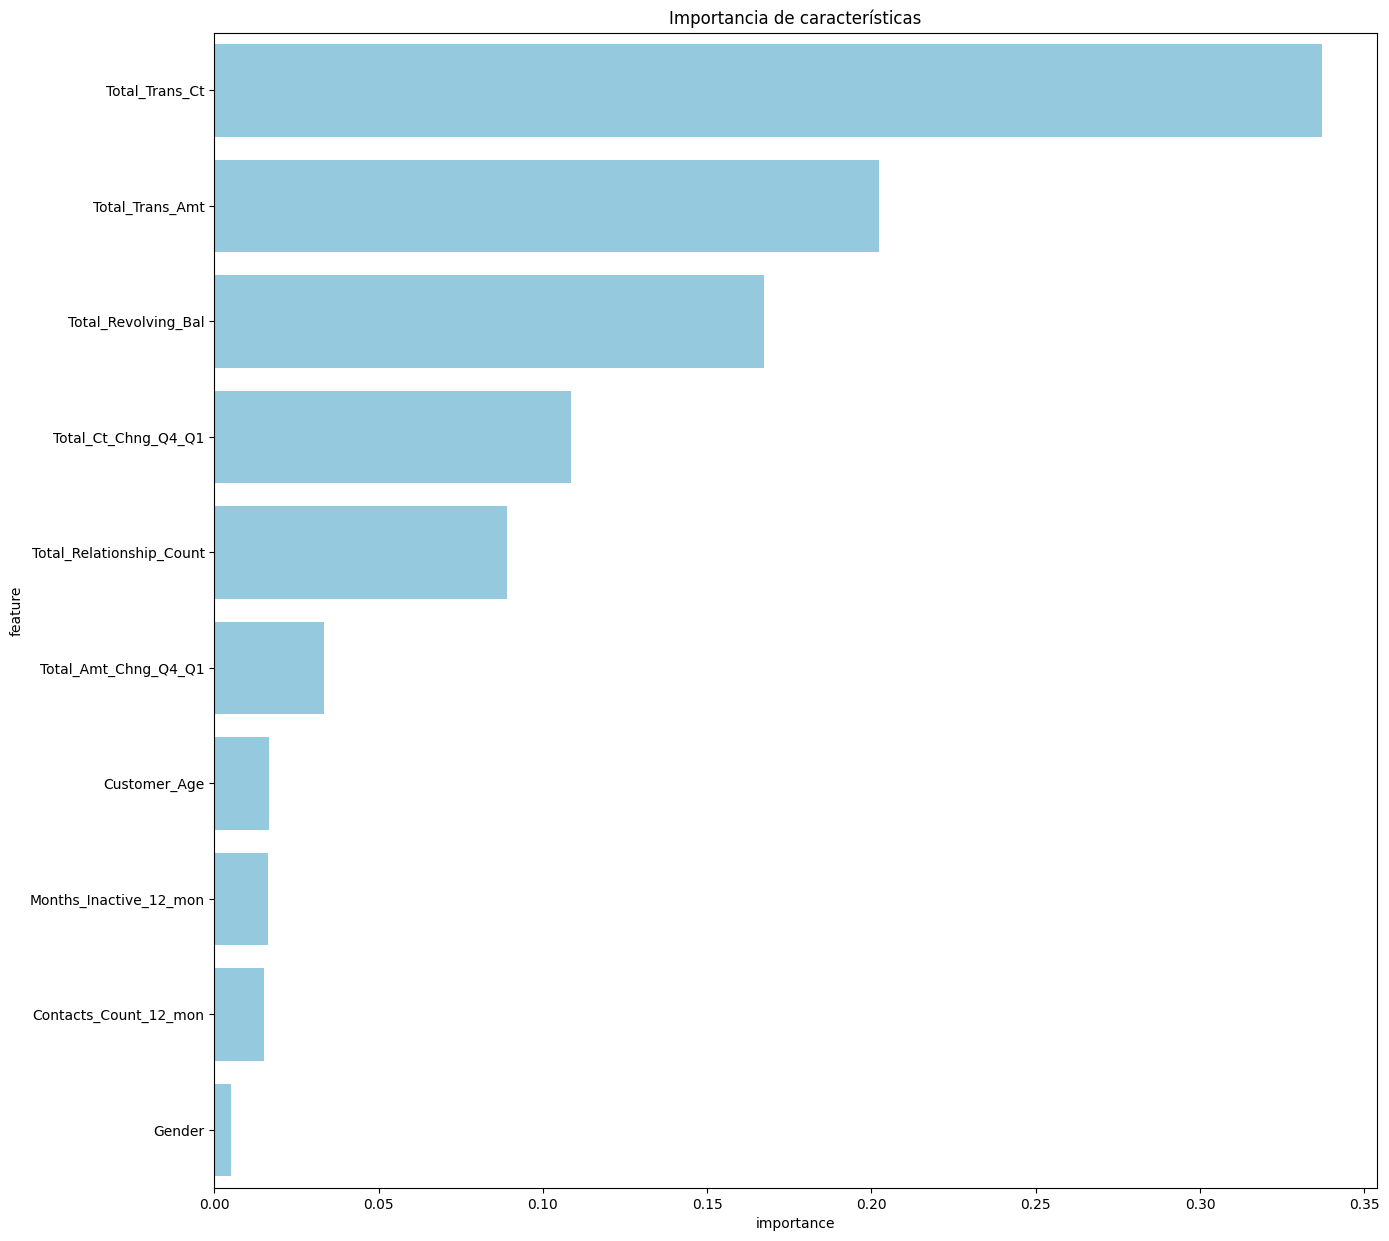

,feature,importance
0,Total_Trans_Ct,0.337011
1,Total_Trans_Amt,0.202343
2,Total_Revolving_Bal,0.167294
3,Total_Ct_Chng_Q4_Q1,0.108484
4,Total_Relationship_Count,0.088922
5,Total_Amt_Chng_Q4_Q1,0.033472
6,Customer_Age,0.016503
7,Months_Inactive_12_mon,0.016366
8,Contacts_Count_12_mon,0.015187
9,Gender,0.005031


In [51]:
feature_importance(Model_GradientBoostingClassifier, X_train)

Data rebalancing with SMOTE, ADASYN, RandomUnderSampler, SMOTEEN, and SMOTETomek.
I increased the data, a technique normally prohibited, by making copies of samples from the target's Class 0 data.
I used a BalancedBagging ensemble.
NearMiss.
Experiments with generating variables such as: Average_Transaction_Amount, Transaction_Frequency, Average_Transaction_Balance, Percentage_Change_to_Transaction_Amount, Transaction_Frequency, and Average_Transaction_Duration.

I attempted to remove noise from Class 0 data by eliminating more data. The goal was to remove the differences in the values ​​of the numerical variables from the multivariate analysis so that the model would focus on predicting 0 if a series of events occurred without hesitation. The cleaned variables were: Total_Revolving_Bal, Total_Trans_Amt, Total_Trans_Ct, and Total_Ct_Chng_Q4_Q1.
I tried to model using the important variables, but the maximum performance was 0.90.
I tried creating two clusters of customers, and the model performed slightly worse, from 0.932 to 0.939.

### F1
The F1-score metric is useful when we have a class imbalance, that is, when one class appears much more frequently than another. In these cases, Accuracy can give a false sense of good performance.

In [53]:
from utils import data_report, EDA

In [54]:
data_report(df_train)

Información general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8101 entries, 0 to 8100
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   train_idx                 8101 non-null   int64  
 1   CLIENTNUM                 8101 non-null   int64  
 2   Customer_Age              8101 non-null   int64  
 3   Gender                    8101 non-null   object 
 4   Dependent_count           8101 non-null   int64  
 5   Education_Level           8101 non-null   object 
 6   Marital_Status            8101 non-null   object 
 7   Income_Category           8101 non-null   object 
 8   Card_Category             8101 non-null   object 
 9   Months_on_book            8101 non-null   int64  
 10  Total_Relationship_Count  8101 non-null   int64  
 11  Months_Inactive_12_mon    8101 non-null   int64  
 12  Contacts_Count_12_mon     8101 non-null   int64  
 13  Credit_Limit              8101 non-null  